# In Silico `Toxicity` prediction for `BacillusAnthracis` Antibiotic Candidates

This notebook implements a statistically grounded, **FDA-approved-antibiotic-reference-driven** workflow for ranking generated antibiotic candidates using:

- **pPotency (pIC50)** (higher is better)
- **Toxicity burden** (lower is better)
- **ADME feasibility** (higher is better)

The design follows three core ideas from the literature:

1. **QED-style desirability scoring**  
   Heterogeneous properties should first be mapped to a common 0–1 desirability scale and then combined continuously rather than by rigid pass/fail rules.

2. **ADMET-score-style weighted aggregation**  
   ADMET endpoints should not all contribute equally. More informative and clinically important endpoints should get stronger weight.

3. **ADMET-AI reference-based interpretation**  
   ADMET properties are most meaningful when interpreted relative to an appropriate approved-drug reference set.  
   For this project, the most relevant reference set is **FDA-approved antibiotics**.

The goal is to support **early prioritization**, not to make definitive toxicity claims.

## What this notebook does

1. Harmonizes the reference and candidate dataframes
2. Keeps only metadata, potency, toxicity, ADME, and useful physicochemical columns
3. Splits `ADMET-AI` outputs into **Toxicity** and **ADME**
4. Derives **antibiotic-reference-driven statistical weights**
5. Converts each endpoint into a **desirability score**
6. Builds:
   - `ToxicitySafety`
   - `Toxicity Score = 1 - ToxicitySafety`
   - `ADMEFeasibility`
7. Generates:
   - 2D plot: pPotency vs Toxicity burden
   - 3D plot: pPotency vs Toxicity burden vs ADME feasibility
   - Save top-20 candidates to CSV files

In [93]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

import math
import numpy as np
import pandas as pd
import pubchempy as pcp
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem
from admet_ai import ADMETModel
from admet_ai.drugbank import get_drugbank
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib.patches as patches
from matplotlib.patches import ConnectionPatch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.lines as mlines, math
from scipy.stats import percentileofscore

## Define data directory for model trained on `ChEMBL + PubChem` bioassay dataset

In [94]:
target_organism = "BacillusAnthracis"

In [95]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
saveDir = os.path.join(dataDir, f"Results/{target_organism}_bestMACAW_allDB/")
os.makedirs(saveDir, exist_ok=True)

### Read `ADMET` endpoints with `pPotency`of the FDA approved Drug data from `Drugbank`

In [96]:
drugBankDrug_FDAapproved_antibiotic_wART_wADMET = pd.read_csv(saveDir + f'{target_organism}_Drugbnk_FDAapproved_Antibiotic_ARTprediction.csv')
drugBankDrug_FDAapproved_antibiotic_wART_wADMET = drugBankDrug_FDAapproved_antibiotic_wART_wADMET.rename(columns={'smiles': 'SMILES'})
# Identify columns that match the string
matched_cols = drugBankDrug_FDAapproved_antibiotic_wART_wADMET.filter(like='drugbank_approved_percentile').columns
# Keep everything EXCEPT those columns
drugBankDrug_FDAapproved_antibiotic_wART_wADMET = drugBankDrug_FDAapproved_antibiotic_wART_wADMET.drop(columns=matched_cols)
max_val = drugBankDrug_FDAapproved_antibiotic_wART_wADMET['pPotency_prediction'].max()
min_val = drugBankDrug_FDAapproved_antibiotic_wART_wADMET['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
drugBankDrug_FDAapproved_antibiotic_wART_wADMET

pPotency_prediction range: 1.343 → 5.897


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,Unnamed: 0,ATC_code,...,Clearance_Hepatocyte_AZ,Clearance_Microsome_AZ,Half_Life_Obach,HydrationFreeEnergy_FreeSolv,LD50_Zhu,Lipophilicity_AstraZeneca,PPBR_AZ,Solubility_AqSolDB,VDss_Lombardo,source_DataBase
0,NCC[C@H](O)C(=O)N[C@@H]1C[C@H](N)[C@@H](O[C@H]...,3.525954,1.119518,1.331698,5.720210,0.000298,1.904541e-06,0.046591,0,J01GB;J01RA,...,36.152091,2.245671,7.526745,-20.117337,1.595968,-1.807717,23.987537,-0.102104,-6.522413,FDA_Antibiotics
1,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccc(O)cc3)...,4.987345,1.120375,2.791410,7.183280,0.000010,6.557220e-08,0.001617,1,J01CA;J01CR,...,8.870990,8.964288,-0.649105,-13.895778,1.984036,-0.922387,59.371961,-1.955969,0.402972,FDA_Antibiotics
2,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](NC(=O)N3CCNC3=...,3.442877,1.119518,1.248620,5.637133,0.000361,2.306042e-06,0.056413,4,J01CA;J01CR,...,3.494191,44.284968,1.065897,-13.175952,2.165658,-0.854850,78.940997,-2.968939,2.201075,FDA_Antibiotics
3,C[C@H]1[C@H](NC(=O)/C(=N\OC(C)(C)C(=O)O)c2csc(...,3.786489,1.118681,1.593873,5.979105,0.000163,1.049289e-06,0.025476,5,J01DF,...,-10.878718,0.653251,-1.372036,-15.327836,2.373001,-3.370004,59.166133,-1.183660,5.657260,FDA_Antibiotics
4,CCOC(=O)OC(C)OC(=O)[C@@H]1N2C(=O)[C@@H](NC(=O)...,3.794162,1.118931,1.601058,5.987267,0.000161,1.029753e-06,0.025058,6,J01CA;J01CR,...,100.958985,117.151278,-23.185533,-9.495806,2.714478,2.047164,75.654842,-2.922240,5.521395,FDA_Antibiotics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,4.309461,1.118857,2.116502,6.502420,0.000049,3.144704e-07,0.007647,146,J01AA,...,9.591706,60.994419,11.583123,-12.590552,2.663011,-0.090869,55.730797,-2.513165,5.962830,FDA_Antibiotics
128,CCS(=O)(=O)CCn1c([N+](=O)[O-])cnc1C,4.424298,1.118918,2.231218,6.617377,0.000038,2.413365e-07,0.005872,147,J01RA;J01XD,...,-0.296836,13.442499,-5.683420,-10.941420,1.811951,-0.624001,46.324032,-1.894738,3.686183,FDA_Antibiotics
129,CO[C@H]1C[C@H](O[C@H]2[C@H](C)[C@@H](O[C@@H]3O...,2.276538,1.125678,0.070209,4.482867,0.005290,3.289523e-05,0.850729,150,J01FA,...,107.706804,61.057693,27.990995,-7.253569,2.947751,2.111868,75.170419,-4.023729,8.703718,FDA_Antibiotics
130,N[C@@H]1[C@H]2CN(c3nc4c(cc3F)c(=O)c(C(=O)O)cn4...,3.073553,1.126205,0.866192,5.280915,0.000844,5.237026e-06,0.136084,151,J01MA,...,8.977690,-22.250148,6.670442,-11.224623,2.764096,-0.132504,59.160649,-4.611402,-2.076524,FDA_Antibiotics


### Convert `SMILES` to `Canonical SMILES` for comparison

In [97]:
def canonicalizeSmiles(smilesValue):
    if pd.isna(smilesValue):
        return None

    smilesStr = str(smilesValue).strip()
    if smilesStr == "":
        return None

    mol = Chem.MolFromSmiles(smilesStr)
    if mol is None:
        return None

    return Chem.MolToSmiles(mol, canonical=True)

drugBankDrug_FDAapproved_antibiotic_wART_wADMET = drugBankDrug_FDAapproved_antibiotic_wART_wADMET.copy()
drugBankDrug_FDAapproved_antibiotic_wART_wADMET["SMILES"] = (
    drugBankDrug_FDAapproved_antibiotic_wART_wADMET["SMILES"].apply(canonicalizeSmiles)
)

drugBankDrug_FDAapproved_antibiotic_wART_wADMET

,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,Unnamed: 0,ATC_code,...,Clearance_Hepatocyte_AZ,Clearance_Microsome_AZ,Half_Life_Obach,HydrationFreeEnergy_FreeSolv,LD50_Zhu,Lipophilicity_AstraZeneca,PPBR_AZ,Solubility_AqSolDB,VDss_Lombardo,source_DataBase
0,NCC[C@H](O)C(=O)N[C@@H]1C[C@H](N)[C@@H](O[C@H]...,3.525954,1.119518,1.331698,5.720210,0.000298,1.904541e-06,0.046591,0,J01GB;J01RA,...,36.152091,2.245671,7.526745,-20.117337,1.595968,-1.807717,23.987537,-0.102104,-6.522413,FDA_Antibiotics
1,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccc(O)cc3)...,4.987345,1.120375,2.791410,7.183280,0.000010,6.557220e-08,0.001617,1,J01CA;J01CR,...,8.870990,8.964288,-0.649105,-13.895778,1.984036,-0.922387,59.371961,-1.955969,0.402972,FDA_Antibiotics
2,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](NC(=O)N3CCNC3=...,3.442877,1.119518,1.248620,5.637133,0.000361,2.306042e-06,0.056413,4,J01CA;J01CR,...,3.494191,44.284968,1.065897,-13.175952,2.165658,-0.854850,78.940997,-2.968939,2.201075,FDA_Antibiotics
3,C[C@H]1[C@H](NC(=O)/C(=N\OC(C)(C)C(=O)O)c2csc(...,3.786489,1.118681,1.593873,5.979105,0.000163,1.049289e-06,0.025476,5,J01DF,...,-10.878718,0.653251,-1.372036,-15.327836,2.373001,-3.370004,59.166133,-1.183660,5.657260,FDA_Antibiotics
4,CCOC(=O)OC(C)OC(=O)[C@@H]1N2C(=O)[C@@H](NC(=O)...,3.794162,1.118931,1.601058,5.987267,0.000161,1.029753e-06,0.025058,6,J01CA;J01CR,...,100.958985,117.151278,-23.185533,-9.495806,2.714478,2.047164,75.654842,-2.922240,5.521395,FDA_Antibiotics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,4.309461,1.118857,2.116502,6.502420,0.000049,3.144704e-07,0.007647,146,J01AA,...,9.591706,60.994419,11.583123,-12.590552,2.663011,-0.090869,55.730797,-2.513165,5.962830,FDA_Antibiotics
128,CCS(=O)(=O)CCn1c([N+](=O)[O-])cnc1C,4.424298,1.118918,2.231218,6.617377,0.000038,2.413365e-07,0.005872,147,J01RA;J01XD,...,-0.296836,13.442499,-5.683420,-10.941420,1.811951,-0.624001,46.324032,-1.894738,3.686183,FDA_Antibiotics
129,CO[C@H]1C[C@H](O[C@H]2[C@H](C)[C@@H](O[C@@H]3O...,2.276538,1.125678,0.070209,4.482867,0.005290,3.289523e-05,0.850729,150,J01FA,...,107.706804,61.057693,27.990995,-7.253569,2.947751,2.111868,75.170419,-4.023729,8.703718,FDA_Antibiotics
130,N[C@@H]1[C@H]2CN(c3nc4c(cc3F)c(=O)c(C(=O)O)cn4...,3.073553,1.126205,0.866192,5.280915,0.000844,5.237026e-06,0.136084,151,J01MA,...,8.977690,-22.250148,6.670442,-11.224623,2.764096,-0.132504,59.160649,-4.611402,-2.076524,FDA_Antibiotics


### Retain only `toxicity`, `mechanistic`, and `ADME` related endpoints

In [98]:
# Potency-related columns
dataCols = [
    "SMILES",
    "ATC_code", "Drug_Type", "source_DataBase"
]

# Potency-related columns
potencyCols = [
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]

# Mechanistic alert endpoints
# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = dataCols + potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in drugBankDrug_FDAapproved_antibiotic_wART_wADMET.columns
]

drugBankDrug_FDAapproved_antibiotic_wART_wADMET = drugBankDrug_FDAapproved_antibiotic_wART_wADMET[selectedCols].copy()

print("Filtered dataframe shape:", drugBankDrug_FDAapproved_antibiotic_wART_wADMET.shape)
drugBankDrug_FDAapproved_antibiotic_wART_wADMET.head()

Filtered dataframe shape: (132, 44)


,SMILES,ATC_code,Drug_Type,source_DataBase,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,NCC[C@H](O)C(=O)N[C@@H]1C[C@H](N)[C@@H](O[C@H]...,J01GB;J01RA,antibiotic,FDA_Antibiotics,3.525954,1.119518,1.331698,5.720210,0.000298,1.904541e-06,...,0.038441,0.078183,0.000265,0.007574,0.002886,0.001272,0.016743,0.013290,0.264031,0.002039
1,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccc(O)cc3)...,J01CA;J01CR,antibiotic,FDA_Antibiotics,4.987345,1.120375,2.791410,7.183280,0.000010,6.557220e-08,...,0.024073,0.689159,0.001078,0.006863,0.120056,0.001875,0.029528,0.005839,0.341138,0.002913
2,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](NC(=O)N3CCNC3=...,J01CA;J01CR,antibiotic,FDA_Antibiotics,3.442877,1.119518,1.248620,5.637133,0.000361,2.306042e-06,...,0.029585,0.498562,0.000209,0.003408,0.147586,0.001105,0.014598,0.002810,0.168017,0.003372
3,C[C@H]1[C@H](NC(=O)/C(=N\OC(C)(C)C(=O)O)c2csc(...,J01DF,antibiotic,FDA_Antibiotics,3.786489,1.118681,1.593873,5.979105,0.000163,1.049289e-06,...,0.021248,0.170979,0.000327,0.001936,0.099924,0.000396,0.006895,0.003862,0.107208,0.000714
4,CCOC(=O)OC(C)OC(=O)[C@@H]1N2C(=O)[C@@H](NC(=O)...,J01CA;J01CR,antibiotic,FDA_Antibiotics,3.794162,1.118931,1.601058,5.987267,0.000161,1.029753e-06,...,0.580503,0.481893,0.013029,0.136983,0.067901,0.033108,0.063642,0.114837,0.503432,0.740134


### Read list of `FDA approved` antibiotic for Anthrax

In [219]:
for _, row in Anthrax_FDAapproved[["drugName", "SMILES"]].dropna().iterrows():
    print(f"{row['drugName']} : '{row['SMILES']}'")

Ciprofloxacin : 'O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O'
Doxycycline : 'C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C(N)=O)=C(O)[C@@H](N(C)C)[C@@H]3[C@@H](O)[C@@H]21'
Levofloxacin : 'C[C@H]1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23'
Penicillin G : 'CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@H]1C(=O)O'
Tetracycline : 'CN(C)[C@@H]1C(O)=C(C(N)=O)C(=O)[C@@]2(O)C(O)=C3C(=O)c4c(O)cccc4[C@@](C)(O)[C@H]3C[C@@H]12'


In [222]:
Anthrax_FDAapproved_wPotency = pd.DataFrame({
    "drugName": ["Penicillin G", "Doxycycline", "Ciprofloxacin", "Gatifloxacin", "Levofloxacin"],
    "MIC90_mg_L": [0.0160, 0.0300, 0.0600, 0.0600, 0.1200]  # 0.00xx style
})

smiles_map = {
    "Gatifloxacin": "CC1CN(CCN1)C2=C(C=C3C(=C2OC)N(C=C(C3=O)C(=O)O)C4CC4)F",
    "Ciprofloxacin": "O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O",
    "Doxycycline": "C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C(N)=O)=C(O)[C@@H](N(C)C)[C@@H]3[C@@H](O)[C@@H]21",
    "Levofloxacin": "C[C@H]1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23",
    "Penicillin G": "CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@H]1C(=O)O",
}

def canon_smiles(smi):
    m = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(m) if m else None

def mol_wt(smi):
    m = Chem.MolFromSmiles(smi)
    return Descriptors.MolWt(m) if m else np.nan

# Add canonical SMILES
Anthrax_FDAapproved_wPotency["SMILES"] = (
    Anthrax_FDAapproved_wPotency["drugName"].map(smiles_map).apply(canon_smiles)
)

# Compute MW from canonical SMILES
Anthrax_FDAapproved_wPotency["MW_g_mol"] = Anthrax_FDAapproved_wPotency["SMILES"].apply(mol_wt)

# Convert MIC90 (mg/L) -> M, then pPotency = -log10(M)
Anthrax_FDAapproved_wPotency["MIC90_M"] = (
    Anthrax_FDAapproved_wPotency["MIC90_mg_L"] * 1e-3 / Anthrax_FDAapproved_wPotency["MW_g_mol"])
Anthrax_FDAapproved_wPotency["pPotency"] = -np.log10(Anthrax_FDAapproved_wPotency["MIC90_M"])

# Optional display formatting for 0.00xx style
Anthrax_FDAapproved_wPotency["MIC90_mg_L"] = Anthrax_FDAapproved_wPotency["MIC90_mg_L"].map(lambda x: float(f"{x:.4f}"))
Anthrax_FDAapproved_wPotency

,drugName,MIC90_mg_L,SMILES,MW_g_mol,MIC90_M,pPotency
0,Penicillin G,0.016,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,334.397,4.784732e-08,7.320142
1,Doxycycline,0.030,C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...,444.440,6.750068e-08,7.170692
2,Ciprofloxacin,0.060,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,331.347,1.810791e-07,6.742132
3,Gatifloxacin,0.060,COc1c(N2CCNC(C)C2)c(F)cc2c(=O)c(C(=O)O)cn(C3CC...,375.400,1.598295e-07,6.796343
4,Levofloxacin,0.120,C[C@H]1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)...,361.373,3.320669e-07,6.478774


In [223]:
Anthrax_FDAapproved_wPotency = Anthrax_FDAapproved_wPotency[
    ~Anthrax_FDAapproved_wPotency["drugName"].isin(["Penicillin G", "Gatifloxacin"])
].reset_index(drop=True)
Anthrax_FDAapproved_wPotency = Anthrax_FDAapproved_wPotency.drop(columns=['MW_g_mol', 'MW_g_mol'])
Anthrax_FDAapproved_wPotency = Anthrax_FDAapproved_wPotency.sort_values(by=['drugName', 'SMILES', 'MIC90_mg_L', 'pPotency']) 
Anthrax_FDAapproved_wPotency

,drugName,MIC90_mg_L,SMILES,MIC90_M,pPotency
1,Ciprofloxacin,0.06,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,1.810791e-07,6.742132
0,Doxycycline,0.03,C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...,6.750068e-08,7.170692
2,Levofloxacin,0.12,C[C@H]1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)...,3.320669e-07,6.478774


### All three other molecules present in training set, retrive their pPotency from Bioassay

In [197]:
BacillusAnthracisData_allDB_MLready = pd.read_csv(saveDir + "BacillusAnthracisData_allDB_MLready.csv")
BacillusAnthracisData_allDB_MLready = BacillusAnthracisData_allDB_MLready.drop(['Smiles'], axis=1)
BacillusAnthracisData_allDB_MLready = BacillusAnthracisData_allDB_MLready.rename(columns={'canonical_smiles': 'SMILES', 'pPotency': 'pPotency_Bioassay'})
BacillusAnthracisData_allDB_MLready

,ID,compound_id,pPotency_Bioassay,BacteriaClassifier,SMILES,pPotency_category
0,1,76310067,4.086186,Bacillus_anthracis,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,3-10
1,2,73055013,5.943095,Bacillus_anthracis,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,3-10
2,3,73055018,5.540608,Bacillus_anthracis,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,3-10
3,4,73055013,5.957818,Bacillus_anthracis,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,3-10
4,5,73055018,5.913996,Bacillus_anthracis,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,3-10
...,...,...,...,...,...,...
4076,4150,CHEMBL560502,7.267606,Bacillus_anthracis,CCCC1c2ccccc2C=NN1C(=O)/C=C/c1cc(Cc2cnc(N)nc2N...,3-10
4077,4151,CHEMBL561523,4.022276,Bacillus_anthracis,COc1cc(/C=C2\SC(=S)N(c3cccc(C(F)(F)F)c3)C2=O)c...,3-10
4078,4152,CHEMBL560919,5.000000,Bacillus_anthracis,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,3-10
4079,4153,CHEMBL5191499,7.800000,Bacillus_anthracis,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,3-10


### Fill missing `pPotency_Bioassay` in `Anthrax_FDAapproved_wPotency` from `BacillusAnthracisData_allDB_MLready` by SMILES

In [200]:
lookup = (
    BacillusAnthracisData_allDB_MLready[["SMILES", "pPotency_Bioassay"]]
    .dropna(subset=["SMILES", "pPotency_Bioassay"])
    .drop_duplicates(subset=["SMILES"])
    .set_index("SMILES")["pPotency_Bioassay"]
)

Anthrax_FDAapproved_wPotency["pPotency_Bioassay"] = Anthrax_FDAapproved_wPotency["SMILES"].map(lookup)

print("Filled values:", Anthrax_FDAapproved_wPotency["pPotency_Bioassay"].notna().sum())
Anthrax_FDAapproved_wPotency

Filled values: 3


,drugName,pPotency_Bioassay,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction
0,Ciprofloxacin,1.468521,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,NaN,NaN,NaN,NaN,NaN
1,Doxycycline,NaN,C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...,3.057525,1.121678,0.859037,5.256014,0.000876
2,Levofloxacin,NaN,C[C@H]1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)...,1.720200,1.118699,-0.472451,3.912851,0.019046
3,Penicillin G,1.481486,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,NaN,NaN,NaN,NaN,NaN
4,Tetracycline,7.154902,CN(C)[C@@H]1C(O)=C(C(N)=O)C(=O)[C@@]2(O)C(O)=C...,NaN,NaN,NaN,NaN,NaN


# Check ADMET properties for `buyable` antibiotics

### 1. Read `ART` predicted `pPotency` of all the compounds

In [101]:
BacillusAnthracis_wART_Buyable_predicted_all = pd.read_csv(saveDir + f'{target_organism}_all_Buyable_AntiVirals_ARTprediction.csv')
max_val = BacillusAnthracis_wART_Buyable_predicted_all['pPotency_prediction'].max()
min_val = BacillusAnthracis_wART_Buyable_predicted_all['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
BacillusAnthracis_wART_Buyable_predicted_all

pPotency_prediction range: 1.141 → 6.143


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,4.169872,1.119030,1.976573,6.363170,0.000068,4.333413e-07,0.010554
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,4.429163,1.118621,2.236666,6.621661,0.000037,2.389674e-07,0.005799
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,4.621105,1.118405,2.429031,6.813180,0.000024,1.537519e-07,0.003724
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,4.521367,1.120633,2.324927,6.717807,0.000030,1.915106e-07,0.004732
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,4.643503,1.119350,2.449576,6.837430,0.000023,1.454020e-07,0.003552
...,...,...,...,...,...,...,...,...
59733,Nc1nc(Nc2ccccc2F)nc2ccccc12,4.008815,1.118924,1.815724,6.201907,0.000098,6.281934e-07,0.015285
59734,CNc1nc(Nc2ccccc2F)nc2ccccc12,4.196679,1.119485,2.002488,6.390870,0.000064,4.065651e-07,0.009943
59735,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,4.423288,1.119218,2.229622,6.616955,0.000038,2.415712e-07,0.005894
59736,CNc1nc(Nc2ccccc2Cl)nc2ccccc12,4.833275,1.121137,2.635845,7.030704,0.000015,9.317435e-08,0.002313


### plot `pPotency` distribution with error bars

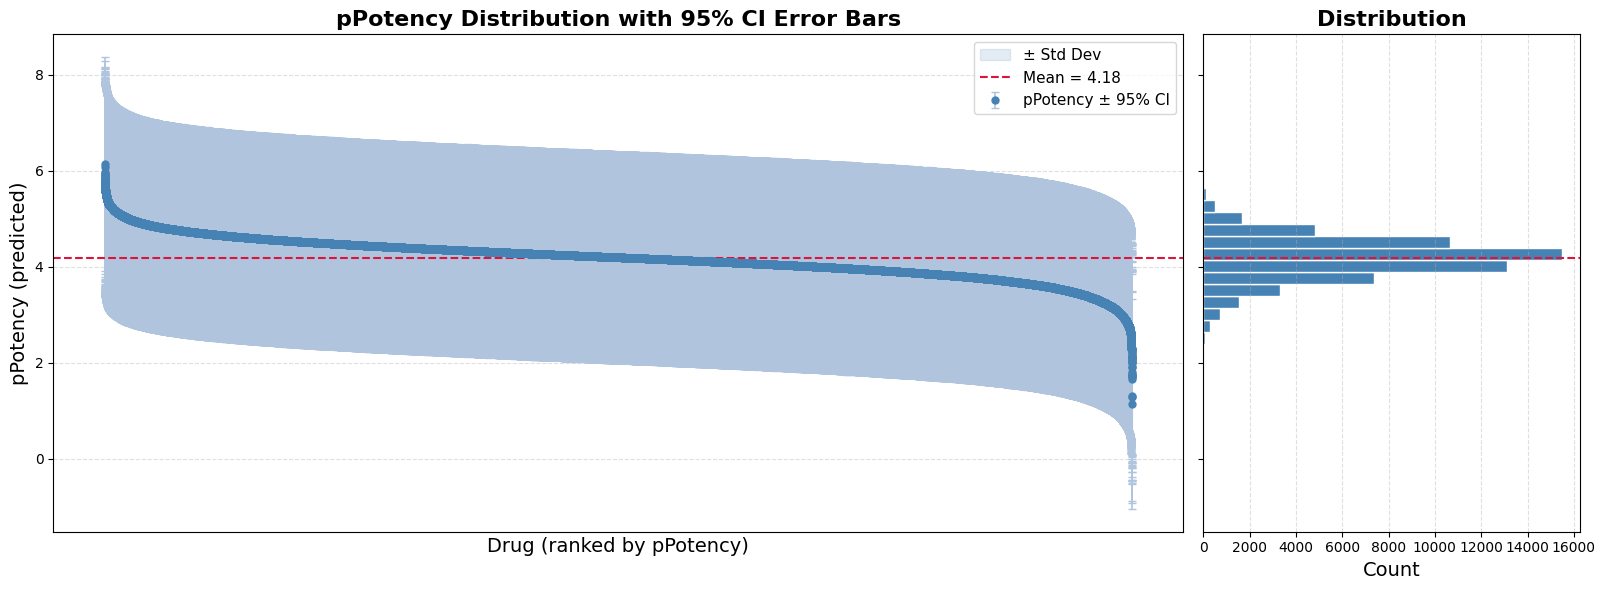

In [102]:
ppotencyDF = BacillusAnthracis_wART_Buyable_predicted_all.sort_values(
    "pPotency_prediction", ascending=False).reset_index(drop=True)

x = np.arange(len(ppotencyDF))
pred = ppotencyDF["pPotency_prediction"]
yerr = np.array([pred - ppotencyDF["pPotency_lower_95CI"],
                 ppotencyDF["pPotency_upper_95CI"] - pred])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6),
                                gridspec_kw={"width_ratios": [3, 1]}, sharey=True)

# ── Scatter + error bars ──────────────────────────────────────────────────────
ax1.errorbar(x, pred, yerr=yerr, fmt='o', color='steelblue', ecolor='lightsteelblue',
             elinewidth=1.2, capsize=3, markersize=5, alpha=1, label="pPotency ± 95% CI")
ax1.fill_between(x, pred - ppotencyDF["pPotency_std"], pred + ppotencyDF["pPotency_std"],
                 alpha=0.15, color='steelblue', label="± Std Dev")
ax1.axhline(pred.mean(),   color='crimson',    linestyle='--', linewidth=1.5, label=f'Mean = {pred.mean():.2f}')
#ax1.axhline(pred.median(), color='darkorange', linestyle=':',  linewidth=1.5, label=f'Median = {pred.median():.2f}')
ax1.set_xlabel("Drug (ranked by pPotency)", fontsize=14)  
ax1.set_ylabel("pPotency (predicted)",      fontsize=14) 
ax1.set_title("pPotency Distribution with 95% CI Error Bars", fontsize=16, fontweight='bold')  
ax1.set_xticks([])
ax1.legend(fontsize=11); ax1.grid(axis='y', linestyle='--', alpha=0.4)

# ── Histogram ─────────────────────────────────────────────────────────────────
ax2.hist(pred, bins=20, orientation='horizontal', color='steelblue', edgecolor='white', alpha=1)
ax2.axhline(pred.mean(),   color='crimson',    linestyle='--', linewidth=1.5)
#ax2.axhline(pred.median(), color='darkorange', linestyle=':',  linewidth=1.5)
ax2.set_xlabel("Count", fontsize=14)        
ax2.set_title("Distribution", fontsize=16, fontweight='bold') 
ax2.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_distribution_buyable.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_distribution_buyable.png")
plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### Read predicted `ADMET` properties for all candidate SMILES

In [103]:
BacillusAnthracis_wART_BuyableDataset_predicted_all_wToxicity = pd.read_csv(saveDir + f'{target_organism}_all_Buyable_AntiVirals_ARTprediction_wToxicity.csv')
# Identify columns that match the string
matched_cols = BacillusAnthracis_wART_BuyableDataset_predicted_all_wToxicity.filter(like='drugbank_approved_percentile').columns
# Keep everything EXCEPT those columns
BacillusAnthracis_wART_BuyableDataset_predicted_all_wToxicity = BacillusAnthracis_wART_BuyableDataset_predicted_all_wToxicity.drop(columns=matched_cols)
max_val = BacillusAnthracis_wART_BuyableDataset_predicted_all_wToxicity['pPotency_prediction'].max()
min_val = BacillusAnthracis_wART_BuyableDataset_predicted_all_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
BacillusAnthracis_wART_BuyableDataset_predicted_all_wToxicity

pPotency_prediction range: 1.141 → 6.143


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang,Clearance_Hepatocyte_AZ,Clearance_Microsome_AZ,Half_Life_Obach,HydrationFreeEnergy_FreeSolv,LD50_Zhu,Lipophilicity_AstraZeneca,PPBR_AZ,Solubility_AqSolDB,VDss_Lombardo
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,4.169872,1.119030,1.976573,6.363170,0.000068,4.333413e-07,0.010554,374.397,3.12552,...,-4.996861,118.607335,86.303194,0.484340,-5.984115,1.914311,3.002084,94.922207,-4.558344,11.722148
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,4.429163,1.118621,2.236666,6.621661,0.000037,2.389674e-07,0.005799,338.393,1.33666,...,-5.205537,42.327284,39.116500,-49.647802,-12.707386,1.809286,0.972791,88.427560,-3.252773,-1.914700
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,4.621105,1.118405,2.429031,6.813180,0.000024,1.537519e-07,0.003724,384.454,0.45232,...,-4.945433,105.007035,66.163495,-46.032595,-10.459297,1.995207,0.321122,71.043233,-2.603080,2.197672
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,4.521367,1.120633,2.324927,6.717807,0.000030,1.915106e-07,0.004732,346.416,1.90460,...,-5.257053,46.138803,3.781762,13.823905,-12.008407,2.166125,0.133414,70.917933,-2.653811,-3.392723
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,4.643503,1.119350,2.449576,6.837430,0.000023,1.454020e-07,0.003552,341.772,2.47350,...,-5.546406,9.270344,-16.773551,2.057861,-10.951267,2.766361,-0.750541,102.927616,-2.586969,-4.161391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46934,CNc1nc(Nc2ccccc2)nc2ccccc12,4.172397,1.119743,1.977701,6.367093,0.000067,4.294444e-07,0.010527,250.305,3.41510,...,-4.581137,94.550676,95.965427,67.867081,-9.766103,2.180136,3.347163,96.571909,-4.436477,9.117796
46935,Nc1nc(Nc2ccccc2F)nc2ccccc12,4.008815,1.118924,1.815724,6.201907,0.000098,6.281934e-07,0.015285,254.268,3.09470,...,-4.770010,66.496145,68.586421,27.236041,-11.552250,2.847540,2.901858,89.781617,-3.546711,1.054114
46936,CNc1nc(Nc2ccccc2F)nc2ccccc12,4.196679,1.119485,2.002488,6.390870,0.000064,4.065651e-07,0.009943,268.295,3.55420,...,-4.600024,88.097798,100.868810,55.791207,-10.121322,2.605350,3.409929,95.274537,-4.294779,2.445678
46937,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,4.423288,1.119218,2.229622,6.616955,0.000038,2.415712e-07,0.005894,270.723,3.60900,...,-4.658278,84.763380,81.986052,54.174968,-11.344900,2.844284,3.144153,93.304396,-4.252212,11.537782


### 2. Antibiotic candidate prioritization by comparing with `Drugbank`

In [104]:
refDrugbankDF = drugBankDrug_FDAapproved_antibiotic_wART_wADMET.copy()
generatedCandidateDF = BacillusAnthracis_wART_BuyableDataset_predicted_all_wToxicity.copy()

print("Drugbank reference dataframe shape:", refDrugbankDF.shape)
print("Generated candidate dataframe shape:", generatedCandidateDF.shape)

Drugbank reference dataframe shape: (132, 44)
Generated candidate dataframe shape: (46939, 57)


### 3. Harmonize metadata and the SMILES column

The candidate dataframe may use `SMILES` instead of `smiles`.  
This cell standardizes that and fills a few metadata fields if they are missing.

In [105]:
if "SMILES" in generatedCandidateDF.columns:
    generatedCandidateDF = generatedCandidateDF.rename(columns={"SMILES": "SMILES"})

if "ATC_code" not in generatedCandidateDF.columns:
    generatedCandidateDF["ATC_code"] = pd.NA

if "Drug_Type" not in generatedCandidateDF.columns:
    generatedCandidateDF["Drug_Type"] = "Predicted_candidate"

if "source_DataBase" not in generatedCandidateDF.columns:
    generatedCandidateDF["source_DataBase"] = "Generated"

refDrugbankDF["datasetLabel"] = "FDA-approved antibiotics"
generatedCandidateDF["datasetLabel"] = "Generated candidates"

print("smiles in refDrugbankDF:", "SMILES" in refDrugbankDF.columns)
print("smiles in generatedCandidateDF:", "SMILES" in generatedCandidateDF.columns)

smiles in refDrugbankDF: True
smiles in generatedCandidateDF: True


### 4. Define `ADMET` column groups

We keep:
- metadata
- potency-related columns
- toxicity-related columns
- ADME-related columns
- a few physicochemical property columns such as `QED`, `logP` and `molecular_weight`

In [106]:
metadataCols = [
    "SMILES",
    "ATC_code",
    "Drug_Type",
    "source_DataBase",
    "datasetLabel",
]

potencyCols = [
    "pPotency_prediction",
    "pPotency_std",
    "pPotency_lower_95CI",
    "pPotency_upper_95CI",
    "IC50(M)_prediction",
    "IC50(M)_lower_95CI",
    "IC50(M)_upper_95CI",
]

toxicityCols = [
    "AMES",
    "Carcinogens_Lagunin",
    "ClinTox",
    "DILI",
    "Skin_Reaction",
    "hERG",
    "LD50_Zhu",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma",
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
]

admeCols = [
    "Bioavailability_Ma",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Caco2_Wang",
    "Solubility_AqSolDB",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith",
    "Pgp_Broccatelli",
    "Clearance_Hepatocyte_AZ",
    "Clearance_Microsome_AZ",
    "Half_Life_Obach",
    "PPBR_AZ",
    "VDss_Lombardo",
]

optionalCols = ["BBB_Martins"]

physicochemCols = [
    "molecular_weight",
    "logP",
    "hydrogen_bond_acceptors",
    "hydrogen_bond_donors",
    "Lipinski",
    "QED",
    "stereo_centers",
    "tpsa",
    "HydrationFreeEnergy_FreeSolv",
    "Lipophilicity_AstraZeneca",
]

keepCols = list(dict.fromkeys(metadataCols + potencyCols + toxicityCols + admeCols + optionalCols + physicochemCols))
print("Total kept columns:", len(keepCols))

Total kept columns: 61


### 5. Build aligned reference and candidate dataframes

This cell keeps the same columns in both dataframes and creates any missing columns as `NaN`

In [107]:
def ensureCols(DF, colList):
    outDF = DF.copy()
    for colName in colList:
        if colName not in outDF.columns:
            outDF[colName] = np.nan
    return outDF[colList].copy()

refScoreDF = ensureCols(refDrugbankDF, keepCols)
candScoreDF = ensureCols(generatedCandidateDF, keepCols)

print("Reference aligned shape:", refScoreDF.shape)
print("Candidate aligned shape:", candScoreDF.shape)

Reference aligned shape: (132, 61)
Candidate aligned shape: (46939, 61)


### 6. Convert relevant columns to numeric

All scoring-related columns are converted to numeric.  

In [108]:
numericCols = list(dict.fromkeys(potencyCols + toxicityCols + admeCols + optionalCols + physicochemCols))

for colName in numericCols:
    if colName in refScoreDF.columns:
        refScoreDF[colName] = pd.to_numeric(refScoreDF[colName], errors="coerce")
    if colName in candScoreDF.columns:
        candScoreDF[colName] = pd.to_numeric(candScoreDF[colName], errors="coerce")

refScoreDF["potencyConservative"] = refScoreDF["pPotency_lower_95CI"].fillna(refScoreDF["pPotency_prediction"])
candScoreDF["potencyConservative"] = candScoreDF["pPotency_lower_95CI"].fillna(candScoreDF["pPotency_prediction"])

### 7. Define endpoint metadata

This table contains:
- endpoint name
- whether it belongs to the **toxicity** or **adme** group
- the direction of desirability:
  - `lowerBetter`
  - `higherBetter`
  - `referenceMatch`


In [109]:
endpointMetaDF = pd.DataFrame([
    # Toxicity
    {"endpoint": "AMES",                "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "Carcinogens_Lagunin", "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "ClinTox",             "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "DILI",                "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "Skin_Reaction",       "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "hERG",                "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "LD50_Zhu",            "majorGroup": "toxicity", "direction": "higherBetter"},
    {"endpoint": "NR-AR-LBD",           "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-AR",               "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-AhR",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-Aromatase",        "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-ER-LBD",           "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-ER",               "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-PPAR-gamma",       "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-ARE",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-ATAD5",            "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-HSE",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-MMP",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-p53",              "majorGroup": "toxicity", "direction": "lowerBetter"},

    # ADME
    {"endpoint": "Bioavailability_Ma",             "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "HIA_Hou",                        "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "PAMPA_NCATS",                    "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "Caco2_Wang",                     "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "Solubility_AqSolDB",             "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "CYP1A2_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP2C19_Veith",                  "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP2C9_Substrate_CarbonMangels", "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "CYP2C9_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP2D6_Substrate_CarbonMangels", "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "CYP2D6_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP3A4_Substrate_CarbonMangels", "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "CYP3A4_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "Pgp_Broccatelli",                "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "Clearance_Hepatocyte_AZ",        "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "Clearance_Microsome_AZ",         "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "Half_Life_Obach",                "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "PPBR_AZ",                        "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "VDss_Lombardo",                  "majorGroup": "adme", "direction": "referenceMatch"},
])

endpointMetaDF

,endpoint,majorGroup,direction
0,AMES,toxicity,lowerBetter
1,Carcinogens_Lagunin,toxicity,lowerBetter
2,ClinTox,toxicity,lowerBetter
3,DILI,toxicity,lowerBetter
4,Skin_Reaction,toxicity,lowerBetter
5,hERG,toxicity,lowerBetter
6,LD50_Zhu,toxicity,higherBetter
7,NR-AR-LBD,toxicity,lowerBetter
8,NR-AR,toxicity,lowerBetter
9,NR-AhR,toxicity,lowerBetter


### 8. Derive fully statistical endpoint weights from FDA-approved antibiotics from `Drugbank`

For each endpoint we compute:

- **informativeness** = inverse of the reference IQR  
  A tighter approved-antibiotic distribution means the endpoint is more constrained and therefore more informative.

- **uniqueness** = inverse redundancy penalty  
  Endpoints that are highly correlated with other endpoints in the same group get reduced weight.

The final endpoint weights are normalized inside each major group:
- `toxicity`
- `adme`

In [110]:
def robustIQR(series):
    cleanSeries = pd.to_numeric(series, errors="coerce").dropna()
    if len(cleanSeries) < 5:
        return np.nan
    q25, q75 = np.percentile(cleanSeries, [25, 75])
    return q75 - q25

weightRows = []

for majorGroupName in endpointMetaDF["majorGroup"].unique():
    groupMetaDF = endpointMetaDF[endpointMetaDF["majorGroup"] == majorGroupName].copy()
    groupEndpoints = groupMetaDF["endpoint"].tolist()

    groupRefDF = refScoreDF[groupEndpoints].apply(pd.to_numeric, errors="coerce")
    groupCorrDF = groupRefDF.corr().abs()

    for endpointName in groupEndpoints:
        series = groupRefDF[endpointName]
        iqrValue = robustIQR(series)

        informativeness = 1.0 / (iqrValue + 1e-6) if pd.notna(iqrValue) else 1.0

        otherEndpoints = [x for x in groupEndpoints if x != endpointName]
        if len(otherEndpoints) > 0 and endpointName in groupCorrDF.index:
            meanAbsCorr = groupCorrDF.loc[endpointName, otherEndpoints].dropna().mean()
            uniqueness = max(1.0 - meanAbsCorr, 1e-3) if pd.notna(meanAbsCorr) else 1.0
        else:
            uniqueness = 1.0

        rawWeight = informativeness * uniqueness

        weightRows.append({
            "endpoint": endpointName,
            "majorGroup": majorGroupName,
            "direction": groupMetaDF.loc[groupMetaDF["endpoint"] == endpointName, "direction"].iloc[0],
            "iqrValue": iqrValue,
            "informativeness": informativeness,
            "uniqueness": uniqueness,
            "rawWeight": rawWeight,
        })

weightDF = pd.DataFrame(weightRows)
weightDF["finalWeight"] = (
    weightDF.groupby("majorGroup")["rawWeight"]
    .transform(lambda x: x / x.sum())
)

weightDF.sort_values(["majorGroup", "finalWeight"], ascending=[True, False])

,endpoint,majorGroup,direction,iqrValue,informativeness,uniqueness,rawWeight,finalWeight
24,CYP1A2_Veith,adme,lowerBetter,0.007583,131.856666,0.875912,115.494897,0.374049
27,CYP2C9_Veith,adme,lowerBetter,0.015054,66.424005,0.743478,49.384762,0.159941
29,CYP2D6_Veith,adme,lowerBetter,0.023108,43.273037,0.852122,36.873917,0.119422
25,CYP2C19_Veith,adme,lowerBetter,0.020200,49.501684,0.716789,35.482260,0.114915
28,CYP2D6_Substrate_CarbonMangels,adme,referenceMatch,0.027401,36.494317,0.742754,27.106292,0.087788
31,CYP3A4_Veith,adme,lowerBetter,0.048597,20.577056,0.715226,14.717253,0.047664
32,Pgp_Broccatelli,adme,referenceMatch,0.087841,11.384115,0.775158,8.824486,0.028580
26,CYP2C9_Substrate_CarbonMangels,adme,referenceMatch,0.105874,9.445118,0.747599,7.061157,0.022869
30,CYP3A4_Substrate_CarbonMangels,adme,referenceMatch,0.278713,3.587905,0.749184,2.688000,0.008706
21,PAMPA_NCATS,adme,higherBetter,0.311315,3.212166,0.586158,1.882835,0.006098


### 9. Helper functions for desirability scoring and weighted aggregation

This section defines:

- percentile-based desirability functions
- a reference-matching desirability function
- weighted geometric mean aggregation

In [111]:
def getSortedRefArray(refSeries):
    refArray = pd.to_numeric(refSeries, errors="coerce").dropna().to_numpy(dtype=float)
    refArray = refArray[np.isfinite(refArray)]
    refArray = np.sort(refArray)
    return refArray

def higherBetterDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan, dtype=float)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    finiteMask = np.isfinite(valueArray)
    percentArray = np.searchsorted(refArray, valueArray[finiteMask], side="right") / len(refArray)
    outArray[finiteMask] = np.clip(percentArray, 0.0, 1.0)
    return pd.Series(outArray, index=valueSeries.index)

def lowerBetterDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan, dtype=float)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    finiteMask = np.isfinite(valueArray)
    percentArray = np.searchsorted(refArray, valueArray[finiteMask], side="right") / len(refArray)
    outArray[finiteMask] = np.clip(1.0 - percentArray, 0.0, 1.0)
    return pd.Series(outArray, index=valueSeries.index)

def referenceMatchDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan, dtype=float)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    refMedian = np.nanmedian(refArray)
    q25, q75 = np.nanpercentile(refArray, [25, 75])
    robustSigma = (q75 - q25) / 1.349 if q75 > q25 else np.nanstd(refArray)

    if not np.isfinite(robustSigma) or robustSigma <= 0:
        robustSigma = 1e-6

    finiteMask = np.isfinite(valueArray)
    zArray = (valueArray[finiteMask] - refMedian) / robustSigma
    outArray[finiteMask] = np.exp(-0.5 * (zArray ** 2))
    outArray = np.clip(outArray, 0.0, 1.0)

    return pd.Series(outArray, index=valueSeries.index)

def weightedGeoMeanSeries(DF, valueColList, weightSeries):
    valueMatrix = DF[valueColList].to_numpy(dtype=float)
    weightArray = np.asarray(weightSeries, dtype=float)
    outArray = np.full(valueMatrix.shape[0], np.nan, dtype=float)

    for rowIdx in range(valueMatrix.shape[0]):
        rowArray = valueMatrix[rowIdx]
        finiteMask = np.isfinite(rowArray)

        if finiteMask.sum() == 0:
            continue

        rowValues = np.clip(rowArray[finiteMask], 1e-6, 1.0)
        rowWeights = weightArray[finiteMask]
        outArray[rowIdx] = np.exp(np.sum(rowWeights * np.log(rowValues)) / np.sum(rowWeights))

    return pd.Series(outArray, index=DF.index)

### 10. Convert endpoints into 0–1 desirability scores

Every endpoint becomes a new `*_des` column.
We also compute `PotencyDesRaw` from the reference antibiotic potency distribution.

In [112]:
for _, rowDF in weightDF.iterrows():
    endpointName = rowDF["endpoint"]
    directionName = rowDF["direction"]
    desCol = f"{endpointName}_des"

    if directionName == "higherBetter":
        refScoreDF[desCol] = higherBetterDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desCol] = higherBetterDes(refScoreDF[endpointName], candScoreDF[endpointName])

    elif directionName == "lowerBetter":
        refScoreDF[desCol] = lowerBetterDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desCol] = lowerBetterDes(refScoreDF[endpointName], candScoreDF[endpointName])

    elif directionName == "referenceMatch":
        refScoreDF[desCol] = referenceMatchDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desCol] = referenceMatchDes(refScoreDF[endpointName], candScoreDF[endpointName])

refScoreDF["PotencyDesRaw"] = higherBetterDes(
    refScoreDF["pPotency_prediction"],
    refScoreDF["pPotency_prediction"]
)

candScoreDF["PotencyDesRaw"] = higherBetterDes(
    refScoreDF["pPotency_prediction"],
    candScoreDF["pPotency_prediction"]
)
refScoreDF

,SMILES,ATC_code,Drug_Type,source_DataBase,datasetLabel,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,...,CYP2D6_Veith_des,CYP3A4_Substrate_CarbonMangels_des,CYP3A4_Veith_des,Pgp_Broccatelli_des,Clearance_Hepatocyte_AZ_des,Clearance_Microsome_AZ_des,Half_Life_Obach_des,PPBR_AZ_des,VDss_Lombardo_des,PotencyDesRaw
0,NCC[C@H](O)C(=O)N[C@@H]1C[C@H](N)[C@@H](O[C@H]...,J01GB;J01RA,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,3.525954,1.119518,1.331698,5.720210,0.000298,...,0.477273,0.972613,0.818182,9.681491e-01,NaN,NaN,NaN,NaN,NaN,0.378788
1,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccc(O)cc3)...,J01CA;J01CR,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,4.987345,1.120375,2.791410,7.183280,0.000010,...,0.674242,0.830805,0.780303,9.318440e-01,NaN,NaN,NaN,NaN,NaN,0.977273
2,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](NC(=O)N3CCNC3=...,J01CA;J01CR,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,3.442877,1.119518,1.248620,5.637133,0.000361,...,0.825758,0.974109,0.765152,9.540457e-01,NaN,NaN,NaN,NaN,NaN,0.340909
3,C[C@H]1[C@H](NC(=O)/C(=N\OC(C)(C)C(=O)O)c2csc(...,J01DF,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,3.786489,1.118681,1.593873,5.979105,0.000163,...,0.750000,0.872005,0.893939,9.876953e-01,NaN,NaN,NaN,NaN,NaN,0.454545
4,CCOC(=O)OC(C)OC(=O)[C@@H]1N2C(=O)[C@@H](NC(=O)...,J01CA;J01CR,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,3.794162,1.118931,1.601058,5.987267,0.000161,...,0.022727,0.378266,0.030303,2.050005e-01,NaN,NaN,NaN,NaN,NaN,0.469697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,J01AA,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,4.309461,1.118857,2.116502,6.502420,0.000049,...,0.189394,0.214633,0.371212,5.888156e-01,NaN,NaN,NaN,NaN,NaN,0.810606
128,CCS(=O)(=O)CCn1c([N+](=O)[O-])cnc1C,J01RA;J01XD,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,4.424298,1.118918,2.231218,6.617377,0.000038,...,0.931818,0.066655,0.856061,8.940999e-01,NaN,NaN,NaN,NaN,NaN,0.878788
129,CO[C@H]1C[C@H](O[C@H]2[C@H](C)[C@@H](O[C@@H]3O...,J01FA,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,2.276538,1.125678,0.070209,4.482867,0.005290,...,0.462121,0.078071,0.022727,2.447435e-41,NaN,NaN,NaN,NaN,NaN,0.068182
130,N[C@@H]1[C@H]2CN(c3nc4c(cc3F)c(=O)c(C(=O)O)cn4...,J01MA,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,3.073553,1.126205,0.866192,5.280915,0.000844,...,0.151515,0.847208,0.522727,9.819411e-01,NaN,NaN,NaN,NaN,NaN,0.265152


### 11. Directly aggregate within the two separate ADMET groups

This notebook uses:
- one direct **toxicity** aggregate
- one direct **adme** aggregate

Then we define:
- `ToxicitySafety`
- `Toxicity Score = 1 - ToxicitySafety`
- `ADMEFeasibility`

In [113]:
toxWeightDF = weightDF[weightDF["majorGroup"] == "toxicity"].copy()
admeWeightDF = weightDF[weightDF["majorGroup"] == "adme"].copy()

toxDesCols = [f"{endpointName}_des" for endpointName in toxWeightDF["endpoint"]]
admeDesCols = [f"{endpointName}_des" for endpointName in admeWeightDF["endpoint"]]

refScoreDF["ToxicitySafety"] = weightedGeoMeanSeries(
    refScoreDF,
    toxDesCols,
    toxWeightDF["finalWeight"]
)
candScoreDF["ToxicitySafety"] = weightedGeoMeanSeries(
    candScoreDF,
    toxDesCols,
    toxWeightDF["finalWeight"]
)

refScoreDF["ADMEFeasibility"] = weightedGeoMeanSeries(
    refScoreDF,
    admeDesCols,
    admeWeightDF["finalWeight"]
)
candScoreDF["ADMEFeasibility"] = weightedGeoMeanSeries(
    candScoreDF,
    admeDesCols,
    admeWeightDF["finalWeight"]
)

refScoreDF["coreToxicityScore"] = 1.0 - refScoreDF["ToxicitySafety"]
candScoreDF["coreToxicityScore"] = 1.0 - candScoreDF["ToxicitySafety"]

refScoreDF["ToxicityBurden"] = refScoreDF["coreToxicityScore"]
candScoreDF["ToxicityBurden"] = candScoreDF["coreToxicityScore"]

refScoreDF[["pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"]].describe().T

,count,mean,std,min,25%,50%,75%,max
pPotency_prediction,132.0,3.684012,0.821362,1.343247,3.046390,3.928463,4.233035,5.897288
coreToxicityScore,132.0,0.570184,0.217179,0.162787,0.405250,0.589680,0.734321,0.998633
ADMEFeasibility,132.0,0.442508,0.239315,0.002264,0.262605,0.418293,0.628735,0.939134


## 12. Inspect the statistically derived endpoint weights

In [114]:
weightDF.sort_values(["majorGroup", "finalWeight"], ascending=[True, False])

,endpoint,majorGroup,direction,iqrValue,informativeness,uniqueness,rawWeight,finalWeight
24,CYP1A2_Veith,adme,lowerBetter,0.007583,131.856666,0.875912,115.494897,0.374049
27,CYP2C9_Veith,adme,lowerBetter,0.015054,66.424005,0.743478,49.384762,0.159941
29,CYP2D6_Veith,adme,lowerBetter,0.023108,43.273037,0.852122,36.873917,0.119422
25,CYP2C19_Veith,adme,lowerBetter,0.020200,49.501684,0.716789,35.482260,0.114915
28,CYP2D6_Substrate_CarbonMangels,adme,referenceMatch,0.027401,36.494317,0.742754,27.106292,0.087788
31,CYP3A4_Veith,adme,lowerBetter,0.048597,20.577056,0.715226,14.717253,0.047664
32,Pgp_Broccatelli,adme,referenceMatch,0.087841,11.384115,0.775158,8.824486,0.028580
26,CYP2C9_Substrate_CarbonMangels,adme,referenceMatch,0.105874,9.445118,0.747599,7.061157,0.022869
30,CYP3A4_Substrate_CarbonMangels,adme,referenceMatch,0.278713,3.587905,0.749184,2.688000,0.008706
21,PAMPA_NCATS,adme,higherBetter,0.311315,3.212166,0.586158,1.882835,0.006098


### 13. Plot: `high pPotency` and `low Toxicity Score`

Selection rule:
- pPotency in the top quartile of generated compounds
- Toxicity Score in the bottom quartile of generated compounds

Within that selected region, ranking uses the geometric mean of:
- `PotencyDesRaw`
- `ToxicitySafety`

In [115]:
cand2DDF = candScoreDF.copy()

cand2DDF = cand2DDF[
    cand2DDF[["pPotency_prediction", "coreToxicityScore", "ToxicitySafety", "PotencyDesRaw"]]
    .notna()
    .all(axis=1)
].copy()

xCutoff2D = cand2DDF["pPotency_prediction"].quantile(0.75)
yCutoff2D = cand2DDF["coreToxicityScore"].quantile(0.25)

optimal2DDF = cand2DDF[
    (cand2DDF["pPotency_prediction"] >= xCutoff2D) &
    (cand2DDF["coreToxicityScore"] <= yCutoff2D)
].copy()

optimal2DDF["OverallPriority2D"] = np.sqrt(
    optimal2DDF["PotencyDesRaw"] * optimal2DDF["ToxicitySafety"]
)

top20_2D_DF = optimal2DDF.sort_values(
    by=["OverallPriority2D", "pPotency_prediction", "coreToxicityScore"],
    ascending=[False, False, True]
).head(20).copy()

top20_2D_DF["Top20Rank_2D"] = np.arange(1, len(top20_2D_DF) + 1)

top20_2D_DF[
    [
        "Top20Rank_2D",
        "SMILES",
        "pPotency_prediction",
        "pPotency_std",
        "pPotency_lower_95CI",
        "coreToxicityScore",
        "ToxicitySafety",
        "OverallPriority2D",
        "QED",
    ]
]

,Top20Rank_2D,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,coreToxicityScore,ToxicitySafety,OverallPriority2D,QED
18283,1,COc1ccc(S(=O)(=O)NC(=O)C2CCOCC2)cc1,4.938421,1.119496,2.744210,0.107247,0.892753,0.926789,0.894027
10949,2,CNC(=O)NC1CCN(CC2(C)CN(Cc3ccccc3)C2=O)CC1,5.081690,1.124261,2.878139,0.126384,0.873616,0.923992,0.794432
4738,3,COC(=O)C1CCC2(CC1)CC(=O)N2,4.502238,1.118620,2.309742,0.081125,0.918875,0.913970,0.494654
12709,4,CCn1ccnc1CN1CCN(CCCS(N)(=O)=O)CC1,4.732647,1.120267,2.536924,0.116777,0.883223,0.910875,0.746592
29416,5,CCc1cc(NS(=O)(=O)c2cnn(CC)c2)nc(C)n1,4.549990,1.119508,2.355755,0.095437,0.904563,0.910595,0.899297
12708,6,Cc1nc(C)n(CC2CCCCN2CCCS(N)(=O)=O)n1,4.551219,1.119039,2.357903,0.096983,0.903017,0.909816,0.821215
17121,7,COC(=O)N1CCCC1C(=O)NS(=O)(=O)c1ccc(F)cc1F,4.902949,1.119396,2.708932,0.127813,0.872187,0.908810,0.879671
12475,8,CCC(OC)C(=O)NS(=O)(=O)c1cccc(S(C)(=O)=O)c1,4.650518,1.119580,2.456142,0.117924,0.882076,0.902913,0.802197
965,9,CNS(=O)(=O)c1cccc(CNC(=O)NC2CC(=O)N(C)C2)c1,4.476564,1.119016,2.283294,0.103610,0.896390,0.902718,0.679205
580,10,CC1CN(CCCS(N)(=O)=O)CCN1Cc1nccn1C,4.492868,1.118457,2.300692,0.110900,0.889100,0.899040,0.772367


### 14. plot: pPotency vs Toxicity Score

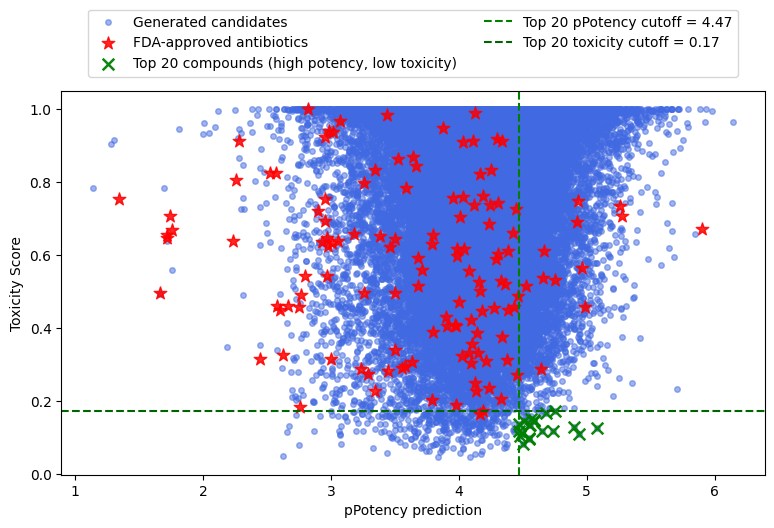

In [116]:
# Display cutoffs from the actual top 20 compounds
xDisplay = top20_2D_DF["pPotency_prediction"].min()
yDisplay = top20_2D_DF["coreToxicityScore"].max()

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    cand2DDF["pPotency_prediction"],
    cand2DDF["coreToxicityScore"],
    s=16, alpha=0.5, color="royalblue", label="Generated candidates"
)

ax.scatter(
    refScoreDF["pPotency_prediction"],
    refScoreDF["coreToxicityScore"],
    marker="*", s=90, alpha=0.85, color="red", label="FDA-approved antibiotics"
)

ax.scatter(
    top20_2D_DF["pPotency_prediction"],
    top20_2D_DF["coreToxicityScore"],
    marker="x", s=70, linewidths=1.8, alpha=0.95, color="green",
    label="Top 20 compounds (high potency, low toxicity)"
)

ax.axvline(
    xDisplay,
    linestyle="--",
    linewidth=1.5,
    color="green",
    label=f"Top 20 pPotency cutoff = {xDisplay:.2f}"
)

ax.axhline(
    yDisplay,
    linestyle="--",
    linewidth=1.5,
    color="darkgreen",
    label=f"Top 20 toxicity cutoff = {yDisplay:.2f}"
)

ax.set_xlabel("pPotency prediction")
ax.set_ylabel("Toxicity Score")

ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.90])

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_buyable.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_buyable.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

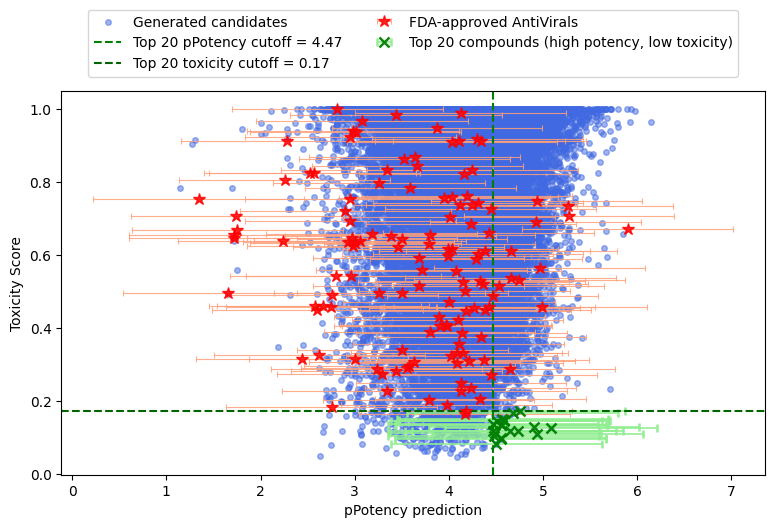

In [117]:
# Display cutoffs from the actual top 20 compounds
xDisplay = top20_2D_DF["pPotency_prediction"].min()
yDisplay = top20_2D_DF["coreToxicityScore"].max()

fig, ax = plt.subplots(figsize=(8, 6))

# ── Helper to compute asymmetric xerr ────────────────────────────────────────
'''
def get_xerr(df):
    return np.array([
        df["pPotency_prediction"] - df["pPotency_lower_95CI"],
        df["pPotency_upper_95CI"] - df["pPotency_prediction"],
    ])
'''

def get_xerr(df):
    return df["pPotency_std"].values  # symmetric → single array, not shape(2,N)


# ── Generated candidates ──────────────────────────────────────────────────────
ax.scatter(
    cand2DDF["pPotency_prediction"],
    cand2DDF["coreToxicityScore"],
    s=16, alpha=0.5, color="royalblue", label="Generated candidates"
)


# ── FDA-approved AntiVirals ───────────────────────────────────────────────────
ax.errorbar(
    refScoreDF["pPotency_prediction"],
    refScoreDF["coreToxicityScore"],
    xerr=get_xerr(refScoreDF),
    fmt="*", color="red", ecolor="lightsalmon",
    elinewidth=0.8, capsize=2, capthick=0.8,
    markersize=9, alpha=0.85, label="FDA-approved AntiVirals"
)

# ── Top 20 compounds ──────────────────────────────────────────────────────────
ax.errorbar(
    top20_2D_DF["pPotency_prediction"],
    top20_2D_DF["coreToxicityScore"],
    xerr=get_xerr(top20_2D_DF),
    fmt="x", color="green", ecolor="lightgreen",
    elinewidth=1.2, capsize=3, capthick=1.2,
    markersize=7, markeredgewidth=1.8,
    alpha=0.95, label="Top 20 compounds (high potency, low toxicity)"
)

ax.axvline(xDisplay, linestyle="--", linewidth=1.5, color="green",
           label=f"Top 20 pPotency cutoff = {xDisplay:.2f}")
ax.axhline(yDisplay, linestyle="--", linewidth=1.5, color="darkgreen",
           label=f"Top 20 toxicity cutoff = {yDisplay:.2f}")

ax.set_xlabel("pPotency prediction")
ax.set_ylabel("Toxicity Score")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.90])

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_buyable.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_buyable.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### 15. Plot: `high pPotency`, `low Toxicity Score`, `high ADME feasibility`

Selection rule:
- pPotency in the top quartile
- Toxicity Score in the bottom quartile
- ADMEFeasibility in the top quartile

Within that region, ranking uses the unweighted geometric mean of:
- `PotencyDesRaw`
- `ToxicitySafety`
- `ADMEFeasibility`

In [118]:
cand3DDF = candScoreDF.copy()

cand3DDF = cand3DDF[
    cand3DDF[["pPotency_prediction", "coreToxicityScore", "ADMEFeasibility", "ToxicitySafety", "PotencyDesRaw"]]
    .notna()
    .all(axis=1)
].copy()

xCutoff3D = cand3DDF["pPotency_prediction"].quantile(0.75)
yCutoff3D = cand3DDF["coreToxicityScore"].quantile(0.25)
zCutoff3D = cand3DDF["ADMEFeasibility"].quantile(0.75)

optimal3DDF = cand3DDF[
    (cand3DDF["pPotency_prediction"] >= xCutoff3D) &
    (cand3DDF["coreToxicityScore"] <= yCutoff3D) &
    (cand3DDF["ADMEFeasibility"] >= zCutoff3D)
].copy()

optimal3DDF["OverallPriority3D"] = (
    optimal3DDF["PotencyDesRaw"] *
    optimal3DDF["ToxicitySafety"] *
    optimal3DDF["ADMEFeasibility"]
) ** (1 / 3)

top20_3D_DF = optimal3DDF.sort_values(
    by=["OverallPriority3D", "pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"],
    ascending=[False, False, True, False]
).head(20).copy()

top20_3D_DF["Top20Rank_3D"] = np.arange(1, len(top20_3D_DF) + 1)

top20_3D_DF[
    [
        "Top20Rank_3D",
        "SMILES",
        "pPotency_prediction",
        "pPotency_std",
        "pPotency_lower_95CI",
        "coreToxicityScore",
        "ADMEFeasibility",
        "ToxicitySafety",
        "OverallPriority3D",
        "QED",
    ]
]

,Top20Rank_3D,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,coreToxicityScore,ADMEFeasibility,ToxicitySafety,OverallPriority3D,QED
8314,1,CNS(=O)(=O)c1cc(C(=O)NCc2nnc3n2CCC3)n(C)c1,4.550343,1.119746,2.355641,0.132172,0.846446,0.867828,0.876492,0.756244
31946,2,CCNC(=O)Cn1cnc2c1c(=O)[nH]c(=O)n2C,4.467259,1.118963,2.274091,0.136608,0.822509,0.863392,0.864275,0.697022
14322,3,Cc1cc(C(=O)O)ccc1S(=O)(=O)NCC1(C)CCC(=O)N1,4.601779,1.119041,2.408458,0.219509,0.791335,0.780491,0.827269,0.734832
27418,4,CCn1cnnc1CNC(=O)c1cc(S(N)(=O)=O)ccc1OC,4.473383,1.118918,2.280303,0.116490,0.697569,0.883510,0.824395,0.754839
10356,5,Cc1cc(C(=O)N2CCn3c(C)nnc3C2)cc(S(N)(=O)=O)c1C,4.486447,1.118452,2.294281,0.185218,0.730126,0.814782,0.814733,0.848821
11013,6,NCc1cc(C(=O)N2CCC(C(=O)O)CC2)[nH]n1,4.524980,1.119295,2.331162,0.167512,0.690488,0.832488,0.805466,0.689557
31251,7,CNS(=O)(=O)c1ccc(CN2CCCC2(C)C(=O)O)cc1,4.482377,1.120119,2.286944,0.159798,0.672573,0.840202,0.800897,0.847944
17528,8,Cn1ccc(C(=O)N2CCC(C)(NC(=O)CC3(C)CCS(=O)(=O)N3...,4.553625,1.119175,2.360042,0.279497,0.765539,0.720503,0.796657,0.777769
25891,9,CCn1cc(S(=O)(=O)NCc2ncnn2C(C)C)cn1,4.560789,1.119303,2.366956,0.230822,0.711710,0.769178,0.794659,0.840248
32508,10,Cn1c(=O)[nH]c(=O)c2c1nc(CN1CCOCC1)n2CC(N)=O,4.449348,1.118592,2.256907,0.300798,0.801957,0.699202,0.794366,0.653685


### 16. plot: pPotency vs Toxicity Score vs ADME feasibility

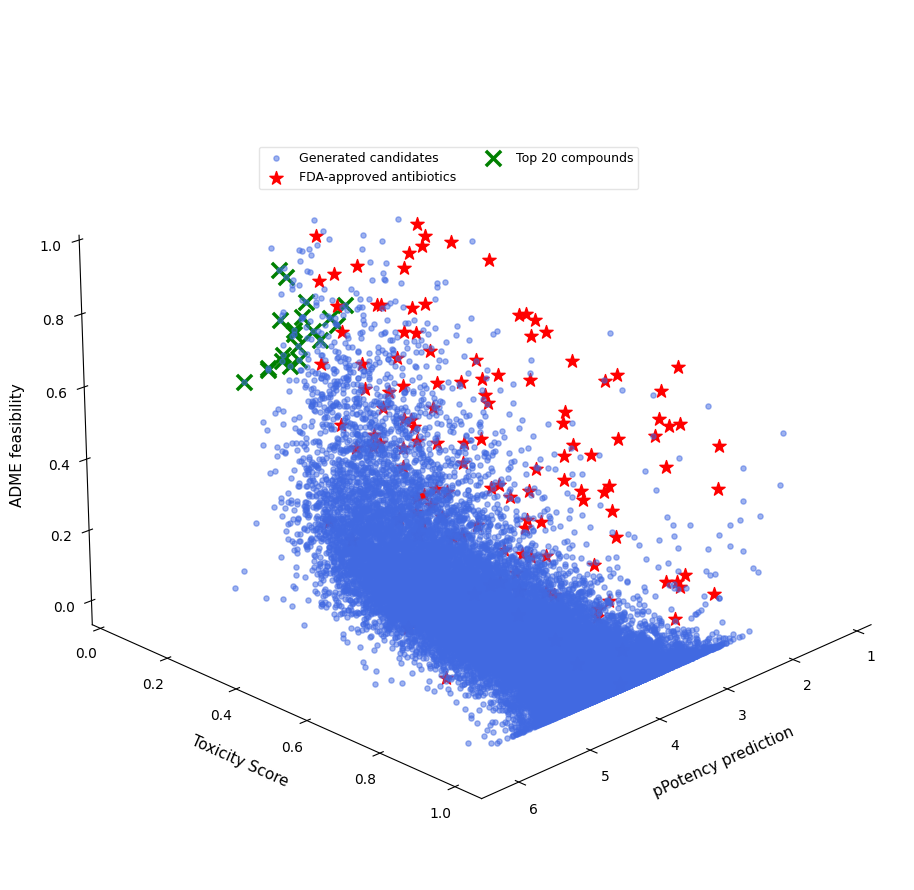

In [119]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(13, 10))
ax  = fig.add_subplot(111, projection="3d")

fig.patch.set_alpha(0.0)
ax.set_facecolor((0, 0, 0, 0))

for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
    pane.fill = False
    pane.set_edgecolor("lightgray")
    pane.set_alpha(0.0)

ax.grid(False)
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"]["linewidth"] = 0
    axis.label.set_color("k")
    axis.set_tick_params(colors="k")

ax.scatter(
    cand3DDF["pPotency_prediction"], cand3DDF["coreToxicityScore"], cand3DDF["ADMEFeasibility"],
    s=14, alpha=0.5, color="royalblue", label="Generated candidates", depthshade=False,
)
ax.scatter(
    refScoreDF["pPotency_prediction"], refScoreDF["coreToxicityScore"], refScoreDF["ADMEFeasibility"],
    marker="*", s=100, alpha=1.0, color="red", label="FDA-approved antibiotics", depthshade=False,
)
ax.scatter(
    top20_3D_DF["pPotency_prediction"], top20_3D_DF["coreToxicityScore"], top20_3D_DF["ADMEFeasibility"],
    marker="x", s=120, linewidths=2.5, alpha=1.0, color="green", label="Top 20 compounds", depthshade=False,
)

xCutoff = top20_3D_DF["pPotency_prediction"].min()
yCutoff = top20_3D_DF["coreToxicityScore"].max()
zCutoff = top20_3D_DF["ADMEFeasibility"].min()

xMin, xMax = ax.get_xlim()
yMin, yMax = ax.get_ylim()
zMin, zMax = ax.get_zlim()

#cutoffStyle = dict(linewidth=1.8, linestyle="--", alpha=0.85)
#ax.plot([xMin,    xCutoff], [yCutoff, yCutoff], [zCutoff, zCutoff], color="green",     label=f"pPotency cutoff = {xCutoff:.2f}", **cutoffStyle)
#ax.plot([xCutoff, xCutoff], [yCutoff, yMax],    [zCutoff, zCutoff], color="darkolivegreen", label=f"Toxicity cutoff = {yCutoff:.2f}", **cutoffStyle)
#ax.plot([xCutoff, xCutoff], [yCutoff, yCutoff], [zMin,    zCutoff], color="seagreen",  label=f"ADME cutoff = {zCutoff:.2f}",    **cutoffStyle)
#ax.scatter([xCutoff], [yCutoff], [zCutoff], marker="D", s=180, color="gold", edgecolors="darkorange", linewidths=1.5, zorder=10, label="Optimal cutoff corner", depthshade=False)

ax.set_xlabel("pPotency prediction", labelpad=10, color="k", fontsize=11)
ax.set_ylabel("Toxicity Score", labelpad=10, color="k", fontsize=11)
ax.set_zlabel("ADME feasibility",    labelpad=10, color="k", fontsize=11)
ax.set_zlabel("")
ax.text2D(-0.02, 0.5, "ADME feasibility", transform=ax.transAxes, fontsize=11, color="k", rotation=90, va="center", ha="center")

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.set_tick_params(colors="k", labelsize=10)

ax.view_init(elev=22, azim=45)
ax.legend(loc="upper left", bbox_to_anchor=(0.25, 0.85), ncol=2, frameon=True, framealpha=0.3, facecolor="white", edgecolor="darkgray", labelcolor="black", fontsize=9)
fig.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.05)

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_3d_buyable.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_3d_buyable.png")
plt.savefig(svg_path, format="svg", dpi=600, transparent=True, pad_inches=0.5)
plt.savefig(png_path, format="png", dpi=600, transparent=True, pad_inches=0.5)
plt.show()

### 17. Custom projected 3D plot for presentation

This is a presentation-oriented 2D projection of 3 variables.

Projected axes:
- horizontal right = `pPotency`
- vertical up = `Toxicity Score`
- diagonal lower-left = `ADME feasibility`

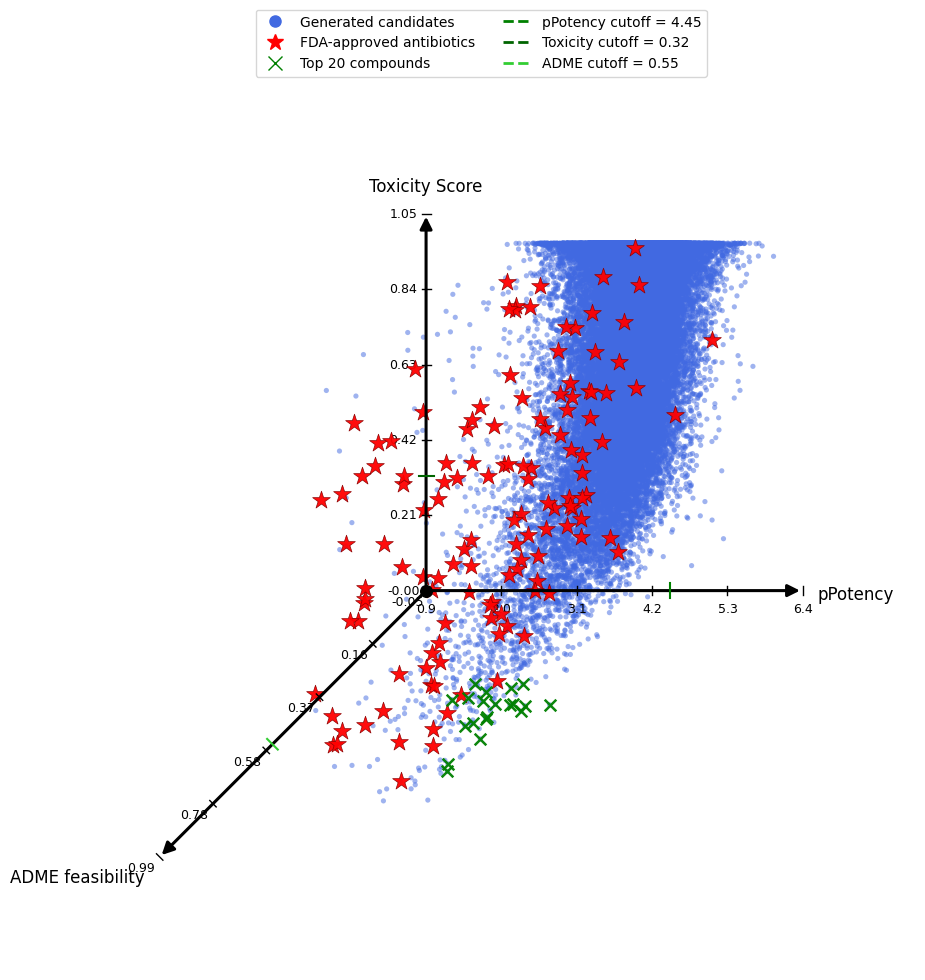

In [120]:
xCol, yCol, zCol = "pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"
cols = [xCol, yCol, zCol]

allPlotDF = cand3DDF[cols][np.isfinite(cand3DDF[cols]).all(axis=1)].copy()
refPlotDF = refScoreDF[cols][np.isfinite(refScoreDF[cols]).all(axis=1)].copy()
topPlotDF = top20_3D_DF[cols][np.isfinite(top20_3D_DF[cols]).all(axis=1)].copy()

def paddedRange(arr, frac=0.05):
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    pad = (hi - lo) * frac if (hi - lo) > 0 else 1.0
    return lo - pad, hi + pad

combined          = pd.concat([allPlotDF, refPlotDF, topPlotDF])
(X_MIN, X_MAX), (Y_MIN, Y_MAX), (Z_MIN, Z_MAX) = [paddedRange(combined[c]) for c in cols]

O  = np.zeros(2)
UX = np.array([1.0, 0.0])
UY = np.array([0.0, 1.0])
UZ = np.array([math.cos(math.radians(225)), math.sin(math.radians(225))])

def project(x, y, z):
    return O + ((x-X_MIN)/(X_MAX-X_MIN))*UX + ((y-Y_MIN)/(Y_MAX-Y_MIN))*UY + ((z-Z_MIN)/(Z_MAX-Z_MIN))*UZ

def projectDF(df):
    pts = np.array([project(r[xCol], r[yCol], r[zCol]) for _, r in df.iterrows()])
    return pts[:, 0], pts[:, 1]

allCX, allCY = projectDF(allPlotDF)
refCX, refCY = projectDF(refPlotDF)
topCX, topCY = projectDF(topPlotDF)

TIP_X, TIP_Y, TIP_Z = O + UX, O + UY, O + UZ

fig, ax = plt.subplots(figsize=(12, 11), facecolor="white")
ax.set(facecolor="white", aspect="equal")
ax.axis("off")

for tip in [TIP_X, TIP_Y, TIP_Z]:
    ax.annotate("", xy=tip, xytext=O, zorder=5,
                arrowprops=dict(arrowstyle="-|>", color="black", lw=2.2, mutation_scale=18))

ax.scatter(*O, s=70, c="black", zorder=6)

def drawTicks(unitVec, valMin, valMax, offset, nTicks=5, fmt="{:.2f}"):
    perp = np.array([unitVec[1], -unitVec[0]])
    perp /= np.linalg.norm(perp)
    for i in range(nTicks + 1):
        t, pos = i / nTicks, O + (i / nTicks) * unitVec
        ax.plot(*zip(pos - 0.012*perp, pos + 0.012*perp), color="black", lw=1.0, zorder=5)
        ax.text(*(pos + offset), fmt.format(valMin + t*(valMax-valMin)), fontsize=9, ha="center", va="center")

drawTicks(UX, X_MIN, X_MAX, np.array([ 0.00, -0.05]), fmt="{:.1f}")
drawTicks(UY, Y_MIN, Y_MAX, np.array([-0.06,  0.00]))
drawTicks(UZ, Z_MIN, Z_MAX, np.array([-0.05, -0.03]))

ax.scatter(allCX, allCY, color="royalblue", s=14,  alpha=0.5,  edgecolors="none", zorder=2)
ax.scatter(refCX, refCY, color="red",       s=180, alpha=0.95, marker="*", edgecolors="darkred", linewidths=0.5, zorder=4)
ax.scatter(topCX, topCY, color="green",     s=70,  alpha=0.95, marker="x", linewidths=1.8, zorder=5)

xCut, yCut, zCut = topPlotDF[xCol].min(), topPlotDF[yCol].max(), topPlotDF[zCol].min()
tickLen = 0.02

UZ_perp = np.array([-UZ[1], UZ[0]]) 
UZ_perp /= np.linalg.norm(UZ_perp)           
zPt = O + ((zCut-Z_MIN)/(Z_MAX-Z_MIN))*UZ 

for pt, color, dx, dy in [
    (O + ((xCut-X_MIN)/(X_MAX-X_MIN))*UX, "green", 0, tickLen),
    (O + ((yCut-Y_MIN)/(Y_MAX-Y_MIN))*UY, "darkgreen",  tickLen, 0),
]:
    ax.plot([pt[0]-dx, pt[0]+dx], [pt[1]-dy, pt[1]+dy], color=color, lw=1.5, zorder=5)

# Z cutoff tick perpendicular to UZ
ax.plot(
    [zPt[0] - tickLen*UZ_perp[0], zPt[0] + tickLen*UZ_perp[0]],
    [zPt[1] - tickLen*UZ_perp[1], zPt[1] + tickLen*UZ_perp[1]],
    color="limegreen", lw=1.5, zorder=5
)

ax.text(TIP_X[0]+0.04, TIP_X[1]-0.01, "pPotency",            fontsize=12, ha="left",   va="center")
ax.text(TIP_Y[0],      TIP_Y[1]+0.05, "Toxicity Score",  fontsize=12, ha="center", va="bottom")
ax.text(TIP_Z[0]-0.04, TIP_Z[1]-0.03, "ADME feasibility",    fontsize=12, ha="right",  va="top")

allPx = np.concatenate([allCX, refCX, topCX, [TIP_X[0], TIP_Y[0], TIP_Z[0]]])
allPy = np.concatenate([allCY, refCY, topCY, [TIP_X[1], TIP_Y[1], TIP_Z[1]]])
ax.set_xlim(allPx.min()-0.3, allPx.max()+0.3)
ax.set_ylim(allPy.min()-0.3, allPy.max()+0.3)

handles = [
    mlines.Line2D([], [], color="royalblue", marker="o", linestyle="None", markersize=8, label="Generated candidates"),
    mlines.Line2D([], [], color="red",       marker="*", linestyle="None", markersize=12, label="FDA-approved antibiotics"),
    mlines.Line2D([], [], color="green",     marker="x", linestyle="None", markersize=10, label="Top 20 compounds"),
    mlines.Line2D([], [], color="green",     linestyle="--", lw=2, label=f"pPotency cutoff = {xCut:.2f}"),
    mlines.Line2D([], [], color="darkgreen", linestyle="--", lw=2, label=f"Toxicity cutoff = {yCut:.2f}"),
    mlines.Line2D([], [], color="limegreen", linestyle="--", lw=2, label=f"ADME cutoff = {zCut:.2f}"),
]
ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_buyable.svg"), format="svg", dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_buyable.png"), format="png", dpi=600, bbox_inches="tight", facecolor="white")
plt.show()

### 18. Save the top 20 candidates

In [121]:
top20_2D_cols = ["Top20Rank_2D", "SMILES", "pPotency_prediction", "pPotency_std", "pPotency_lower_95CI", "pPotency_upper_95CI", "coreToxicityScore", "ToxicitySafety", "OverallPriority2D", "QED"]
top20_3D_cols = ["Top20Rank_3D", "SMILES", "pPotency_prediction", "pPotency_std", "pPotency_lower_95CI", "pPotency_upper_95CI", "coreToxicityScore", "ADMEFeasibility", "ToxicitySafety", "OverallPriority3D", "QED"]

toxicityTop20Path = os.path.join(saveDir, f"{target_organism}_potency_coreToxicity_top20_buyable.csv")
admetTop20Path    = os.path.join(saveDir, f"{target_organism}_potency_coreToxicity_adme_top20_buyable.csv")

top20_2D_DF[top20_2D_cols[1:]].to_csv(toxicityTop20Path, index=False)
top20_3D_DF[top20_3D_cols[1:]].to_csv(admetTop20Path,    index=False)

print(f"Saved:\n- {toxicityTop20Path}\n- {admetTop20Path}")

#display(top20_2D_DF[top20_2D_cols])
#display(top20_3D_DF[top20_3D_cols])

Saved:
- /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB/BacillusAnthracis_potency_coreToxicity_top20_buyable.csv
- /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB/BacillusAnthracis_potency_coreToxicity_adme_top20_buyable.csv


# Check ADMET properties for `DORAnet` generated antibiotics

### 1. Read `ART` predicted `pPotency` of all the compounds

In [202]:
BacillusAnthracis_wART_BasidalinPrecursor_predicted_all = pd.read_csv(saveDir + f'{target_organism}_BasidalinPrecursorDORAnetGenerated_Antibiotic_ARTprediction.csv')

def canon_smiles(s):
    try:
        m = Chem.MolFromSmiles(str(s))
        return Chem.MolToSmiles(m) if m else None
    except:
        return None

# Canonicalize SMILES
BacillusAnthracis_wART_BasidalinPrecursor_predicted_all["SMILES"] = (
    BacillusAnthracis_wART_BasidalinPrecursor_predicted_all["SMILES"].apply(canon_smiles)
)

max_val = BacillusAnthracis_wART_BasidalinPrecursor_predicted_all['pPotency_prediction'].max()
min_val = BacillusAnthracis_wART_BasidalinPrecursor_predicted_all['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

BacillusAnthracis_wART_BasidalinPrecursor_predicted_all

pPotency_prediction range: 1.800 → 5.331


,SMILES,Is_Starter,SourceDirectories,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,basidalin_Precursor,5.331199,1.119903,3.136188,7.526210,0.000005,2.977075e-08,0.000731
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,basidalin_Precursor,3.626339,1.118850,1.433394,5.819284,0.000236,1.516058e-06,0.036864
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,basidalin_Precursor,4.428906,1.118935,2.235793,6.622019,0.000037,2.387706e-07,0.005810
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,basidalin_Precursor,4.461134,1.118921,2.268049,6.654220,0.000035,2.217075e-07,0.005394
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,basidalin_Precursor,4.480122,1.118720,2.287430,6.672814,0.000033,2.124154e-07,0.005159
...,...,...,...,...,...,...,...,...,...,...
651805,C[C@H](N)CC1=C(O)C(=O)OC1=C[C@@H](C)CNC=O,False,basidalin_Precursor,3.338849,1.119381,1.144863,5.532836,0.000458,2.931999e-06,0.071637
651806,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,False,basidalin_Precursor,3.427273,1.119665,1.232729,5.621817,0.000374,2.388817e-06,0.058515
651807,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,False,basidalin_Precursor,3.531349,1.118973,1.338161,5.724536,0.000294,1.885662e-06,0.045903
651808,CC1=C2O[C@](C)(N)C(O)NC[C@H](C)C=C1OC2=O,False,basidalin_Precursor,3.828076,1.119069,1.634701,6.021451,0.000149,9.518076e-07,0.023190


### plot `pPotency` distribution with error bars

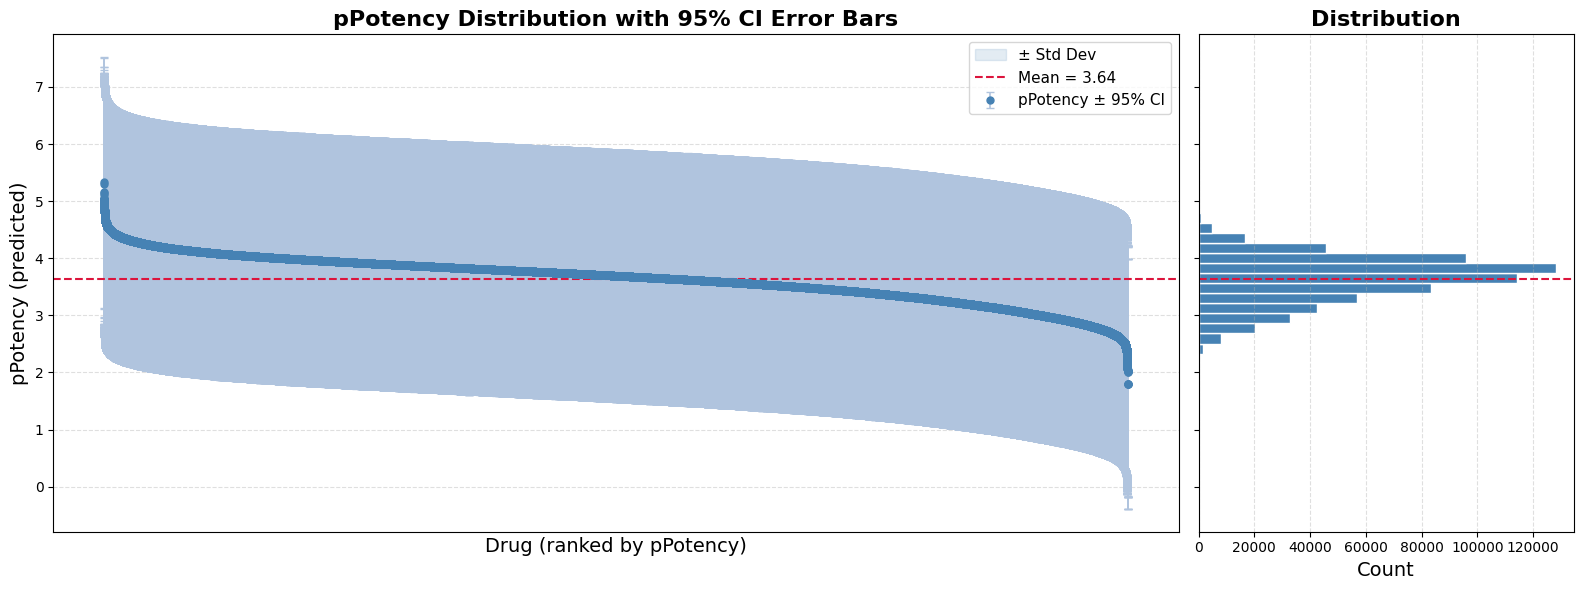

In [187]:
ppotencyDF = BacillusAnthracis_wART_BasidalinPrecursor_predicted_all.sort_values(
    "pPotency_prediction", ascending=False).reset_index(drop=True)

x = np.arange(len(ppotencyDF))
pred = ppotencyDF["pPotency_prediction"]
yerr = np.array([pred - ppotencyDF["pPotency_lower_95CI"],
                 ppotencyDF["pPotency_upper_95CI"] - pred])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6),
                                gridspec_kw={"width_ratios": [3, 1]}, sharey=True)

# ── Scatter + error bars ──────────────────────────────────────────────────────
ax1.errorbar(x, pred, yerr=yerr, fmt='o', color='steelblue', ecolor='lightsteelblue',
             elinewidth=1.2, capsize=3, markersize=5, alpha=1, label="pPotency ± 95% CI")
ax1.fill_between(x, pred - ppotencyDF["pPotency_std"], pred + ppotencyDF["pPotency_std"],
                 alpha=0.15, color='steelblue', label="± Std Dev")
ax1.axhline(pred.mean(),   color='crimson',    linestyle='--', linewidth=1.5, label=f'Mean = {pred.mean():.2f}')
#ax1.axhline(pred.median(), color='darkorange', linestyle=':',  linewidth=1.5, label=f'Median = {pred.median():.2f}')
ax1.set_xlabel("Drug (ranked by pPotency)", fontsize=14)  
ax1.set_ylabel("pPotency (predicted)",      fontsize=14) 
ax1.set_title("pPotency Distribution with 95% CI Error Bars", fontsize=16, fontweight='bold')  
ax1.set_xticks([])
ax1.legend(fontsize=11); ax1.grid(axis='y', linestyle='--', alpha=0.4)

# ── Histogram ─────────────────────────────────────────────────────────────────
ax2.hist(pred, bins=20, orientation='horizontal', color='steelblue', edgecolor='white', alpha=1)
ax2.axhline(pred.mean(),   color='crimson',    linestyle='--', linewidth=1.5)
#ax2.axhline(pred.median(), color='darkorange', linestyle=':',  linewidth=1.5)
ax2.set_xlabel("Count", fontsize=14)        
ax2.set_title("Distribution", fontsize=16, fontweight='bold') 
ax2.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_distribution_BasidalinPrecursor.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_distribution_BasidalinPrecursor.png")
plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### Read predicted `ADMET` properties for all unique SMILES

In [188]:
BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity = pd.read_csv(saveDir + f'{target_organism}_BasidalinPrecursorDORAnetGenerated_Antibiotic_ARTprediction_wToxicity.csv')
# Identify columns that match the string
matched_cols = BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity.filter(like='drugbank_approved_percentile').columns
# Keep everything EXCEPT those columns
BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity = BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity.drop(columns=matched_cols)
max_val = BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity['pPotency_prediction'].max()
min_val = BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity

pPotency_prediction range: 1.800 → 5.331


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang,Clearance_Hepatocyte_AZ,Clearance_Microsome_AZ,Half_Life_Obach,HydrationFreeEnergy_FreeSolv,LD50_Zhu,Lipophilicity_AstraZeneca,PPBR_AZ,Solubility_AqSolDB,VDss_Lombardo
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.331199,1.119903,3.136188,7.526210,0.000005,2.977075e-08,0.000731,507.182,-1.62900,...,-6.532908,10.607536,21.695647,50.300162,-17.205968,1.654107,0.655960,57.025779,-0.437743,-4.687410
1,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,4.428906,1.118935,2.235793,6.622019,0.000037,2.387706e-07,0.005810,785.557,-2.42396,...,-6.475772,-3.364867,23.998967,23.188328,-17.767413,2.572223,0.824762,72.098404,-1.021829,-8.492948
2,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,4.461134,1.118921,2.268049,6.654220,0.000035,2.217075e-07,0.005394,787.573,-1.75026,...,-6.679487,1.394358,30.020669,41.759685,-18.648854,2.694055,1.037456,70.919499,-0.882326,-5.521714
3,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,4.529551,1.118626,2.337043,6.722059,0.000030,1.896448e-07,0.004602,744.417,-2.89890,...,-6.818474,5.750305,18.362396,75.728975,-19.110544,1.835266,0.205004,52.787176,0.022007,-3.040320
4,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,4.886733,1.119159,2.693181,7.080285,0.000013,8.312178e-08,0.002027,745.425,-2.56940,...,-6.744336,16.908523,47.892034,53.422075,-18.034575,2.189310,0.593944,55.243972,-0.186449,-8.067867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210076,CC(=O)N(C[C@H](C)C=C1C=C(O)C(=O)O1)C(=O)CN,3.235006,1.120611,1.038608,5.431404,0.000582,3.703361e-06,0.091494,268.269,-0.16110,...,-4.942543,19.222275,-13.245729,-26.206140,-13.784199,2.038853,-0.782325,56.416938,-1.252166,4.609630
210077,C=C1OC(=O)C(O)=C1C[C@@H](C)CNC(=O)[C@H](C)N,4.017921,1.118431,1.825797,6.210045,0.000096,6.165312e-07,0.014935,254.286,0.35860,...,-4.971337,18.877715,-7.608197,-16.089244,-12.828560,2.241299,-0.052081,47.861599,-0.621900,0.049090
210078,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,3.427273,1.119665,1.232729,5.621817,0.000374,2.388817e-06,0.058515,236.271,-0.15188,...,-4.665920,26.431825,-3.949410,4.130865,-13.637193,2.929543,0.018285,67.610269,-1.883527,4.866808
210079,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,3.531349,1.118973,1.338161,5.724536,0.000294,1.885662e-06,0.045903,254.286,-0.39730,...,-5.117675,22.680652,-22.316851,-11.262022,-13.711330,2.263901,-0.539212,33.198010,-0.924615,-1.704941


## Keep only predictions for `Basidalin` and `Basidalin precursor`

### Read `BasidalinOnly` prediction

In [227]:
BacillusAnthracis_basidalinOnly_wART_wToxicity = pd.read_csv(saveDir + f'{target_organism}_basidalinOnlyDORAnetGenerated_Antibiotic_ARTprediction_wToxicity.csv')

# Canonicalize SMILES
BacillusAnthracis_basidalinOnly_wART_wToxicity["SMILES"] = (
    BacillusAnthracis_basidalinOnly_wART_wToxicity["SMILES"].apply(canon_smiles)
)
BacillusAnthracis_basidalinOnly_wART_wToxicity

,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,NC1=CC(=O)O/C1=C/C=O,3.620342,1.119186,1.426739,5.813946,0.000240,1.534807e-06,0.037434,139.110,-0.53140,...,88.871656,14.579294,29.934083,43.001163,52.966266,40.131834,31.795269,31.795269,81.233036,61.302831
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.331199,1.119903,3.136188,7.526210,0.000005,2.977075e-08,0.000731,507.182,-1.62900,...,5.428461,23.381155,54.633579,87.398216,4.652966,9.112059,36.719659,28.887166,89.414502,9.732454
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,4.428906,1.118935,2.235793,6.622019,0.000037,2.387706e-07,0.005810,785.557,-2.42396,...,5.893757,12.563009,56.688639,69.910818,4.071345,53.392788,39.433889,46.219465,82.939124,2.326483
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,4.461134,1.118921,2.268049,6.654220,0.000035,2.217075e-07,0.005394,787.573,-1.75026,...,4.769290,15.936409,61.962001,83.365646,3.140752,61.186506,42.807290,44.784800,85.071733,7.134548
4,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,4.529551,1.118626,2.337043,6.722059,0.000030,1.896448e-07,0.004602,744.417,-2.89890,...,3.799922,19.542458,50.872431,92.904226,2.869329,13.803800,30.050407,24.505622,92.594029,16.401706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,C/C=C1/OC(=O)C=C1N,3.677768,1.118904,1.484716,5.870820,0.000210,1.346419e-06,0.032755,125.127,0.28960,...,93.873594,12.601784,42.458317,41.372625,69.794494,42.264444,38.968592,39.395114,82.124855,56.882513
92,NC1=CC(=O)O/C1=C/C(O)CO,3.316677,1.120229,1.121028,5.512325,0.000482,3.073796e-06,0.075678,171.152,-1.37710,...,42.225669,15.316014,6.436603,40.442032,14.540520,33.268709,29.817759,19.271035,88.018612,55.913145
93,NC1=CC(=O)OC1=C(CO)CO,3.966990,1.118334,1.775055,6.158926,0.000108,6.935442e-07,0.016786,171.152,-1.37550,...,48.662272,21.907716,8.375339,49.980613,26.056611,22.140364,26.017836,13.532377,90.383870,56.649864
94,NC1=C(CO)C(=O)O/C1=C/CO,3.799071,1.118567,1.606679,5.991463,0.000159,1.019852e-06,0.024735,171.152,-1.37550,...,52.268321,20.938348,7.522295,41.256301,24.117875,32.997286,26.677007,16.750679,90.267546,65.296627


In [239]:
# Canonicalize query SMILES
basidalin = canon_smiles('C1=C(/C(=C\\C=O)/OC1=O)N')
basidalin_precursor = canon_smiles('CCC=C1OC(=O)[C@@H](C)[C@H]1O')
query_set = {basidalin, basidalin_precursor}

df1 = BacillusAnthracis_basidalinOnly_wART_wToxicity.copy()
df2 = BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity.copy()

if "smiles" in df1.columns and "SMILES" not in df1.columns:
    df1 = df1.rename(columns={"smiles": "SMILES"})
if "smiles" in df2.columns and "SMILES" not in df2.columns:
    df2 = df2.rename(columns={"smiles": "SMILES"})

df1["SMILES"] = df1["SMILES"].apply(canon_smiles)
df2["SMILES"] = df2["SMILES"].apply(canon_smiles)

df1_q = df1[df1["SMILES"].isin(query_set)].copy()
df2_q = df2[df2["SMILES"].isin(query_set)].copy()

priority_cols = ["SMILES", "pPotency_prediction", "pPotency_std", "pPotency_lower_95CI", "pPotency_upper_95CI"]
common_cols = [c for c in df1_q.columns if c in df2_q.columns]
ordered_cols = [c for c in priority_cols if c in common_cols]

queryDF = pd.concat([df1_q[ordered_cols], df2_q[ordered_cols]], ignore_index=True)
queryDF = queryDF.drop_duplicates(subset=["SMILES"]).reset_index(drop=True)

# Add drugName based on canonical SMILES
name_map = {basidalin: "Basidalin", basidalin_precursor: "Basidalin Precursor"}
queryDF["drugName"] = queryDF["SMILES"].map(name_map)

# Put drugName first
queryDF = queryDF[["drugName"] + [c for c in queryDF.columns if c != "drugName"]]

queryDF

,drugName,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI
0,Basidalin,NC1=CC(=O)O/C1=C/C=O,3.620342,1.119186,1.426739,5.813946
1,Basidalin Precursor,CCC=C1OC(=O)[C@@H](C)[C@H]1O,3.332529,1.119723,1.137871,5.527187


In [241]:
combinedQueryDF = pd.concat([queryDF, Anthrax_FDAapproved_wPotency], ignore_index=True)
# remove duplicate SMILES (keep first occurrence)
combinedQueryDF = combinedQueryDF.drop_duplicates(subset=["SMILES"]).reset_index(drop=True)
# Fill missing pPotency_prediction from pPotency, then drop pPotency
combinedQueryDF["pPotency_prediction"] = combinedQueryDF["pPotency_prediction"].fillna(combinedQueryDF["pPotency"])
combinedQueryDF = combinedQueryDF.drop(columns=["pPotency", "MIC90_mg_L", "MIC90_M"])
combinedQueryDF

,drugName,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI
0,Basidalin,NC1=CC(=O)O/C1=C/C=O,3.620342,1.119186,1.426739,5.813946
1,Basidalin Precursor,CCC=C1OC(=O)[C@@H](C)[C@H]1O,3.332529,1.119723,1.137871,5.527187
2,Ciprofloxacin,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,6.742132,NaN,NaN,NaN
3,Doxycycline,C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...,7.170692,NaN,NaN,NaN
4,Levofloxacin,C[C@H]1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)...,6.478774,NaN,NaN,NaN


### Compute their ADMET profile

In [244]:
model = ADMETModel()
pred = model.predict(smiles=combinedQueryDF["SMILES"].dropna().astype(str).tolist())
pred = pred if isinstance(pred, pd.DataFrame) else pd.DataFrame(pred)
pred = pred.reset_index().rename(columns={"index": "SMILES"}) if "SMILES" not in pred.columns else pred
combinedQueryDF_wADMET = combinedQueryDF.merge(pred, on="SMILES", how="left")
combinedQueryDF_wADMET

Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".
Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.b

,drugName,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,molecular_weight,logP,hydrogen_bond_acceptors,hydrogen_bond_donors,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,Basidalin,NC1=CC(=O)O/C1=C/C=O,3.620342,1.119186,1.426739,5.813946,139.110,-0.5314,4,1,...,88.871656,14.579294,29.934083,43.001163,52.966266,40.131834,31.795269,31.795269,81.233036,61.302831
1,Basidalin Precursor,CCC=C1OC(=O)[C@@H](C)[C@H]1O,3.332529,1.119723,1.137871,5.527187,156.181,0.8341,3,1,...,94.416440,56.378441,25.009694,39.433889,50.833656,21.868941,35.595192,23.381155,86.894145,63.900737
2,Ciprofloxacin,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,6.742132,NaN,NaN,NaN,331.347,1.5833,5,2,...,58.045754,16.944552,14.928267,49.515316,21.364870,44.862350,13.920124,15.005816,38.386972,48.778596
3,Doxycycline,C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...,7.170692,NaN,NaN,NaN,444.440,-0.3476,9,6,...,6.669252,59.906941,69.174098,16.091508,15.626212,50.911206,29.895308,29.081039,50.562233,63.978286
4,Levofloxacin,C[C@H]1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)...,6.478774,NaN,NaN,NaN,361.373,1.5440,6,1,...,81.271811,18.069019,15.354789,48.507173,32.803412,26.172935,18.185343,21.093447,59.480419,83.675843


In [259]:
refDrugbankDF = drugBankDrug_FDAapproved_antibiotic_wART_wADMET.copy()
generatedCandidateDF = BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity.copy()
queryCandidateDF = combinedQueryDF_wADMET.copy()

print("Drugbank reference dataframe shape:", refDrugbankDF.shape)
print("Generated candidate dataframe shape:", generatedCandidateDF.shape)
print("Combined query dataframe shape:", queryCandidateDF.shape)

Drugbank reference dataframe shape: (132, 44)
Generated candidate dataframe shape: (210081, 57)
Combined query dataframe shape: (5, 104)


In [261]:
# ============================================================
# pPotency vs Toxicity plot
# Reference only: refDrugbankDF
# Plotted datasets: generatedCandidateDF + queryCandidateDF
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Input data
# ------------------------------------------------------------
refDrugbankDF = drugBankDrug_FDAapproved_antibiotic_wART_wADMET.copy()
generatedCandidateDF = BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity.copy()
queryCandidateDF = combinedQueryDF_wADMET.copy()

print("Drugbank reference dataframe shape:", refDrugbankDF.shape)
print("Generated candidate dataframe shape:", generatedCandidateDF.shape)
print("Combined query dataframe shape:", queryCandidateDF.shape)

# ------------------------------------------------------------
# 2. Basic harmonization
# ------------------------------------------------------------
def prepareDF(DF, datasetLabel):
    DF = DF.copy()

    if "smiles" in DF.columns and "SMILES" not in DF.columns:
        DF = DF.rename(columns={"smiles": "SMILES"})

    if "drugName" not in DF.columns:
        DF["drugName"] = DF["SMILES"]

    DF["datasetLabel"] = datasetLabel
    return DF

refDrugbankDF = prepareDF(refDrugbankDF, "Reference")
generatedCandidateDF = prepareDF(generatedCandidateDF, "Generated")
queryCandidateDF = prepareDF(queryCandidateDF, "Query")

# ------------------------------------------------------------
# 3. Keep only the columns needed for pPotency–toxicity scoring
# ------------------------------------------------------------
potencyCols = [
    "pPotency_prediction",
    "pPotency_std",
    "pPotency_lower_95CI",
    "pPotency_upper_95CI",
]

toxicityMeta = [
    ("AMES", "lowerBetter"),
    ("Carcinogens_Lagunin", "lowerBetter"),
    ("ClinTox", "lowerBetter"),
    ("DILI", "lowerBetter"),
    ("Skin_Reaction", "lowerBetter"),
    ("hERG", "lowerBetter"),
    ("LD50_Zhu", "higherBetter"),
    ("NR-AR-LBD", "lowerBetter"),
    ("NR-AR", "lowerBetter"),
    ("NR-AhR", "lowerBetter"),
    ("NR-Aromatase", "lowerBetter"),
    ("NR-ER-LBD", "lowerBetter"),
    ("NR-ER", "lowerBetter"),
    ("NR-PPAR-gamma", "lowerBetter"),
    ("SR-ARE", "lowerBetter"),
    ("SR-ATAD5", "lowerBetter"),
    ("SR-HSE", "lowerBetter"),
    ("SR-MMP", "lowerBetter"),
    ("SR-p53", "lowerBetter"),
]

toxicityCols = [endpoint for endpoint, _ in toxicityMeta]
keepCols = ["drugName", "SMILES"] + potencyCols + toxicityCols

def ensureCols(DF, colList):
    DF = DF.copy()
    for colName in colList:
        if colName not in DF.columns:
            DF[colName] = np.nan
    return DF[colList].copy()

refScoreDF = ensureCols(refDrugbankDF, keepCols)
candScoreDF = ensureCols(generatedCandidateDF, keepCols)
queryScoreDF = ensureCols(queryCandidateDF, keepCols)

for colName in potencyCols + toxicityCols:
    refScoreDF[colName] = pd.to_numeric(refScoreDF[colName], errors="coerce")
    candScoreDF[colName] = pd.to_numeric(candScoreDF[colName], errors="coerce")
    queryScoreDF[colName] = pd.to_numeric(queryScoreDF[colName], errors="coerce")

# ------------------------------------------------------------
# 4. Build endpoint weights from refDrugbankDF only
# ------------------------------------------------------------
def robustIQR(series):
    cleanSeries = pd.to_numeric(series, errors="coerce").dropna()
    if len(cleanSeries) < 5:
        return np.nan
    q25, q75 = np.percentile(cleanSeries, [25, 75])
    return q75 - q25

refToxDF = refScoreDF[toxicityCols].apply(pd.to_numeric, errors="coerce")
toxCorrDF = refToxDF.corr().abs()

weightRows = []
for endpointName, directionName in toxicityMeta:
    iqrValue = robustIQR(refToxDF[endpointName])
    informativeness = 1.0 / (iqrValue + 1e-6) if pd.notna(iqrValue) else 1.0

    otherEndpoints = [x for x in toxicityCols if x != endpointName]
    if endpointName in toxCorrDF.index and len(otherEndpoints) > 0:
        meanAbsCorr = toxCorrDF.loc[endpointName, otherEndpoints].dropna().mean()
    else:
        meanAbsCorr = np.nan

    uniqueness = max(1.0 - meanAbsCorr, 1e-3) if pd.notna(meanAbsCorr) else 1.0

    weightRows.append({
        "endpoint": endpointName,
        "direction": directionName,
        "rawWeight": informativeness * uniqueness,
    })

toxWeightDF = pd.DataFrame(weightRows)
toxWeightDF["finalWeight"] = toxWeightDF["rawWeight"] / toxWeightDF["rawWeight"].sum()

# ------------------------------------------------------------
# 5. Reference-based desirability functions
# ------------------------------------------------------------
def getSortedRefArray(series):
    refArray = pd.to_numeric(series, errors="coerce").dropna().to_numpy(dtype=float)
    refArray = refArray[np.isfinite(refArray)]
    return np.sort(refArray)

def higherBetterDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    finiteMask = np.isfinite(valueArray)
    percentileArray = np.searchsorted(refArray, valueArray[finiteMask], side="right") / len(refArray)
    outArray[finiteMask] = np.clip(percentileArray, 0.0, 1.0)
    return pd.Series(outArray, index=valueSeries.index)

def lowerBetterDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    finiteMask = np.isfinite(valueArray)
    percentileArray = np.searchsorted(refArray, valueArray[finiteMask], side="right") / len(refArray)
    outArray[finiteMask] = np.clip(1.0 - percentileArray, 0.0, 1.0)
    return pd.Series(outArray, index=valueSeries.index)

def weightedGeoMeanSeries(DF, valueColList, weightSeries):
    valueMatrix = DF[valueColList].to_numpy(dtype=float)
    weightArray = np.asarray(weightSeries, dtype=float)
    outArray = np.full(valueMatrix.shape[0], np.nan)

    for rowIdx in range(valueMatrix.shape[0]):
        rowArray = valueMatrix[rowIdx]
        finiteMask = np.isfinite(rowArray)

        if finiteMask.sum() == 0:
            continue

        rowValues = np.clip(rowArray[finiteMask], 1e-6, 1.0)
        rowWeights = weightArray[finiteMask]
        outArray[rowIdx] = np.exp(np.sum(rowWeights * np.log(rowValues)) / np.sum(rowWeights))

    return pd.Series(outArray, index=DF.index)

# ------------------------------------------------------------
# 6. Score generatedCandidateDF and queryCandidateDF
#    relative to refDrugbankDF
# ------------------------------------------------------------
for endpointName, directionName in toxicityMeta:
    desCol = f"{endpointName}_des"

    if directionName == "higherBetter":
        candScoreDF[desCol] = higherBetterDes(refScoreDF[endpointName], candScoreDF[endpointName])
        queryScoreDF[desCol] = higherBetterDes(refScoreDF[endpointName], queryScoreDF[endpointName])
    else:
        candScoreDF[desCol] = lowerBetterDes(refScoreDF[endpointName], candScoreDF[endpointName])
        queryScoreDF[desCol] = lowerBetterDes(refScoreDF[endpointName], queryScoreDF[endpointName])

candScoreDF["PotencyDesRaw"] = higherBetterDes(refScoreDF["pPotency_prediction"], candScoreDF["pPotency_prediction"])
queryScoreDF["PotencyDesRaw"] = higherBetterDes(refScoreDF["pPotency_prediction"], queryScoreDF["pPotency_prediction"])

toxDesCols = [f"{endpointName}_des" for endpointName, _ in toxicityMeta]

candScoreDF["ToxicitySafety"] = weightedGeoMeanSeries(
    candScoreDF, toxDesCols, toxWeightDF["finalWeight"]
)
queryScoreDF["ToxicitySafety"] = weightedGeoMeanSeries(
    queryScoreDF, toxDesCols, toxWeightDF["finalWeight"]
)

candScoreDF["coreToxicityScore"] = 1.0 - candScoreDF["ToxicitySafety"]
queryScoreDF["coreToxicityScore"] = 1.0 - queryScoreDF["ToxicitySafety"]

# ------------------------------------------------------------
# 7. Keep your original top-20 selection on generated candidates
# ------------------------------------------------------------
cand2DDF = candScoreDF.dropna(
    subset=["pPotency_prediction", "coreToxicityScore", "ToxicitySafety", "PotencyDesRaw"]
).copy()

xCutoff2D = cand2DDF["pPotency_prediction"].quantile(0.75)
yCutoff2D = cand2DDF["coreToxicityScore"].quantile(0.25)

optimal2DDF = cand2DDF[
    (cand2DDF["pPotency_prediction"] >= xCutoff2D) &
    (cand2DDF["coreToxicityScore"] <= yCutoff2D)
].copy()

optimal2DDF["OverallPriority2D"] = np.sqrt(
    optimal2DDF["PotencyDesRaw"] * optimal2DDF["ToxicitySafety"]
)

top20_2D_DF = optimal2DDF.sort_values(
    by=["OverallPriority2D", "pPotency_prediction", "coreToxicityScore"],
    ascending=[False, False, True]
).head(20).copy()

Drugbank reference dataframe shape: (132, 44)
Generated candidate dataframe shape: (210081, 57)
Combined query dataframe shape: (5, 104)


Generated candidates used for analysis: 210081
Generated candidates shown in blue cloud: 107044

Query compounds that will be plotted:
              drugName  pPotency_prediction  coreToxicityScore
0            Basidalin             3.620342           0.999208
1  Basidalin Precursor             3.332529           0.584901
2        Ciprofloxacin             6.742132           0.656992
3          Doxycycline             7.170692           0.635314
4         Levofloxacin             6.478774           0.648965


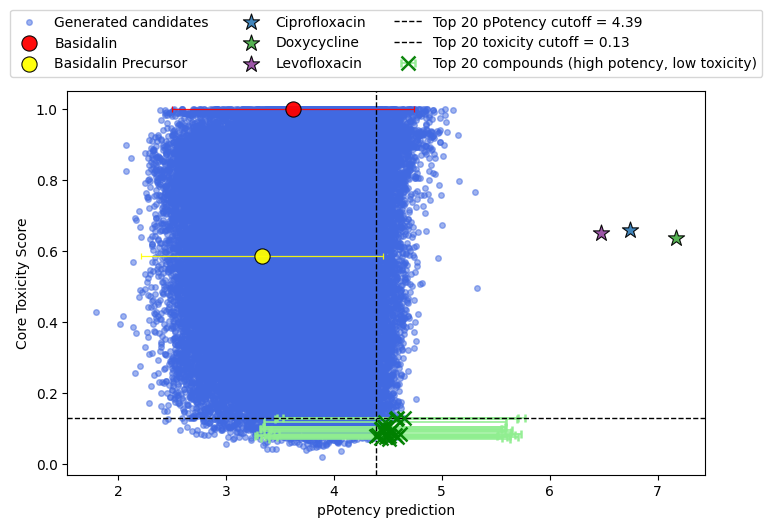

In [291]:
# ------------------------------------------------------------
# 8. Plot generated candidates + query candidates
# ------------------------------------------------------------
xDisplay = top20_2D_DF["pPotency_prediction"].min() if len(top20_2D_DF) else xCutoff2D
yDisplay = top20_2D_DF["coreToxicityScore"].max() if len(top20_2D_DF) else yCutoff2D

fig, ax = plt.subplots(figsize=(8, 6))

# ------------------------------------------------------------
# Display-only thinning for generated candidates
# This does NOT affect scoring, cutoffs, or top-20 selection.
# It only reduces overplotting in dense local neighborhoods.
# ------------------------------------------------------------
def thinForDisplay(DF, xCol, yCol, nXBins=70, nYBins=70, denseThreshold=8, keepFraction=0.5, randomState=42):
    plotDF = DF[[xCol, yCol]].dropna().copy()

    xMin, xMax = plotDF[xCol].min(), plotDF[xCol].max()
    yMin, yMax = plotDF[yCol].min(), plotDF[yCol].max()

    if xMin == xMax:
        xMax = xMin + 1e-9
    if yMin == yMax:
        yMax = yMin + 1e-9

    xEdges = np.linspace(xMin, xMax, nXBins + 1)
    yEdges = np.linspace(yMin, yMax, nYBins + 1)

    plotDF["xBin"] = pd.cut(plotDF[xCol], bins=xEdges, labels=False, include_lowest=True)
    plotDF["yBin"] = pd.cut(plotDF[yCol], bins=yEdges, labels=False, include_lowest=True)

    rng = np.random.default_rng(randomState)
    keptIndex = []

    for _, groupDF in plotDF.groupby(["xBin", "yBin"], dropna=False):
        nGroup = len(groupDF)

        if nGroup <= denseThreshold:
            keptIndex.extend(groupDF.index.tolist())
        else:
            nKeep = max(1, int(np.ceil(nGroup * keepFraction)))
            chosen = rng.choice(groupDF.index.to_numpy(), size=nKeep, replace=False)
            keptIndex.extend(chosen.tolist())

    return DF.loc[sorted(set(keptIndex))].copy()

# Use full cand2DDF for all calculations, but a thinned copy for display only
candPlotDF = thinForDisplay(
    cand2DDF,
    xCol="pPotency_prediction",
    yCol="coreToxicityScore",
    nXBins=70,
    nYBins=70,
    denseThreshold=8,
    keepFraction=0.5,
    randomState=42
)

print(f"Generated candidates used for analysis: {len(cand2DDF)}")
print(f"Generated candidates shown in blue cloud: {len(candPlotDF)}")

# Generated candidates: same style, but plotted from thinned display copy
ax.scatter(
    candPlotDF["pPotency_prediction"],
    candPlotDF["coreToxicityScore"],
    s=16,
    alpha=0.5,
    color="royalblue",
    label="Generated candidates"
)

# ------------------------------------------------------------
# Query compounds:
#   first compound  -> red circle
#   second compound -> yellow circle
#   remaining       -> star markers with distinct colors
# ------------------------------------------------------------
queryPlotDF = queryScoreDF.dropna(
    subset=["drugName", "pPotency_prediction", "coreToxicityScore"]
).drop_duplicates(subset=["drugName", "SMILES"]).copy()

print("\nQuery compounds that will be plotted:")
print(queryPlotDF[["drugName", "pPotency_prediction", "coreToxicityScore"]])

remainingColors = [
    "#377EB8",  # blue
    "#4DAF4A",  # green
    "#984EA3",  # purple
    "#FF7F00",  # orange
    "#A65628",  # brown
    "#66C2A5",  # teal
    "#F781BF",  # pink
]

for i, (_, rowDF) in enumerate(queryPlotDF.iterrows()):
    if i == 0:
        marker = "o"
        color = "red"
        markerSize = 120
    elif i == 1:
        marker = "o"
        color = "yellow"
        markerSize = 120
    else:
        marker = "*"
        color = remainingColors[(i - 2) % len(remainingColors)]
        markerSize = 150

    ax.scatter(
        rowDF["pPotency_prediction"],
        rowDF["coreToxicityScore"],
        marker=marker,
        s=markerSize,
        color=color,
        edgecolors="black",
        linewidths=0.8,
        alpha=0.95,
        label=rowDF["drugName"],
        zorder=5
    )

    if pd.notna(rowDF["pPotency_std"]):
        ax.errorbar(
            rowDF["pPotency_prediction"],
            rowDF["coreToxicityScore"],
            xerr=float(rowDF["pPotency_std"]),
            fmt="none",
            ecolor=color,
            elinewidth=0.9,
            capsize=2,
            capthick=0.9,
            alpha=0.9,
            zorder=4
        )

# Top 20 generated compounds: keep same style
ax.errorbar(
    top20_2D_DF["pPotency_prediction"],
    top20_2D_DF["coreToxicityScore"],
    xerr=pd.to_numeric(top20_2D_DF["pPotency_std"], errors="coerce").fillna(0.0).values,
    fmt="x",
    color="green",
    ecolor="lightgreen",
    elinewidth=1.2,
    capsize=3,
    capthick=1.2,
    markersize=10,
    markeredgewidth=1.8,
    alpha=0.95,
    label="Top 20 compounds (high potency, low toxicity)"
)

# Same cutoff lines as your original style
ax.axvline(
    xDisplay,
    linestyle="--",
    linewidth=1.0,
    color="k",
    label=f"Top 20 pPotency cutoff = {xDisplay:.2f}"
)

ax.axhline(
    yDisplay,
    linestyle="--",
    linewidth=1.0,
    color="k",
    label=f"Top 20 toxicity cutoff = {yDisplay:.2f}"
)

ax.set_xlabel("pPotency prediction")
ax.set_ylabel("Core Toxicity Score")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.90])

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_queryCandidate.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_queryCandidate.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

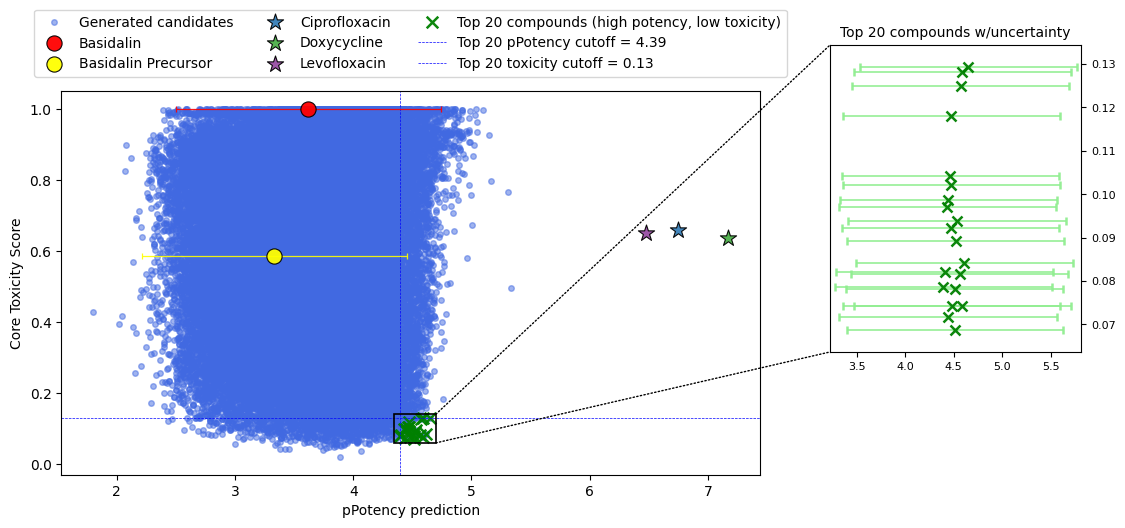

In [305]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import ConnectionPatch
import matplotlib.patches as patches

# ------------------------------------------------------------
# 8. Plot generated candidates + query candidates
# ------------------------------------------------------------
xDisplay = top20_2D_DF["pPotency_prediction"].min() if len(top20_2D_DF) else xCutoff2D
yDisplay = top20_2D_DF["coreToxicityScore"].max() if len(top20_2D_DF) else yCutoff2D

fig, ax = plt.subplots(figsize=(10, 6))

def thinForDisplay(DF, xCol, yCol, nXBins=70, nYBins=70, denseThreshold=8, keepFraction=0.5, randomState=42):
    plotDF = DF[[xCol, yCol]].dropna().copy()
    xMin, xMax = plotDF[xCol].min(), plotDF[xCol].max()
    yMin, yMax = plotDF[yCol].min(), plotDF[yCol].max()
    if xMin == xMax: xMax = xMin + 1e-9
    if yMin == yMax: yMax = yMin + 1e-9
    xEdges = np.linspace(xMin, xMax, nXBins + 1)
    yEdges = np.linspace(yMin, yMax, nYBins + 1)
    plotDF["xBin"] = pd.cut(plotDF[xCol], bins=xEdges, labels=False, include_lowest=True)
    plotDF["yBin"] = pd.cut(plotDF[yCol], bins=yEdges, labels=False, include_lowest=True)
    rng, keptIndex = np.random.default_rng(randomState), []
    for _, g in plotDF.groupby(["xBin", "yBin"], dropna=False):
        n = len(g)
        if n <= denseThreshold: keptIndex.extend(g.index.tolist())
        else:
            k = max(1, int(np.ceil(n * keepFraction)))
            keptIndex.extend(rng.choice(g.index.to_numpy(), size=k, replace=False).tolist())
    return DF.loc[sorted(set(keptIndex))].copy()

candPlotDF = thinForDisplay(cand2DDF, "pPotency_prediction", "coreToxicityScore")

ax.scatter(candPlotDF["pPotency_prediction"], candPlotDF["coreToxicityScore"],
           s=16, alpha=0.5, color="royalblue", label="Generated candidates")

queryPlotDF = queryScoreDF.dropna(
    subset=["drugName", "pPotency_prediction", "coreToxicityScore"]
).drop_duplicates(subset=["drugName", "SMILES"]).copy()

remainingColors = ["#377EB8", "#4DAF4A", "#984EA3", "#FF7F00", "#A65628", "#66C2A5", "#F781BF"]
for i, (_, r) in enumerate(queryPlotDF.iterrows()):
    marker, color, size = ("o", "red", 120) if i == 0 else (("o", "yellow", 120) if i == 1 else ("*", remainingColors[(i-2) % len(remainingColors)], 150))
    ax.scatter(r["pPotency_prediction"], r["coreToxicityScore"], marker=marker, s=size, color=color,
               edgecolors="black", linewidths=0.8, alpha=0.95, label=r["drugName"], zorder=5)
    if pd.notna(r.get("pPotency_std", np.nan)):
        ax.errorbar(r["pPotency_prediction"], r["coreToxicityScore"], xerr=float(r["pPotency_std"]),
                    fmt="none", ecolor=color, elinewidth=0.9, capsize=2, capthick=0.9, alpha=0.9, zorder=4)

ax.scatter(
    top20_2D_DF["pPotency_prediction"],
    top20_2D_DF["coreToxicityScore"],
    marker="x", s=70, linewidths=1.8, alpha=0.95, color="green",
    label="Top 20 compounds (high potency, low toxicity)"
)

ax.axvline(xDisplay, linestyle="--", linewidth=0.5, color="b", label=f"Top 20 pPotency cutoff = {xDisplay:.2f}")
ax.axhline(yDisplay, linestyle="--", linewidth=0.5, color="b", label=f"Top 20 toxicity cutoff = {yDisplay:.2f}")

ax.set_xlabel("pPotency prediction")
ax.set_ylabel("Core Toxicity Score")

# ---------- small box on main ----------
bx1 = top20_2D_DF["pPotency_prediction"].min() - 0.05
bx2 = top20_2D_DF["pPotency_prediction"].max() + 0.05
by1 = top20_2D_DF["coreToxicityScore"].min() - 0.01
by2 = top20_2D_DF["coreToxicityScore"].max() + 0.01
ax.add_patch(patches.Rectangle((bx1, by1), bx2 - bx1, by2 - by1, fill=False, ec="k", lw=1.2, ls="-", zorder=6))

# ---------- inset (bigger; includes full error bars) ----------
x1 = (top20_2D_DF["pPotency_prediction"] - top20_2D_DF["pPotency_std"]).min() - 0.05
x2 = (top20_2D_DF["pPotency_prediction"] + top20_2D_DF["pPotency_std"]).max() + 0.05
y1 = top20_2D_DF["coreToxicityScore"].min() - 0.005
y2 = top20_2D_DF["coreToxicityScore"].max() + 0.005

axins = inset_axes(ax, width="36%", height="80%", loc="lower left",
                   bbox_to_anchor=(1.1, 0.32, 1, 1), bbox_transform=ax.transAxes, borderpad=0)

axins.errorbar(top20_2D_DF["pPotency_prediction"], top20_2D_DF["coreToxicityScore"],
               xerr=top20_2D_DF["pPotency_std"].values, fmt="x", color="green", ecolor="lightgreen",
               elinewidth=1.2, capsize=3, capthick=1.2, markersize=7, markeredgewidth=1.8, alpha=0.95)

axins.set_xlim(x1, x2); axins.set_ylim(y1, y2)
axins.set_title("Top 20 compounds w/uncertainty", fontsize=10)
axins.tick_params(labelsize=8)
axins.yaxis.tick_right(); axins.yaxis.set_label_position("right")

# ---------- connectors ----------
fig.add_artist(ConnectionPatch(
    xyA=(bx2, by2), coordsA=ax.transData,
    xyB=(x1, y2), coordsB=axins.transData,
    color="k", lw=1.0, linestyle=":"))

fig.add_artist(ConnectionPatch(
    xyA=(bx2, by1), coordsA=ax.transData,
    xyB=(x1, y1), coordsB=axins.transData,
    color="k", lw=1.0, linestyle=":"))

ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=True)
plt.tight_layout(rect=[0, 0, 0.78, 0.90])

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_queryCandidate.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_queryCandidate.png")
plt.savefig(svg_path, format="svg", dpi=600, bbox_inches="tight")
plt.savefig(png_path, format="png", dpi=600, bbox_inches="tight")
plt.show()

### 15. Plot: `high pPotency`, `low Toxicity Score`, `high ADME feasibility`

Selection rule:
- pPotency in the top quartile
- Toxicity Score in the bottom quartile
- ADMEFeasibility in the top quartile

Within that region, ranking uses the unweighted geometric mean of:
- `PotencyDesRaw`
- `ToxicitySafety`
- `ADMEFeasibility`

In [ ]:
cand3DDF = candScoreDF.copy()

cand3DDF = cand3DDF[
    cand3DDF[["pPotency_prediction", "coreToxicityScore", "ADMEFeasibility", "ToxicitySafety", "PotencyDesRaw"]]
    .notna()
    .all(axis=1)
].copy()

xCutoff3D = cand3DDF["pPotency_prediction"].quantile(0.75)
yCutoff3D = cand3DDF["coreToxicityScore"].quantile(0.25)
zCutoff3D = cand3DDF["ADMEFeasibility"].quantile(0.75)

optimal3DDF = cand3DDF[
    (cand3DDF["pPotency_prediction"] >= xCutoff3D) &
    (cand3DDF["coreToxicityScore"] <= yCutoff3D) &
    (cand3DDF["ADMEFeasibility"] >= zCutoff3D)
].copy()

optimal3DDF["OverallPriority3D"] = (
    optimal3DDF["PotencyDesRaw"] *
    optimal3DDF["ToxicitySafety"] *
    optimal3DDF["ADMEFeasibility"]
) ** (1 / 3)

top20_3D_DF = optimal3DDF.sort_values(
    by=["OverallPriority3D", "pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"],
    ascending=[False, False, True, False]
).head(20).copy()

top20_3D_DF["Top20Rank_3D"] = np.arange(1, len(top20_3D_DF) + 1)

top20_3D_DF[
    [
        "Top20Rank_3D",
        "SMILES",
        "pPotency_prediction",
        "pPotency_std",
        "pPotency_lower_95CI",
        "coreToxicityScore",
        "ADMEFeasibility",
        "ToxicitySafety",
        "OverallPriority3D",
        "QED",
    ]
]

### 16. plot: pPotency vs Toxicity Score vs ADME feasibility

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(13, 10))
ax  = fig.add_subplot(111, projection="3d")

fig.patch.set_alpha(0.0)
ax.set_facecolor((0, 0, 0, 0))

for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
    pane.fill = False
    pane.set_edgecolor("lightgray")
    pane.set_alpha(0.0)

ax.grid(False)
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"]["linewidth"] = 0
    axis.label.set_color("k")
    axis.set_tick_params(colors="k")

ax.scatter(
    cand3DDF["pPotency_prediction"], cand3DDF["coreToxicityScore"], cand3DDF["ADMEFeasibility"],
    s=14, alpha=0.5, color="royalblue", label="Generated candidates", depthshade=False,
)
ax.scatter(
    refScoreDF["pPotency_prediction"], refScoreDF["coreToxicityScore"], refScoreDF["ADMEFeasibility"],
    marker="*", s=100, alpha=1.0, color="red", label="FDA-approved antibiotics", depthshade=False,
)
ax.scatter(
    top20_3D_DF["pPotency_prediction"], top20_3D_DF["coreToxicityScore"], top20_3D_DF["ADMEFeasibility"],
    marker="x", s=120, linewidths=2.5, alpha=1.0, color="green", label="Top 20 compounds", depthshade=False,
)

xCutoff = top20_3D_DF["pPotency_prediction"].min()
yCutoff = top20_3D_DF["coreToxicityScore"].max()
zCutoff = top20_3D_DF["ADMEFeasibility"].min()

xMin, xMax = ax.get_xlim()
yMin, yMax = ax.get_ylim()
zMin, zMax = ax.get_zlim()

#cutoffStyle = dict(linewidth=1.8, linestyle="--", alpha=0.85)
#ax.plot([xMin,    xCutoff], [yCutoff, yCutoff], [zCutoff, zCutoff], color="green",     label=f"pPotency cutoff = {xCutoff:.2f}", **cutoffStyle)
#ax.plot([xCutoff, xCutoff], [yCutoff, yMax],    [zCutoff, zCutoff], color="darkolivegreen", label=f"Toxicity cutoff = {yCutoff:.2f}", **cutoffStyle)
#ax.plot([xCutoff, xCutoff], [yCutoff, yCutoff], [zMin,    zCutoff], color="seagreen",  label=f"ADME cutoff = {zCutoff:.2f}",    **cutoffStyle)
#ax.scatter([xCutoff], [yCutoff], [zCutoff], marker="D", s=180, color="gold", edgecolors="darkorange", linewidths=1.5, zorder=10, label="Optimal cutoff corner", depthshade=False)

ax.set_xlabel("pPotency prediction", labelpad=10, color="k", fontsize=11)
ax.set_ylabel("Toxicity Score", labelpad=10, color="k", fontsize=11)
ax.set_zlabel("ADME feasibility",    labelpad=10, color="k", fontsize=11)
ax.set_zlabel("")
ax.text2D(-0.02, 0.5, "ADME feasibility", transform=ax.transAxes, fontsize=11, color="k", rotation=90, va="center", ha="center")

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.set_tick_params(colors="k", labelsize=10)

ax.view_init(elev=22, azim=45)
ax.legend(loc="upper left", bbox_to_anchor=(0.25, 0.85), ncol=2, frameon=True, framealpha=0.3, facecolor="white", edgecolor="darkgray", labelcolor="black", fontsize=9)
fig.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.05)

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_3d_BasidalinPrecursor.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_3d_BasidalinPrecursor.png")
plt.savefig(svg_path, format="svg", dpi=600, transparent=True, pad_inches=0.5)
plt.savefig(png_path, format="png", dpi=600, transparent=True, pad_inches=0.5)
plt.show()

### 17. Custom projected 3D plot for presentation

This is a presentation-oriented 2D projection of 3 variables.

Projected axes:
- horizontal right = `pPotency`
- vertical up = `Toxicity Score`
- diagonal lower-left = `ADME feasibility`

In [ ]:
xCol, yCol, zCol = "pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"
cols = [xCol, yCol, zCol]

allPlotDF = cand3DDF[cols][np.isfinite(cand3DDF[cols]).all(axis=1)].copy()
refPlotDF = refScoreDF[cols][np.isfinite(refScoreDF[cols]).all(axis=1)].copy()
topPlotDF = top20_3D_DF[cols][np.isfinite(top20_3D_DF[cols]).all(axis=1)].copy()

def paddedRange(arr, frac=0.05):
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    pad = (hi - lo) * frac if (hi - lo) > 0 else 1.0
    return lo - pad, hi + pad

combined          = pd.concat([allPlotDF, refPlotDF, topPlotDF])
(X_MIN, X_MAX), (Y_MIN, Y_MAX), (Z_MIN, Z_MAX) = [paddedRange(combined[c]) for c in cols]

O  = np.zeros(2)
UX = np.array([1.0, 0.0])
UY = np.array([0.0, 1.0])
UZ = np.array([math.cos(math.radians(225)), math.sin(math.radians(225))])

def project(x, y, z):
    return O + ((x-X_MIN)/(X_MAX-X_MIN))*UX + ((y-Y_MIN)/(Y_MAX-Y_MIN))*UY + ((z-Z_MIN)/(Z_MAX-Z_MIN))*UZ

def projectDF(df):
    pts = np.array([project(r[xCol], r[yCol], r[zCol]) for _, r in df.iterrows()])
    return pts[:, 0], pts[:, 1]

allCX, allCY = projectDF(allPlotDF)
refCX, refCY = projectDF(refPlotDF)
topCX, topCY = projectDF(topPlotDF)

TIP_X, TIP_Y, TIP_Z = O + UX, O + UY, O + UZ

fig, ax = plt.subplots(figsize=(12, 11), facecolor="white")
ax.set(facecolor="white", aspect="equal")
ax.axis("off")

for tip in [TIP_X, TIP_Y, TIP_Z]:
    ax.annotate("", xy=tip, xytext=O, zorder=5,
                arrowprops=dict(arrowstyle="-|>", color="black", lw=2.2, mutation_scale=18))

ax.scatter(*O, s=70, c="black", zorder=6)

def drawTicks(unitVec, valMin, valMax, offset, nTicks=5, fmt="{:.2f}"):
    perp = np.array([unitVec[1], -unitVec[0]])
    perp /= np.linalg.norm(perp)
    for i in range(nTicks + 1):
        t, pos = i / nTicks, O + (i / nTicks) * unitVec
        ax.plot(*zip(pos - 0.012*perp, pos + 0.012*perp), color="black", lw=1.0, zorder=5)
        ax.text(*(pos + offset), fmt.format(valMin + t*(valMax-valMin)), fontsize=9, ha="center", va="center")

drawTicks(UX, X_MIN, X_MAX, np.array([ 0.00, -0.05]), fmt="{:.1f}")
drawTicks(UY, Y_MIN, Y_MAX, np.array([-0.06,  0.00]))
drawTicks(UZ, Z_MIN, Z_MAX, np.array([-0.05, -0.03]))

ax.scatter(allCX, allCY, color="royalblue", s=14,  alpha=0.5,  edgecolors="none", zorder=2)
ax.scatter(refCX, refCY, color="red",       s=180, alpha=0.95, marker="*", edgecolors="darkred", linewidths=0.5, zorder=4)
ax.scatter(topCX, topCY, color="green",     s=70,  alpha=0.95, marker="x", linewidths=1.8, zorder=5)

xCut, yCut, zCut = topPlotDF[xCol].min(), topPlotDF[yCol].max(), topPlotDF[zCol].min()
tickLen = 0.02

UZ_perp = np.array([-UZ[1], UZ[0]]) 
UZ_perp /= np.linalg.norm(UZ_perp)           
zPt = O + ((zCut-Z_MIN)/(Z_MAX-Z_MIN))*UZ 

for pt, color, dx, dy in [
    (O + ((xCut-X_MIN)/(X_MAX-X_MIN))*UX, "green", 0, tickLen),
    (O + ((yCut-Y_MIN)/(Y_MAX-Y_MIN))*UY, "darkgreen",  tickLen, 0),
]:
    ax.plot([pt[0]-dx, pt[0]+dx], [pt[1]-dy, pt[1]+dy], color=color, lw=1.5, zorder=5)

# Z cutoff tick perpendicular to UZ
ax.plot(
    [zPt[0] - tickLen*UZ_perp[0], zPt[0] + tickLen*UZ_perp[0]],
    [zPt[1] - tickLen*UZ_perp[1], zPt[1] + tickLen*UZ_perp[1]],
    color="limegreen", lw=1.5, zorder=5
)

ax.text(TIP_X[0]+0.04, TIP_X[1]-0.01, "pPotency",            fontsize=12, ha="left",   va="center")
ax.text(TIP_Y[0],      TIP_Y[1]+0.05, "Toxicity Score",  fontsize=12, ha="center", va="bottom")
ax.text(TIP_Z[0]-0.04, TIP_Z[1]-0.03, "ADME feasibility",    fontsize=12, ha="right",  va="top")

allPx = np.concatenate([allCX, refCX, topCX, [TIP_X[0], TIP_Y[0], TIP_Z[0]]])
allPy = np.concatenate([allCY, refCY, topCY, [TIP_X[1], TIP_Y[1], TIP_Z[1]]])
ax.set_xlim(allPx.min()-0.3, allPx.max()+0.3)
ax.set_ylim(allPy.min()-0.3, allPy.max()+0.3)

handles = [
    mlines.Line2D([], [], color="royalblue", marker="o", linestyle="None", markersize=8, label="Generated candidates"),
    mlines.Line2D([], [], color="red",       marker="*", linestyle="None", markersize=12, label="FDA-approved antibiotics"),
    mlines.Line2D([], [], color="green",     marker="x", linestyle="None", markersize=10, label="Top 20 compounds"),
    mlines.Line2D([], [], color="green",     linestyle="--", lw=2, label=f"pPotency cutoff = {xCut:.2f}"),
    mlines.Line2D([], [], color="darkgreen", linestyle="--", lw=2, label=f"Toxicity cutoff = {yCut:.2f}"),
    mlines.Line2D([], [], color="limegreen", linestyle="--", lw=2, label=f"ADME cutoff = {zCut:.2f}"),
]
ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_BasidalinPrecursor.svg"), format="svg", dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_BasidalinPrecursor.png"), format="png", dpi=600, bbox_inches="tight", facecolor="white")
plt.show()

# Check ADMET properties for `DORAnet + DORA-XGB` generated antibiotics

### 1. Read `ART` predicted `pPotency` of all the compounds

In [182]:
BacillusAnthracis_wART_BasidalinPrecursor_predicted_all = pd.read_csv(saveDir + f'{target_organism}_BasidalinPrecursorDORAnetGenerated_Antibiotic_ARTprediction.csv')
max_val = BacillusAnthracis_wART_BasidalinPrecursor_predicted_all['pPotency_prediction'].max()
min_val = BacillusAnthracis_wART_BasidalinPrecursor_predicted_all['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
BacillusAnthracis_wART_BasidalinPrecursor_predicted_all

pPotency_prediction range: 1.800 → 5.331


,SMILES,Is_Starter,SourceDirectories,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,basidalin_Precursor,5.331199,1.119903,3.136188,7.526210,0.000005,2.977075e-08,0.000731
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,basidalin_Precursor,3.626339,1.118850,1.433394,5.819284,0.000236,1.516058e-06,0.036864
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,basidalin_Precursor,4.428906,1.118935,2.235793,6.622019,0.000037,2.387706e-07,0.005810
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,basidalin_Precursor,4.461134,1.118921,2.268049,6.654220,0.000035,2.217075e-07,0.005394
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,basidalin_Precursor,4.480122,1.118720,2.287430,6.672814,0.000033,2.124154e-07,0.005159
...,...,...,...,...,...,...,...,...,...,...
651805,C[C@H](N)CC1=C(O)C(=O)OC1=C[C@@H](C)CNC=O,False,basidalin_Precursor,3.338849,1.119381,1.144863,5.532836,0.000458,2.931999e-06,0.071637
651806,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,False,basidalin_Precursor,3.427273,1.119665,1.232729,5.621817,0.000374,2.388817e-06,0.058515
651807,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,False,basidalin_Precursor,3.531349,1.118973,1.338161,5.724536,0.000294,1.885662e-06,0.045903
651808,CC1=C2O[C@](C)(N)C(O)NC[C@H](C)C=C1OC2=O,False,basidalin_Precursor,3.828076,1.119069,1.634701,6.021451,0.000149,9.518076e-07,0.023190


### Retain only the molecules produced through high-feasibility reactions, as validated by the DPRA-XGB classifier.

In [123]:
doraxgbDir='/users/sghosh6/DTRA_project/MACAW/doranet/scripts/RetroTide_basidalinPrecursor'
BasidalinPrecursor_highFeasibility_molecules = pd.read_csv(doraxgbDir + '/allReactants_gen2/basidalinPrecursor_gen2_uniqueMolecules.csv')
BasidalinPrecursor_highFeasibility_molecules

,SMILES,Is_reactant,Is_product,Is_Starter,SourceDirectory
0,O=C1OC(=C[C@@H]2CCC[C@H]2C(=O)O)[C@@H](O)[C@@H]1O,True,False,True,basidalinPrecursor_gen2
1,C=CC[C@H]1CC(=CCCC)OC1=O,True,True,True,basidalinPrecursor_gen2
2,CC[C@H](C=C1OC(=O)[C@@H](C)C1=O)C(N)=O,True,True,True,basidalinPrecursor_gen2
3,CCC1=CC(=Cc2ccc([N+](=O)[O-])cc2)OC1=O,True,False,True,basidalinPrecursor_gen2
4,CC=C1OC(=O)[C@@H](CCCCCC)[C@@H]1O,True,True,True,basidalinPrecursor_gen2
...,...,...,...,...,...
173854,O=C(O)[C@@H](O)CC(O)=CCCCCO,False,True,False,basidalinPrecursor_gen2
173855,CC(C)C=C1OC(=O)[C@H](CCCCO)[C@@H]1O,True,True,False,basidalinPrecursor_gen2
173856,CO[C@H]1CC(=O)OC1=C(C)O,False,True,False,basidalinPrecursor_gen2
173857,CCCC1=CC(=CCC(N)=O)OC1=O,True,True,False,basidalinPrecursor_gen2


In [124]:
def canonicalize(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        return Chem.MolToSmiles(mol) if mol else None
    except:
        return None

# Canonicalize SMILES in both DataFrames
BacillusAnthracis_wART_BasidalinPrecursor_predicted_all["canon_SMILES"] = \
    BacillusAnthracis_wART_BasidalinPrecursor_predicted_all["SMILES"].apply(canonicalize)

BasidalinPrecursor_highFeasibility_molecules["canon_SMILES"] = \
    BasidalinPrecursor_highFeasibility_molecules["SMILES"].apply(canonicalize)

# Get valid canonical SMILES set from highFeasibility
highFeasibility_set = set(BasidalinPrecursor_highFeasibility_molecules["canon_SMILES"].dropna())

# Filter: keep only SMILES present in highFeasibility
BacillusAnthracis_wART_BasidalinPrecursor_predicted_all = \
    BacillusAnthracis_wART_BasidalinPrecursor_predicted_all[
        BacillusAnthracis_wART_BasidalinPrecursor_predicted_all["canon_SMILES"].isin(highFeasibility_set)
    ].drop(columns="canon_SMILES").reset_index(drop=True)

print(f"Filtered shape: {BacillusAnthracis_wART_BasidalinPrecursor_predicted_all.shape}")

Filtered shape: (173858, 10)


### plot `pPotency` distribution with error bars

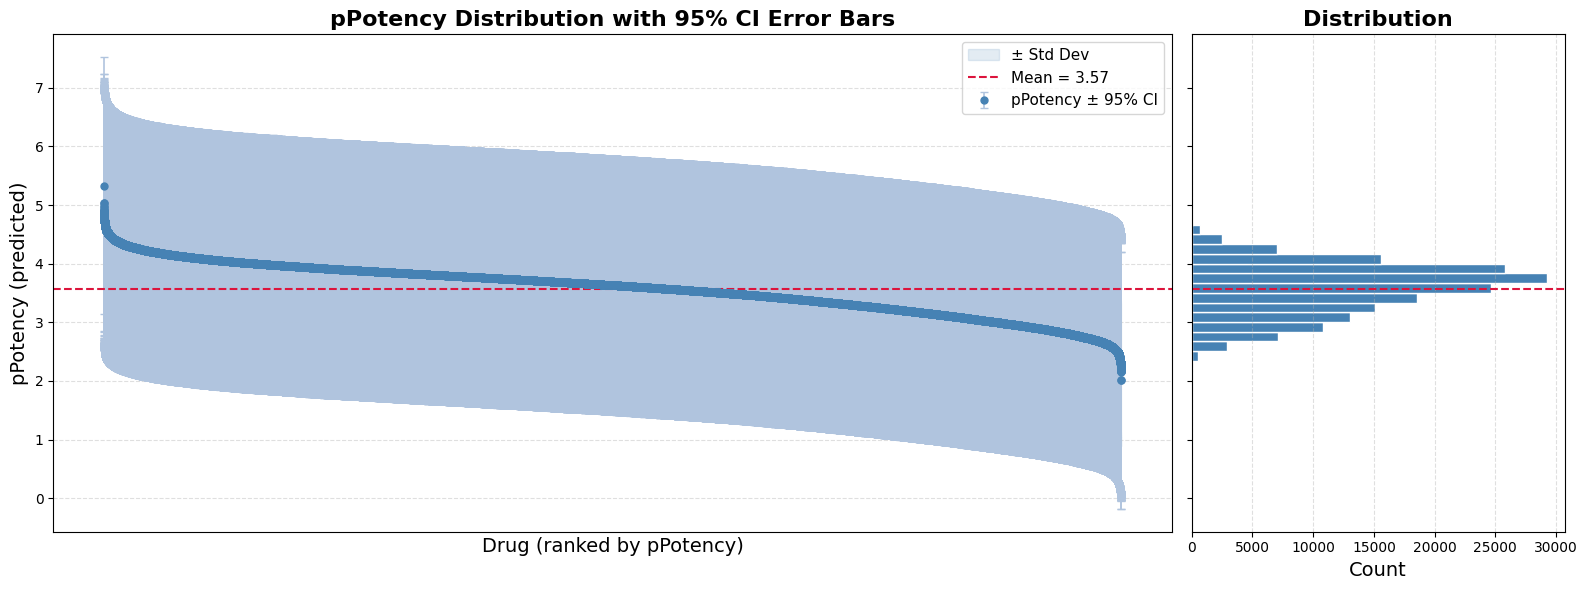

In [125]:
ppotencyDF = BacillusAnthracis_wART_BasidalinPrecursor_predicted_all.sort_values(
    "pPotency_prediction", ascending=False).reset_index(drop=True)

x = np.arange(len(ppotencyDF))
pred = ppotencyDF["pPotency_prediction"]
yerr = np.array([pred - ppotencyDF["pPotency_lower_95CI"],
                 ppotencyDF["pPotency_upper_95CI"] - pred])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6),
                                gridspec_kw={"width_ratios": [3, 1]}, sharey=True)

# ── Scatter + error bars ──────────────────────────────────────────────────────
ax1.errorbar(x, pred, yerr=yerr, fmt='o', color='steelblue', ecolor='lightsteelblue',
             elinewidth=1.2, capsize=3, markersize=5, alpha=1, label="pPotency ± 95% CI")
ax1.fill_between(x, pred - ppotencyDF["pPotency_std"], pred + ppotencyDF["pPotency_std"],
                 alpha=0.15, color='steelblue', label="± Std Dev")
ax1.axhline(pred.mean(),   color='crimson',    linestyle='--', linewidth=1.5, label=f'Mean = {pred.mean():.2f}')
#ax1.axhline(pred.median(), color='darkorange', linestyle=':',  linewidth=1.5, label=f'Median = {pred.median():.2f}')
ax1.set_xlabel("Drug (ranked by pPotency)", fontsize=14)  
ax1.set_ylabel("pPotency (predicted)",      fontsize=14) 
ax1.set_title("pPotency Distribution with 95% CI Error Bars", fontsize=16, fontweight='bold')  
ax1.set_xticks([])
ax1.legend(fontsize=11); ax1.grid(axis='y', linestyle='--', alpha=0.4)

# ── Histogram ─────────────────────────────────────────────────────────────────
ax2.hist(pred, bins=20, orientation='horizontal', color='steelblue', edgecolor='white', alpha=1)
ax2.axhline(pred.mean(),   color='crimson',    linestyle='--', linewidth=1.5)
#ax2.axhline(pred.median(), color='darkorange', linestyle=':',  linewidth=1.5)
ax2.set_xlabel("Count", fontsize=14)        
ax2.set_title("Distribution", fontsize=16, fontweight='bold') 
ax2.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_distribution_BasidalinPrecursor_wDoraxgb.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_distribution_BasidalinPrecursor_wDoraxgb.png")
plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### Read predicted `ADMET` properties for all candidate SMILES

In [126]:
BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity = pd.read_csv(saveDir + f'{target_organism}_BasidalinPrecursorDORAnetGenerated_Antibiotic_ARTprediction_wToxicity.csv')
# Identify columns that match the string
matched_cols = BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity.filter(like='drugbank_approved_percentile').columns
# Keep everything EXCEPT those columns
BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity = BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity.drop(columns=matched_cols)
max_val = BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity['pPotency_prediction'].max()
min_val = BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity

pPotency_prediction range: 1.800 → 5.331


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang,Clearance_Hepatocyte_AZ,Clearance_Microsome_AZ,Half_Life_Obach,HydrationFreeEnergy_FreeSolv,LD50_Zhu,Lipophilicity_AstraZeneca,PPBR_AZ,Solubility_AqSolDB,VDss_Lombardo
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.331199,1.119903,3.136188,7.526210,0.000005,2.977075e-08,0.000731,507.182,-1.62900,...,-6.532908,10.607536,21.695647,50.300162,-17.205968,1.654107,0.655960,57.025779,-0.437743,-4.687410
1,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,4.428906,1.118935,2.235793,6.622019,0.000037,2.387706e-07,0.005810,785.557,-2.42396,...,-6.475772,-3.364867,23.998967,23.188328,-17.767413,2.572223,0.824762,72.098404,-1.021829,-8.492948
2,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,4.461134,1.118921,2.268049,6.654220,0.000035,2.217075e-07,0.005394,787.573,-1.75026,...,-6.679487,1.394358,30.020669,41.759685,-18.648854,2.694055,1.037456,70.919499,-0.882326,-5.521714
3,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,4.529551,1.118626,2.337043,6.722059,0.000030,1.896448e-07,0.004602,744.417,-2.89890,...,-6.818474,5.750305,18.362396,75.728975,-19.110544,1.835266,0.205004,52.787176,0.022007,-3.040320
4,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,4.886733,1.119159,2.693181,7.080285,0.000013,8.312178e-08,0.002027,745.425,-2.56940,...,-6.744336,16.908523,47.892034,53.422075,-18.034575,2.189310,0.593944,55.243972,-0.186449,-8.067867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210076,CC(=O)N(C[C@H](C)C=C1C=C(O)C(=O)O1)C(=O)CN,3.235006,1.120611,1.038608,5.431404,0.000582,3.703361e-06,0.091494,268.269,-0.16110,...,-4.942543,19.222275,-13.245729,-26.206140,-13.784199,2.038853,-0.782325,56.416938,-1.252166,4.609630
210077,C=C1OC(=O)C(O)=C1C[C@@H](C)CNC(=O)[C@H](C)N,4.017921,1.118431,1.825797,6.210045,0.000096,6.165312e-07,0.014935,254.286,0.35860,...,-4.971337,18.877715,-7.608197,-16.089244,-12.828560,2.241299,-0.052081,47.861599,-0.621900,0.049090
210078,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,3.427273,1.119665,1.232729,5.621817,0.000374,2.388817e-06,0.058515,236.271,-0.15188,...,-4.665920,26.431825,-3.949410,4.130865,-13.637193,2.929543,0.018285,67.610269,-1.883527,4.866808
210079,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,3.531349,1.118973,1.338161,5.724536,0.000294,1.885662e-06,0.045903,254.286,-0.39730,...,-5.117675,22.680652,-22.316851,-11.262022,-13.711330,2.263901,-0.539212,33.198010,-0.924615,-1.704941


In [127]:
def canonicalize(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        return Chem.MolToSmiles(mol) if mol else None
    except:
        return None

# Canonicalize SMILES in both DataFrames
BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity["canon_SMILES"] = \
    BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity["SMILES"].apply(canonicalize)

BasidalinPrecursor_highFeasibility_molecules["canon_SMILES"] = \
    BasidalinPrecursor_highFeasibility_molecules["SMILES"].apply(canonicalize)

# Get valid canonical SMILES set from highFeasibility
highFeasibility_set = set(BasidalinPrecursor_highFeasibility_molecules["canon_SMILES"].dropna())

# Filter: keep only SMILES present in highFeasibility
BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity = \
    BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity[
        BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity["canon_SMILES"].isin(highFeasibility_set)
    ].drop(columns="canon_SMILES").reset_index(drop=True)

print(f"Filtered shape: {BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity.shape}")

Filtered shape: (58966, 57)


### 2. Antibiotic candidate prioritization by comparing with `Drugbank`

In [128]:
refDrugbankDF = drugBankDrug_FDAapproved_antibiotic_wART_wADMET.copy()
generatedCandidateDF = BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity.copy()

print("Drugbank reference dataframe shape:", refDrugbankDF.shape)
print("Generated candidate dataframe shape:", generatedCandidateDF.shape)

Drugbank reference dataframe shape: (132, 44)
Generated candidate dataframe shape: (58966, 57)


### 3. Harmonize metadata and the SMILES column

The candidate dataframe may use `SMILES` instead of `smiles`.  
This cell standardizes that and fills a few metadata fields if they are missing.

In [129]:
if "SMILES" in generatedCandidateDF.columns:
    generatedCandidateDF = generatedCandidateDF.rename(columns={"SMILES": "SMILES"})

if "ATC_code" not in generatedCandidateDF.columns:
    generatedCandidateDF["ATC_code"] = pd.NA

if "Drug_Type" not in generatedCandidateDF.columns:
    generatedCandidateDF["Drug_Type"] = "Predicted_candidate"

if "source_DataBase" not in generatedCandidateDF.columns:
    generatedCandidateDF["source_DataBase"] = "Generated"

refDrugbankDF["datasetLabel"] = "FDA-approved antibiotics"
generatedCandidateDF["datasetLabel"] = "Generated candidates"

print("smiles in refDrugbankDF:", "SMILES" in refDrugbankDF.columns)
print("smiles in generatedCandidateDF:", "SMILES" in generatedCandidateDF.columns)

smiles in refDrugbankDF: True
smiles in generatedCandidateDF: True


### 4. Define `ADMET` column groups

We keep:
- metadata
- potency-related columns
- toxicity-related columns
- ADME-related columns
- a few physicochemical property columns such as `QED`, `logP` and `molecular_weight`

In [130]:
metadataCols = [
    "SMILES",
    "ATC_code",
    "Drug_Type",
    "source_DataBase",
    "datasetLabel",
]

potencyCols = [
    "pPotency_prediction",
    "pPotency_std",
    "pPotency_lower_95CI",
    "pPotency_upper_95CI",
    "IC50(M)_prediction",
    "IC50(M)_lower_95CI",
    "IC50(M)_upper_95CI",
]

toxicityCols = [
    "AMES",
    "Carcinogens_Lagunin",
    "ClinTox",
    "DILI",
    "Skin_Reaction",
    "hERG",
    "LD50_Zhu",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma",
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
]

admeCols = [
    "Bioavailability_Ma",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Caco2_Wang",
    "Solubility_AqSolDB",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith",
    "Pgp_Broccatelli",
    "Clearance_Hepatocyte_AZ",
    "Clearance_Microsome_AZ",
    "Half_Life_Obach",
    "PPBR_AZ",
    "VDss_Lombardo",
]

optionalCols = ["BBB_Martins"]

physicochemCols = [
    "molecular_weight",
    "logP",
    "hydrogen_bond_acceptors",
    "hydrogen_bond_donors",
    "Lipinski",
    "QED",
    "stereo_centers",
    "tpsa",
    "HydrationFreeEnergy_FreeSolv",
    "Lipophilicity_AstraZeneca",
]

keepCols = list(dict.fromkeys(metadataCols + potencyCols + toxicityCols + admeCols + optionalCols + physicochemCols))
print("Total kept columns:", len(keepCols))

Total kept columns: 61


### 5. Build aligned reference and candidate dataframes

This cell keeps the same columns in both dataframes and creates any missing columns as `NaN`

In [131]:
def ensureCols(DF, colList):
    outDF = DF.copy()
    for colName in colList:
        if colName not in outDF.columns:
            outDF[colName] = np.nan
    return outDF[colList].copy()

refScoreDF = ensureCols(refDrugbankDF, keepCols)
candScoreDF = ensureCols(generatedCandidateDF, keepCols)

print("Reference aligned shape:", refScoreDF.shape)
print("Candidate aligned shape:", candScoreDF.shape)

Reference aligned shape: (132, 61)
Candidate aligned shape: (58966, 61)


### 6. Convert relevant columns to numeric

All scoring-related columns are converted to numeric.  

In [132]:
numericCols = list(dict.fromkeys(potencyCols + toxicityCols + admeCols + optionalCols + physicochemCols))

for colName in numericCols:
    if colName in refScoreDF.columns:
        refScoreDF[colName] = pd.to_numeric(refScoreDF[colName], errors="coerce")
    if colName in candScoreDF.columns:
        candScoreDF[colName] = pd.to_numeric(candScoreDF[colName], errors="coerce")

refScoreDF["potencyConservative"] = refScoreDF["pPotency_lower_95CI"].fillna(refScoreDF["pPotency_prediction"])
candScoreDF["potencyConservative"] = candScoreDF["pPotency_lower_95CI"].fillna(candScoreDF["pPotency_prediction"])

### 7. Define endpoint metadata

This table contains:
- endpoint name
- whether it belongs to the **toxicity** or **adme** group
- the direction of desirability:
  - `lowerBetter`
  - `higherBetter`
  - `referenceMatch`


In [133]:
endpointMetaDF = pd.DataFrame([
    # Toxicity
    {"endpoint": "AMES",                "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "Carcinogens_Lagunin", "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "ClinTox",             "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "DILI",                "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "Skin_Reaction",       "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "hERG",                "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "LD50_Zhu",            "majorGroup": "toxicity", "direction": "higherBetter"},
    {"endpoint": "NR-AR-LBD",           "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-AR",               "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-AhR",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-Aromatase",        "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-ER-LBD",           "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-ER",               "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-PPAR-gamma",       "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-ARE",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-ATAD5",            "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-HSE",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-MMP",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-p53",              "majorGroup": "toxicity", "direction": "lowerBetter"},

    # ADME
    {"endpoint": "Bioavailability_Ma",             "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "HIA_Hou",                        "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "PAMPA_NCATS",                    "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "Caco2_Wang",                     "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "Solubility_AqSolDB",             "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "CYP1A2_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP2C19_Veith",                  "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP2C9_Substrate_CarbonMangels", "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "CYP2C9_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP2D6_Substrate_CarbonMangels", "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "CYP2D6_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP3A4_Substrate_CarbonMangels", "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "CYP3A4_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "Pgp_Broccatelli",                "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "Clearance_Hepatocyte_AZ",        "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "Clearance_Microsome_AZ",         "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "Half_Life_Obach",                "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "PPBR_AZ",                        "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "VDss_Lombardo",                  "majorGroup": "adme", "direction": "referenceMatch"},
])

endpointMetaDF

,endpoint,majorGroup,direction
0,AMES,toxicity,lowerBetter
1,Carcinogens_Lagunin,toxicity,lowerBetter
2,ClinTox,toxicity,lowerBetter
3,DILI,toxicity,lowerBetter
4,Skin_Reaction,toxicity,lowerBetter
5,hERG,toxicity,lowerBetter
6,LD50_Zhu,toxicity,higherBetter
7,NR-AR-LBD,toxicity,lowerBetter
8,NR-AR,toxicity,lowerBetter
9,NR-AhR,toxicity,lowerBetter


### 8. Derive fully statistical endpoint weights from FDA-approved antibiotics from `Drugbank`

For each endpoint we compute:

- **informativeness** = inverse of the reference IQR  
  A tighter approved-antibiotic distribution means the endpoint is more constrained and therefore more informative.

- **uniqueness** = inverse redundancy penalty  
  Endpoints that are highly correlated with other endpoints in the same group get reduced weight.

The final endpoint weights are normalized inside each major group:
- `toxicity`
- `adme`

In [134]:
def robustIQR(series):
    cleanSeries = pd.to_numeric(series, errors="coerce").dropna()
    if len(cleanSeries) < 5:
        return np.nan
    q25, q75 = np.percentile(cleanSeries, [25, 75])
    return q75 - q25

weightRows = []

for majorGroupName in endpointMetaDF["majorGroup"].unique():
    groupMetaDF = endpointMetaDF[endpointMetaDF["majorGroup"] == majorGroupName].copy()
    groupEndpoints = groupMetaDF["endpoint"].tolist()

    groupRefDF = refScoreDF[groupEndpoints].apply(pd.to_numeric, errors="coerce")
    groupCorrDF = groupRefDF.corr().abs()

    for endpointName in groupEndpoints:
        series = groupRefDF[endpointName]
        iqrValue = robustIQR(series)

        informativeness = 1.0 / (iqrValue + 1e-6) if pd.notna(iqrValue) else 1.0

        otherEndpoints = [x for x in groupEndpoints if x != endpointName]
        if len(otherEndpoints) > 0 and endpointName in groupCorrDF.index:
            meanAbsCorr = groupCorrDF.loc[endpointName, otherEndpoints].dropna().mean()
            uniqueness = max(1.0 - meanAbsCorr, 1e-3) if pd.notna(meanAbsCorr) else 1.0
        else:
            uniqueness = 1.0

        rawWeight = informativeness * uniqueness

        weightRows.append({
            "endpoint": endpointName,
            "majorGroup": majorGroupName,
            "direction": groupMetaDF.loc[groupMetaDF["endpoint"] == endpointName, "direction"].iloc[0],
            "iqrValue": iqrValue,
            "informativeness": informativeness,
            "uniqueness": uniqueness,
            "rawWeight": rawWeight,
        })

weightDF = pd.DataFrame(weightRows)
weightDF["finalWeight"] = (
    weightDF.groupby("majorGroup")["rawWeight"]
    .transform(lambda x: x / x.sum())
)

weightDF.sort_values(["majorGroup", "finalWeight"], ascending=[True, False])

,endpoint,majorGroup,direction,iqrValue,informativeness,uniqueness,rawWeight,finalWeight
24,CYP1A2_Veith,adme,lowerBetter,0.007583,131.856666,0.875912,115.494897,0.374049
27,CYP2C9_Veith,adme,lowerBetter,0.015054,66.424005,0.743478,49.384762,0.159941
29,CYP2D6_Veith,adme,lowerBetter,0.023108,43.273037,0.852122,36.873917,0.119422
25,CYP2C19_Veith,adme,lowerBetter,0.020200,49.501684,0.716789,35.482260,0.114915
28,CYP2D6_Substrate_CarbonMangels,adme,referenceMatch,0.027401,36.494317,0.742754,27.106292,0.087788
31,CYP3A4_Veith,adme,lowerBetter,0.048597,20.577056,0.715226,14.717253,0.047664
32,Pgp_Broccatelli,adme,referenceMatch,0.087841,11.384115,0.775158,8.824486,0.028580
26,CYP2C9_Substrate_CarbonMangels,adme,referenceMatch,0.105874,9.445118,0.747599,7.061157,0.022869
30,CYP3A4_Substrate_CarbonMangels,adme,referenceMatch,0.278713,3.587905,0.749184,2.688000,0.008706
21,PAMPA_NCATS,adme,higherBetter,0.311315,3.212166,0.586158,1.882835,0.006098


### 9. Helper functions for desirability scoring and weighted aggregation

This section defines:

- percentile-based desirability functions
- a reference-matching desirability function
- weighted geometric mean aggregation

In [135]:
def getSortedRefArray(refSeries):
    refArray = pd.to_numeric(refSeries, errors="coerce").dropna().to_numpy(dtype=float)
    refArray = refArray[np.isfinite(refArray)]
    refArray = np.sort(refArray)
    return refArray

def higherBetterDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan, dtype=float)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    finiteMask = np.isfinite(valueArray)
    percentArray = np.searchsorted(refArray, valueArray[finiteMask], side="right") / len(refArray)
    outArray[finiteMask] = np.clip(percentArray, 0.0, 1.0)
    return pd.Series(outArray, index=valueSeries.index)

def lowerBetterDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan, dtype=float)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    finiteMask = np.isfinite(valueArray)
    percentArray = np.searchsorted(refArray, valueArray[finiteMask], side="right") / len(refArray)
    outArray[finiteMask] = np.clip(1.0 - percentArray, 0.0, 1.0)
    return pd.Series(outArray, index=valueSeries.index)

def referenceMatchDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan, dtype=float)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    refMedian = np.nanmedian(refArray)
    q25, q75 = np.nanpercentile(refArray, [25, 75])
    robustSigma = (q75 - q25) / 1.349 if q75 > q25 else np.nanstd(refArray)

    if not np.isfinite(robustSigma) or robustSigma <= 0:
        robustSigma = 1e-6

    finiteMask = np.isfinite(valueArray)
    zArray = (valueArray[finiteMask] - refMedian) / robustSigma
    outArray[finiteMask] = np.exp(-0.5 * (zArray ** 2))
    outArray = np.clip(outArray, 0.0, 1.0)

    return pd.Series(outArray, index=valueSeries.index)

def weightedGeoMeanSeries(DF, valueColList, weightSeries):
    valueMatrix = DF[valueColList].to_numpy(dtype=float)
    weightArray = np.asarray(weightSeries, dtype=float)
    outArray = np.full(valueMatrix.shape[0], np.nan, dtype=float)

    for rowIdx in range(valueMatrix.shape[0]):
        rowArray = valueMatrix[rowIdx]
        finiteMask = np.isfinite(rowArray)

        if finiteMask.sum() == 0:
            continue

        rowValues = np.clip(rowArray[finiteMask], 1e-6, 1.0)
        rowWeights = weightArray[finiteMask]
        outArray[rowIdx] = np.exp(np.sum(rowWeights * np.log(rowValues)) / np.sum(rowWeights))

    return pd.Series(outArray, index=DF.index)

### 10. Convert endpoints into 0–1 desirability scores

Every endpoint becomes a new `*_des` column.
We also compute `PotencyDesRaw` from the reference antibiotic potency distribution.

In [136]:
for _, rowDF in weightDF.iterrows():
    endpointName = rowDF["endpoint"]
    directionName = rowDF["direction"]
    desCol = f"{endpointName}_des"

    if directionName == "higherBetter":
        refScoreDF[desCol] = higherBetterDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desCol] = higherBetterDes(refScoreDF[endpointName], candScoreDF[endpointName])

    elif directionName == "lowerBetter":
        refScoreDF[desCol] = lowerBetterDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desCol] = lowerBetterDes(refScoreDF[endpointName], candScoreDF[endpointName])

    elif directionName == "referenceMatch":
        refScoreDF[desCol] = referenceMatchDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desCol] = referenceMatchDes(refScoreDF[endpointName], candScoreDF[endpointName])

refScoreDF["PotencyDesRaw"] = higherBetterDes(
    refScoreDF["pPotency_prediction"],
    refScoreDF["pPotency_prediction"]
)

candScoreDF["PotencyDesRaw"] = higherBetterDes(
    refScoreDF["pPotency_prediction"],
    candScoreDF["pPotency_prediction"]
)
refScoreDF

,SMILES,ATC_code,Drug_Type,source_DataBase,datasetLabel,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,...,CYP2D6_Veith_des,CYP3A4_Substrate_CarbonMangels_des,CYP3A4_Veith_des,Pgp_Broccatelli_des,Clearance_Hepatocyte_AZ_des,Clearance_Microsome_AZ_des,Half_Life_Obach_des,PPBR_AZ_des,VDss_Lombardo_des,PotencyDesRaw
0,NCC[C@H](O)C(=O)N[C@@H]1C[C@H](N)[C@@H](O[C@H]...,J01GB;J01RA,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,3.525954,1.119518,1.331698,5.720210,0.000298,...,0.477273,0.972613,0.818182,9.681491e-01,NaN,NaN,NaN,NaN,NaN,0.378788
1,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccc(O)cc3)...,J01CA;J01CR,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,4.987345,1.120375,2.791410,7.183280,0.000010,...,0.674242,0.830805,0.780303,9.318440e-01,NaN,NaN,NaN,NaN,NaN,0.977273
2,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](NC(=O)N3CCNC3=...,J01CA;J01CR,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,3.442877,1.119518,1.248620,5.637133,0.000361,...,0.825758,0.974109,0.765152,9.540457e-01,NaN,NaN,NaN,NaN,NaN,0.340909
3,C[C@H]1[C@H](NC(=O)/C(=N\OC(C)(C)C(=O)O)c2csc(...,J01DF,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,3.786489,1.118681,1.593873,5.979105,0.000163,...,0.750000,0.872005,0.893939,9.876953e-01,NaN,NaN,NaN,NaN,NaN,0.454545
4,CCOC(=O)OC(C)OC(=O)[C@@H]1N2C(=O)[C@@H](NC(=O)...,J01CA;J01CR,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,3.794162,1.118931,1.601058,5.987267,0.000161,...,0.022727,0.378266,0.030303,2.050005e-01,NaN,NaN,NaN,NaN,NaN,0.469697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,J01AA,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,4.309461,1.118857,2.116502,6.502420,0.000049,...,0.189394,0.214633,0.371212,5.888156e-01,NaN,NaN,NaN,NaN,NaN,0.810606
128,CCS(=O)(=O)CCn1c([N+](=O)[O-])cnc1C,J01RA;J01XD,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,4.424298,1.118918,2.231218,6.617377,0.000038,...,0.931818,0.066655,0.856061,8.940999e-01,NaN,NaN,NaN,NaN,NaN,0.878788
129,CO[C@H]1C[C@H](O[C@H]2[C@H](C)[C@@H](O[C@@H]3O...,J01FA,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,2.276538,1.125678,0.070209,4.482867,0.005290,...,0.462121,0.078071,0.022727,2.447435e-41,NaN,NaN,NaN,NaN,NaN,0.068182
130,N[C@@H]1[C@H]2CN(c3nc4c(cc3F)c(=O)c(C(=O)O)cn4...,J01MA,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,3.073553,1.126205,0.866192,5.280915,0.000844,...,0.151515,0.847208,0.522727,9.819411e-01,NaN,NaN,NaN,NaN,NaN,0.265152


### 11. Directly aggregate within the two separate ADMET groups

This notebook uses:
- one direct **toxicity** aggregate
- one direct **adme** aggregate

Then we define:
- `ToxicitySafety`
- `Toxicity Score = 1 - ToxicitySafety`
- `ADMEFeasibility`

In [137]:
toxWeightDF = weightDF[weightDF["majorGroup"] == "toxicity"].copy()
admeWeightDF = weightDF[weightDF["majorGroup"] == "adme"].copy()

toxDesCols = [f"{endpointName}_des" for endpointName in toxWeightDF["endpoint"]]
admeDesCols = [f"{endpointName}_des" for endpointName in admeWeightDF["endpoint"]]

refScoreDF["ToxicitySafety"] = weightedGeoMeanSeries(
    refScoreDF,
    toxDesCols,
    toxWeightDF["finalWeight"]
)
candScoreDF["ToxicitySafety"] = weightedGeoMeanSeries(
    candScoreDF,
    toxDesCols,
    toxWeightDF["finalWeight"]
)

refScoreDF["ADMEFeasibility"] = weightedGeoMeanSeries(
    refScoreDF,
    admeDesCols,
    admeWeightDF["finalWeight"]
)
candScoreDF["ADMEFeasibility"] = weightedGeoMeanSeries(
    candScoreDF,
    admeDesCols,
    admeWeightDF["finalWeight"]
)

refScoreDF["coreToxicityScore"] = 1.0 - refScoreDF["ToxicitySafety"]
candScoreDF["coreToxicityScore"] = 1.0 - candScoreDF["ToxicitySafety"]

refScoreDF["ToxicityBurden"] = refScoreDF["coreToxicityScore"]
candScoreDF["ToxicityBurden"] = candScoreDF["coreToxicityScore"]

refScoreDF[["pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"]].describe().T

,count,mean,std,min,25%,50%,75%,max
pPotency_prediction,132.0,3.684012,0.821362,1.343247,3.046390,3.928463,4.233035,5.897288
coreToxicityScore,132.0,0.570184,0.217179,0.162787,0.405250,0.589680,0.734321,0.998633
ADMEFeasibility,132.0,0.442508,0.239315,0.002264,0.262605,0.418293,0.628735,0.939134


## 12. Inspect the statistically derived endpoint weights

In [138]:
weightDF.sort_values(["majorGroup", "finalWeight"], ascending=[True, False])

,endpoint,majorGroup,direction,iqrValue,informativeness,uniqueness,rawWeight,finalWeight
24,CYP1A2_Veith,adme,lowerBetter,0.007583,131.856666,0.875912,115.494897,0.374049
27,CYP2C9_Veith,adme,lowerBetter,0.015054,66.424005,0.743478,49.384762,0.159941
29,CYP2D6_Veith,adme,lowerBetter,0.023108,43.273037,0.852122,36.873917,0.119422
25,CYP2C19_Veith,adme,lowerBetter,0.020200,49.501684,0.716789,35.482260,0.114915
28,CYP2D6_Substrate_CarbonMangels,adme,referenceMatch,0.027401,36.494317,0.742754,27.106292,0.087788
31,CYP3A4_Veith,adme,lowerBetter,0.048597,20.577056,0.715226,14.717253,0.047664
32,Pgp_Broccatelli,adme,referenceMatch,0.087841,11.384115,0.775158,8.824486,0.028580
26,CYP2C9_Substrate_CarbonMangels,adme,referenceMatch,0.105874,9.445118,0.747599,7.061157,0.022869
30,CYP3A4_Substrate_CarbonMangels,adme,referenceMatch,0.278713,3.587905,0.749184,2.688000,0.008706
21,PAMPA_NCATS,adme,higherBetter,0.311315,3.212166,0.586158,1.882835,0.006098


### 13. Plot: `high pPotency` and `low Toxicity Score`

Selection rule:
- pPotency in the top quartile of generated compounds
- Toxicity Score in the bottom quartile of generated compounds

Within that selected region, ranking uses the geometric mean of:
- `PotencyDesRaw`
- `ToxicitySafety`

In [139]:
cand2DDF = candScoreDF.copy()

cand2DDF = cand2DDF[
    cand2DDF[["pPotency_prediction", "coreToxicityScore", "ToxicitySafety", "PotencyDesRaw"]]
    .notna()
    .all(axis=1)
].copy()

xCutoff2D = cand2DDF["pPotency_prediction"].quantile(0.75)
yCutoff2D = cand2DDF["coreToxicityScore"].quantile(0.25)

optimal2DDF = cand2DDF[
    (cand2DDF["pPotency_prediction"] >= xCutoff2D) &
    (cand2DDF["coreToxicityScore"] <= yCutoff2D)
].copy()

optimal2DDF["OverallPriority2D"] = np.sqrt(
    optimal2DDF["PotencyDesRaw"] * optimal2DDF["ToxicitySafety"]
)

top20_2D_DF = optimal2DDF.sort_values(
    by=["OverallPriority2D", "pPotency_prediction", "coreToxicityScore"],
    ascending=[False, False, True]
).head(20).copy()

top20_2D_DF["Top20Rank_2D"] = np.arange(1, len(top20_2D_DF) + 1)

top20_2D_DF[
    [
        "Top20Rank_2D",
        "SMILES",
        "pPotency_prediction",
        "pPotency_std",
        "pPotency_lower_95CI",
        "coreToxicityScore",
        "ToxicitySafety",
        "OverallPriority2D",
        "QED",
    ]
]

,Top20Rank_2D,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,coreToxicityScore,ToxicitySafety,OverallPriority2D,QED
43371,1,C=CC[C@](CNC(N)=[NH2+])(CC(=C)O)C(=O)O,4.511873,1.118982,2.318669,0.078223,0.921777,0.915412,0.161400
40436,2,CC[C@](C)(CC(O)=CCNC(N)=[NH2+])C(=O)O,4.534401,1.119705,2.339779,0.093844,0.906156,0.911396,0.227121
43526,3,C=CC[C@](C)(CC(O)=CCNC(N)=[NH2+])C(=O)O,4.463594,1.119450,2.269472,0.104154,0.895846,0.898676,0.172212
43853,4,C=C(O)C[C@](CCCC)(CNC(N)=[NH2+])C(=O)O,4.533397,1.119313,2.339545,0.132539,0.867461,0.891725,0.221073
52553,5,C=CC[C@@H](CC(O)C[C@@H](CC)C(N)=O)C(=O)O,4.510103,1.119177,2.316517,0.126102,0.873898,0.891321,0.523933
43352,6,C=C(O)C[C@H](CC(=C)CNC(N)=[NH2+])C(=O)O,4.570368,1.119429,2.376288,0.133679,0.866321,0.891138,0.161400
40432,7,CC[C@@H](CC(O)CCNC(N)=[NH2+])C(=O)O,4.468752,1.119295,2.274935,0.128312,0.871688,0.890193,0.247485
42655,8,NC(=[NH2+])NCC=C(O)C[C@H](O)CO,4.520336,1.118969,2.327156,0.129316,0.870684,0.889680,0.154977
48415,9,CC[C@@](O)(CC(=O)O)C(O)=CCC(N)=O,4.372450,1.119070,2.179073,0.073134,0.926866,0.886810,0.463501
40260,10,CC(C)(CC(O)=CCNC(N)=[NH2+])C(=O)O,4.488971,1.119153,2.295432,0.143259,0.856741,0.882528,0.219552


### 14. plot: pPotency vs Toxicity Score

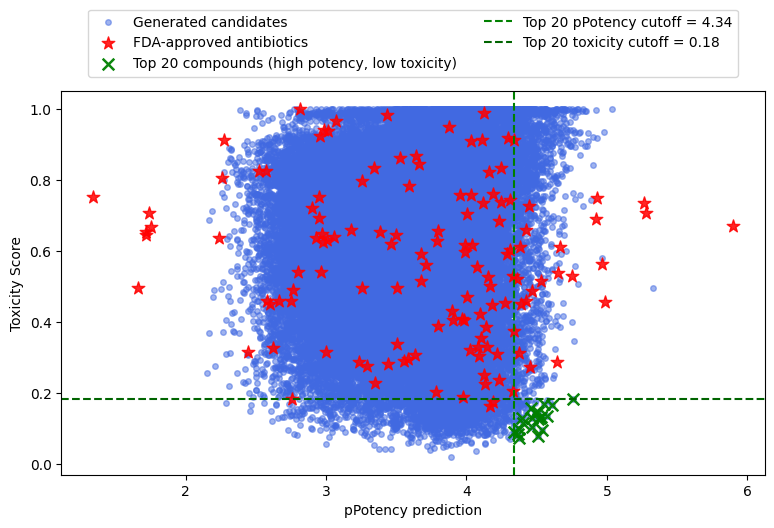

In [140]:
# Display cutoffs from the actual top 20 compounds
xDisplay = top20_2D_DF["pPotency_prediction"].min()
yDisplay = top20_2D_DF["coreToxicityScore"].max()

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    cand2DDF["pPotency_prediction"],
    cand2DDF["coreToxicityScore"],
    s=16, alpha=0.5, color="royalblue", label="Generated candidates"
)

ax.scatter(
    refScoreDF["pPotency_prediction"],
    refScoreDF["coreToxicityScore"],
    marker="*", s=90, alpha=0.85, color="red", label="FDA-approved antibiotics"
)

ax.scatter(
    top20_2D_DF["pPotency_prediction"],
    top20_2D_DF["coreToxicityScore"],
    marker="x", s=70, linewidths=1.8, alpha=0.95, color="green",
    label="Top 20 compounds (high potency, low toxicity)"
)

ax.axvline(
    xDisplay,
    linestyle="--",
    linewidth=1.5,
    color="green",
    label=f"Top 20 pPotency cutoff = {xDisplay:.2f}"
)

ax.axhline(
    yDisplay,
    linestyle="--",
    linewidth=1.5,
    color="darkgreen",
    label=f"Top 20 toxicity cutoff = {yDisplay:.2f}"
)

ax.set_xlabel("pPotency prediction")
ax.set_ylabel("Toxicity Score")

ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.90])

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_BasidalinPrecursor_wDoraxgb.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_BasidalinPrecursor_wDoraxgb.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

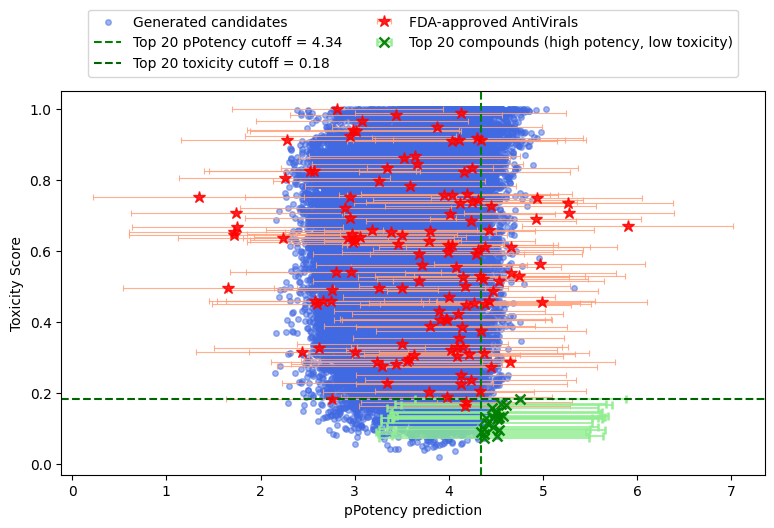

In [141]:
# Display cutoffs from the actual top 20 compounds
xDisplay = top20_2D_DF["pPotency_prediction"].min()
yDisplay = top20_2D_DF["coreToxicityScore"].max()

fig, ax = plt.subplots(figsize=(8, 6))

# ── Helper to compute asymmetric xerr ────────────────────────────────────────
'''
def get_xerr(df):
    return np.array([
        df["pPotency_prediction"] - df["pPotency_lower_95CI"],
        df["pPotency_upper_95CI"] - df["pPotency_prediction"],
    ])
'''

def get_xerr(df):
    return df["pPotency_std"].values  # symmetric → single array, not shape(2,N)


# ── Generated candidates ──────────────────────────────────────────────────────
ax.scatter(
    cand2DDF["pPotency_prediction"],
    cand2DDF["coreToxicityScore"],
    s=16, alpha=0.5, color="royalblue", label="Generated candidates"
)


# ── FDA-approved AntiVirals ───────────────────────────────────────────────────
ax.errorbar(
    refScoreDF["pPotency_prediction"],
    refScoreDF["coreToxicityScore"],
    xerr=get_xerr(refScoreDF),
    fmt="*", color="red", ecolor="lightsalmon",
    elinewidth=0.8, capsize=2, capthick=0.8,
    markersize=9, alpha=0.85, label="FDA-approved AntiVirals"
)

# ── Top 20 compounds ──────────────────────────────────────────────────────────
ax.errorbar(
    top20_2D_DF["pPotency_prediction"],
    top20_2D_DF["coreToxicityScore"],
    xerr=get_xerr(top20_2D_DF),
    fmt="x", color="green", ecolor="lightgreen",
    elinewidth=1.2, capsize=3, capthick=1.2,
    markersize=7, markeredgewidth=1.8,
    alpha=0.95, label="Top 20 compounds (high potency, low toxicity)"
)

ax.axvline(xDisplay, linestyle="--", linewidth=1.5, color="green",
           label=f"Top 20 pPotency cutoff = {xDisplay:.2f}")
ax.axhline(yDisplay, linestyle="--", linewidth=1.5, color="darkgreen",
           label=f"Top 20 toxicity cutoff = {yDisplay:.2f}")

ax.set_xlabel("pPotency prediction")
ax.set_ylabel("Toxicity Score")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.90])

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_BasidalinPrecursor_wDoraxgb.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_BasidalinPrecursor_wDoraxgb.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### 15. Plot: `high pPotency`, `low Toxicity Score`, `high ADME feasibility`

Selection rule:
- pPotency in the top quartile
- Toxicity Score in the bottom quartile
- ADMEFeasibility in the top quartile

Within that region, ranking uses the unweighted geometric mean of:
- `PotencyDesRaw`
- `ToxicitySafety`
- `ADMEFeasibility`

In [142]:
cand3DDF = candScoreDF.copy()

cand3DDF = cand3DDF[
    cand3DDF[["pPotency_prediction", "coreToxicityScore", "ADMEFeasibility", "ToxicitySafety", "PotencyDesRaw"]]
    .notna()
    .all(axis=1)
].copy()

xCutoff3D = cand3DDF["pPotency_prediction"].quantile(0.75)
yCutoff3D = cand3DDF["coreToxicityScore"].quantile(0.25)
zCutoff3D = cand3DDF["ADMEFeasibility"].quantile(0.75)

optimal3DDF = cand3DDF[
    (cand3DDF["pPotency_prediction"] >= xCutoff3D) &
    (cand3DDF["coreToxicityScore"] <= yCutoff3D) &
    (cand3DDF["ADMEFeasibility"] >= zCutoff3D)
].copy()

optimal3DDF["OverallPriority3D"] = (
    optimal3DDF["PotencyDesRaw"] *
    optimal3DDF["ToxicitySafety"] *
    optimal3DDF["ADMEFeasibility"]
) ** (1 / 3)

top20_3D_DF = optimal3DDF.sort_values(
    by=["OverallPriority3D", "pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"],
    ascending=[False, False, True, False]
).head(20).copy()

top20_3D_DF["Top20Rank_3D"] = np.arange(1, len(top20_3D_DF) + 1)

top20_3D_DF[
    [
        "Top20Rank_3D",
        "SMILES",
        "pPotency_prediction",
        "pPotency_std",
        "pPotency_lower_95CI",
        "coreToxicityScore",
        "ADMEFeasibility",
        "ToxicitySafety",
        "OverallPriority3D",
        "QED",
    ]
]

,Top20Rank_3D,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,coreToxicityScore,ADMEFeasibility,ToxicitySafety,OverallPriority3D,QED
40436,1,CC[C@](C)(CC(O)=CCNC(N)=[NH2+])C(=O)O,4.534401,1.119705,2.339779,0.093844,0.909985,0.906156,0.910926,0.227121
43371,2,C=CC[C@](CNC(N)=[NH2+])(CC(=C)O)C(=O)O,4.511873,1.118982,2.318669,0.078223,0.893079,0.921777,0.907906,0.161400
48415,3,CC[C@@](O)(CC(=O)O)C(O)=CCC(N)=O,4.372450,1.119070,2.179073,0.073134,0.939425,0.926866,0.904012,0.463501
49523,4,CC[C@@](C)(C=C(O)CCC(=O)O)C(N)=O,4.368347,1.119058,2.174994,0.084021,0.932976,0.915979,0.898394,0.579173
4465,5,C=C(O)C[C@@](CC)(OC)C(=O)O,4.319544,1.118832,2.126633,0.082931,0.965591,0.917069,0.895368,0.616822
49532,6,C[C@@H](CC(O)=CCC(N)=O)C(=O)O,4.350161,1.118645,2.157616,0.099503,0.934465,0.900497,0.891110,0.542512
4762,7,C=C(O)C[C@](C)(CC)C(=O)O,4.401008,1.119220,2.207337,0.114760,0.908709,0.885240,0.888253,0.614596
43526,8,C=CC[C@](C)(CC(O)=CCNC(N)=[NH2+])C(=O)O,4.463594,1.119450,2.269472,0.104154,0.862754,0.895846,0.886539,0.172212
40260,9,CC(C)(CC(O)=CCNC(N)=[NH2+])C(=O)O,4.488971,1.119153,2.295432,0.143259,0.877232,0.856741,0.880759,0.219552
43352,10,C=C(O)C[C@H](CC(=C)CNC(N)=[NH2+])C(=O)O,4.570368,1.119429,2.376288,0.133679,0.859715,0.866321,0.880538,0.161400


### 16. plot: pPotency vs Toxicity Score vs ADME feasibility

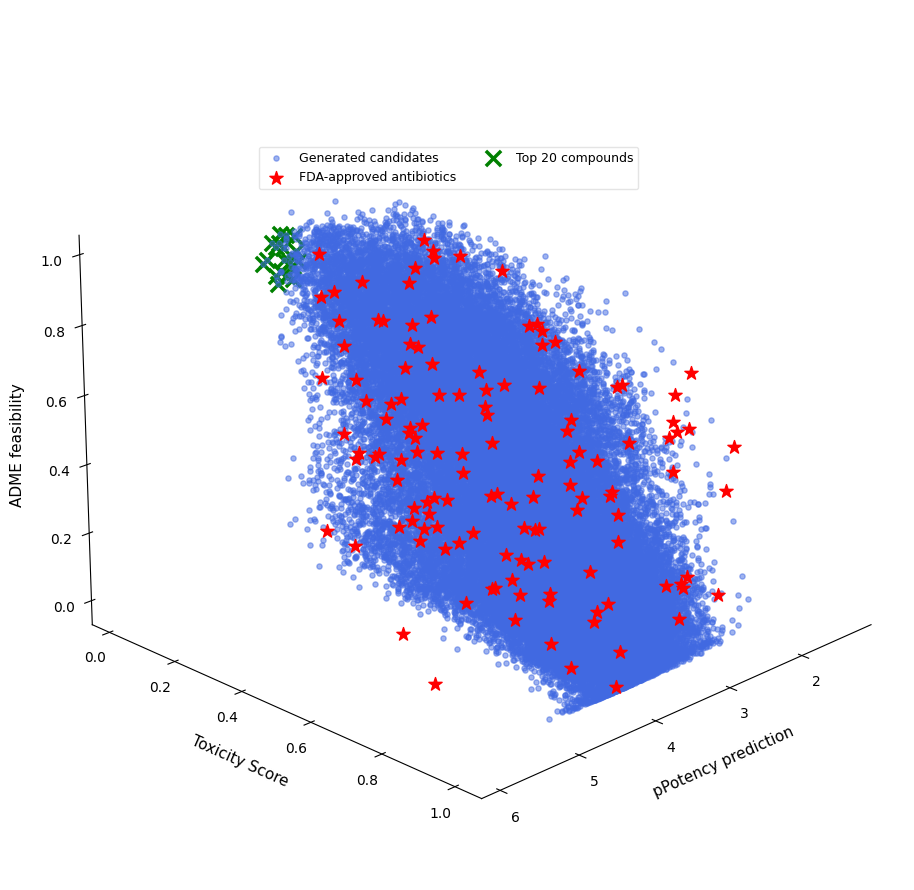

In [143]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(13, 10))
ax  = fig.add_subplot(111, projection="3d")

fig.patch.set_alpha(0.0)
ax.set_facecolor((0, 0, 0, 0))

for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
    pane.fill = False
    pane.set_edgecolor("lightgray")
    pane.set_alpha(0.0)

ax.grid(False)
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"]["linewidth"] = 0
    axis.label.set_color("k")
    axis.set_tick_params(colors="k")

ax.scatter(
    cand3DDF["pPotency_prediction"], cand3DDF["coreToxicityScore"], cand3DDF["ADMEFeasibility"],
    s=14, alpha=0.5, color="royalblue", label="Generated candidates", depthshade=False,
)
ax.scatter(
    refScoreDF["pPotency_prediction"], refScoreDF["coreToxicityScore"], refScoreDF["ADMEFeasibility"],
    marker="*", s=100, alpha=1.0, color="red", label="FDA-approved antibiotics", depthshade=False,
)
ax.scatter(
    top20_3D_DF["pPotency_prediction"], top20_3D_DF["coreToxicityScore"], top20_3D_DF["ADMEFeasibility"],
    marker="x", s=120, linewidths=2.5, alpha=1.0, color="green", label="Top 20 compounds", depthshade=False,
)

xCutoff = top20_3D_DF["pPotency_prediction"].min()
yCutoff = top20_3D_DF["coreToxicityScore"].max()
zCutoff = top20_3D_DF["ADMEFeasibility"].min()

xMin, xMax = ax.get_xlim()
yMin, yMax = ax.get_ylim()
zMin, zMax = ax.get_zlim()

#cutoffStyle = dict(linewidth=1.8, linestyle="--", alpha=0.85)
#ax.plot([xMin,    xCutoff], [yCutoff, yCutoff], [zCutoff, zCutoff], color="green",     label=f"pPotency cutoff = {xCutoff:.2f}", **cutoffStyle)
#ax.plot([xCutoff, xCutoff], [yCutoff, yMax],    [zCutoff, zCutoff], color="darkolivegreen", label=f"Toxicity cutoff = {yCutoff:.2f}", **cutoffStyle)
#ax.plot([xCutoff, xCutoff], [yCutoff, yCutoff], [zMin,    zCutoff], color="seagreen",  label=f"ADME cutoff = {zCutoff:.2f}",    **cutoffStyle)
#ax.scatter([xCutoff], [yCutoff], [zCutoff], marker="D", s=180, color="gold", edgecolors="darkorange", linewidths=1.5, zorder=10, label="Optimal cutoff corner", depthshade=False)

ax.set_xlabel("pPotency prediction", labelpad=10, color="k", fontsize=11)
ax.set_ylabel("Toxicity Score", labelpad=10, color="k", fontsize=11)
ax.set_zlabel("ADME feasibility",    labelpad=10, color="k", fontsize=11)
ax.set_zlabel("")
ax.text2D(-0.02, 0.5, "ADME feasibility", transform=ax.transAxes, fontsize=11, color="k", rotation=90, va="center", ha="center")

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.set_tick_params(colors="k", labelsize=10)

ax.view_init(elev=22, azim=45)
ax.legend(loc="upper left", bbox_to_anchor=(0.25, 0.85), ncol=2, frameon=True, framealpha=0.3, facecolor="white", edgecolor="darkgray", labelcolor="black", fontsize=9)
fig.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.05)

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_3d_BasidalinPrecursor_wDoraxgb.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_3d_BasidalinPrecursor_wDoraxgb.png")
plt.savefig(svg_path, format="svg", dpi=600, transparent=True, pad_inches=0.5)
plt.savefig(png_path, format="png", dpi=600, transparent=True, pad_inches=0.5)
plt.show()

### 17. Custom projected 3D plot for presentation

This is a presentation-oriented 2D projection of 3 variables.

Projected axes:
- horizontal right = `pPotency`
- vertical up = `Toxicity Score`
- diagonal lower-left = `ADME feasibility`

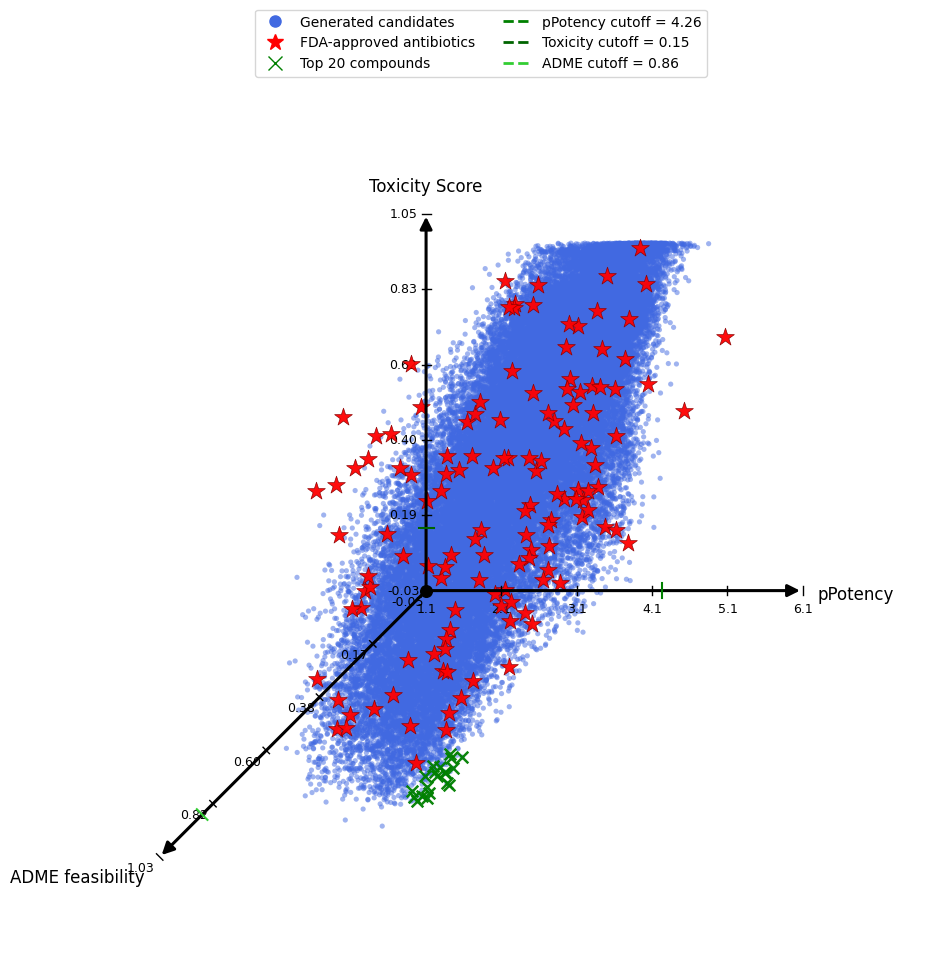

In [144]:
xCol, yCol, zCol = "pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"
cols = [xCol, yCol, zCol]

allPlotDF = cand3DDF[cols][np.isfinite(cand3DDF[cols]).all(axis=1)].copy()
refPlotDF = refScoreDF[cols][np.isfinite(refScoreDF[cols]).all(axis=1)].copy()
topPlotDF = top20_3D_DF[cols][np.isfinite(top20_3D_DF[cols]).all(axis=1)].copy()

def paddedRange(arr, frac=0.05):
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    pad = (hi - lo) * frac if (hi - lo) > 0 else 1.0
    return lo - pad, hi + pad

combined          = pd.concat([allPlotDF, refPlotDF, topPlotDF])
(X_MIN, X_MAX), (Y_MIN, Y_MAX), (Z_MIN, Z_MAX) = [paddedRange(combined[c]) for c in cols]

O  = np.zeros(2)
UX = np.array([1.0, 0.0])
UY = np.array([0.0, 1.0])
UZ = np.array([math.cos(math.radians(225)), math.sin(math.radians(225))])

def project(x, y, z):
    return O + ((x-X_MIN)/(X_MAX-X_MIN))*UX + ((y-Y_MIN)/(Y_MAX-Y_MIN))*UY + ((z-Z_MIN)/(Z_MAX-Z_MIN))*UZ

def projectDF(df):
    pts = np.array([project(r[xCol], r[yCol], r[zCol]) for _, r in df.iterrows()])
    return pts[:, 0], pts[:, 1]

allCX, allCY = projectDF(allPlotDF)
refCX, refCY = projectDF(refPlotDF)
topCX, topCY = projectDF(topPlotDF)

TIP_X, TIP_Y, TIP_Z = O + UX, O + UY, O + UZ

fig, ax = plt.subplots(figsize=(12, 11), facecolor="white")
ax.set(facecolor="white", aspect="equal")
ax.axis("off")

for tip in [TIP_X, TIP_Y, TIP_Z]:
    ax.annotate("", xy=tip, xytext=O, zorder=5,
                arrowprops=dict(arrowstyle="-|>", color="black", lw=2.2, mutation_scale=18))

ax.scatter(*O, s=70, c="black", zorder=6)

def drawTicks(unitVec, valMin, valMax, offset, nTicks=5, fmt="{:.2f}"):
    perp = np.array([unitVec[1], -unitVec[0]])
    perp /= np.linalg.norm(perp)
    for i in range(nTicks + 1):
        t, pos = i / nTicks, O + (i / nTicks) * unitVec
        ax.plot(*zip(pos - 0.012*perp, pos + 0.012*perp), color="black", lw=1.0, zorder=5)
        ax.text(*(pos + offset), fmt.format(valMin + t*(valMax-valMin)), fontsize=9, ha="center", va="center")

drawTicks(UX, X_MIN, X_MAX, np.array([ 0.00, -0.05]), fmt="{:.1f}")
drawTicks(UY, Y_MIN, Y_MAX, np.array([-0.06,  0.00]))
drawTicks(UZ, Z_MIN, Z_MAX, np.array([-0.05, -0.03]))

ax.scatter(allCX, allCY, color="royalblue", s=14,  alpha=0.5,  edgecolors="none", zorder=2)
ax.scatter(refCX, refCY, color="red",       s=180, alpha=0.95, marker="*", edgecolors="darkred", linewidths=0.5, zorder=4)
ax.scatter(topCX, topCY, color="green",     s=70,  alpha=0.95, marker="x", linewidths=1.8, zorder=5)

xCut, yCut, zCut = topPlotDF[xCol].min(), topPlotDF[yCol].max(), topPlotDF[zCol].min()
tickLen = 0.02

UZ_perp = np.array([-UZ[1], UZ[0]]) 
UZ_perp /= np.linalg.norm(UZ_perp)           
zPt = O + ((zCut-Z_MIN)/(Z_MAX-Z_MIN))*UZ 

for pt, color, dx, dy in [
    (O + ((xCut-X_MIN)/(X_MAX-X_MIN))*UX, "green", 0, tickLen),
    (O + ((yCut-Y_MIN)/(Y_MAX-Y_MIN))*UY, "darkgreen",  tickLen, 0),
]:
    ax.plot([pt[0]-dx, pt[0]+dx], [pt[1]-dy, pt[1]+dy], color=color, lw=1.5, zorder=5)

# Z cutoff tick perpendicular to UZ
ax.plot(
    [zPt[0] - tickLen*UZ_perp[0], zPt[0] + tickLen*UZ_perp[0]],
    [zPt[1] - tickLen*UZ_perp[1], zPt[1] + tickLen*UZ_perp[1]],
    color="limegreen", lw=1.5, zorder=5
)

ax.text(TIP_X[0]+0.04, TIP_X[1]-0.01, "pPotency",            fontsize=12, ha="left",   va="center")
ax.text(TIP_Y[0],      TIP_Y[1]+0.05, "Toxicity Score",  fontsize=12, ha="center", va="bottom")
ax.text(TIP_Z[0]-0.04, TIP_Z[1]-0.03, "ADME feasibility",    fontsize=12, ha="right",  va="top")

allPx = np.concatenate([allCX, refCX, topCX, [TIP_X[0], TIP_Y[0], TIP_Z[0]]])
allPy = np.concatenate([allCY, refCY, topCY, [TIP_X[1], TIP_Y[1], TIP_Z[1]]])
ax.set_xlim(allPx.min()-0.3, allPx.max()+0.3)
ax.set_ylim(allPy.min()-0.3, allPy.max()+0.3)

handles = [
    mlines.Line2D([], [], color="royalblue", marker="o", linestyle="None", markersize=8, label="Generated candidates"),
    mlines.Line2D([], [], color="red",       marker="*", linestyle="None", markersize=12, label="FDA-approved antibiotics"),
    mlines.Line2D([], [], color="green",     marker="x", linestyle="None", markersize=10, label="Top 20 compounds"),
    mlines.Line2D([], [], color="green",     linestyle="--", lw=2, label=f"pPotency cutoff = {xCut:.2f}"),
    mlines.Line2D([], [], color="darkgreen", linestyle="--", lw=2, label=f"Toxicity cutoff = {yCut:.2f}"),
    mlines.Line2D([], [], color="limegreen", linestyle="--", lw=2, label=f"ADME cutoff = {zCut:.2f}"),
]
ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_BasidalinPrecursor_wDoraxgb.svg"), format="svg", dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_BasidalinPrecursor_wDoraxgb.png"), format="png", dpi=600, bbox_inches="tight", facecolor="white")
plt.show()

### 18. Save the top 20 candidates

In [145]:
top20_2D_cols = ["Top20Rank_2D", "SMILES", "pPotency_prediction", "pPotency_std", "pPotency_lower_95CI", "pPotency_upper_95CI", "coreToxicityScore", "ToxicitySafety", "OverallPriority2D", "QED"]
top20_3D_cols = ["Top20Rank_3D", "SMILES", "pPotency_prediction", "pPotency_std", "pPotency_lower_95CI", "pPotency_upper_95CI", "coreToxicityScore", "ADMEFeasibility", "ToxicitySafety", "OverallPriority3D", "QED"]

toxicityTop20Path = os.path.join(saveDir, f"{target_organism}_potency_coreToxicity_top20_BasidalinPrecursor_wDoraxgb.csv")
admetTop20Path    = os.path.join(saveDir, f"{target_organism}_potency_coreToxicity_adme_top20_BasidalinPrecursor_wDoraxgb.csv")

top20_2D_DF[top20_2D_cols[1:]].to_csv(toxicityTop20Path, index=False)
top20_3D_DF[top20_3D_cols[1:]].to_csv(admetTop20Path,    index=False)

print(f"Saved:\n- {toxicityTop20Path}\n- {admetTop20Path}")

#display(top20_2D_DF[top20_2D_cols])
#display(top20_3D_DF[top20_3D_cols])

Saved:
- /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB/BacillusAnthracis_potency_coreToxicity_top20_BasidalinPrecursor.csv
- /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB/BacillusAnthracis_potency_coreToxicity_adme_top20_BasidalinPrecursor.csv


# How to use `FDA withdrawn` drug candidates to reltively score `Toxicity`

### Read `ADMET` endpoints for the `withdrawn` drugs from `Drugbank`

In [146]:
drugBankDrugWithdrawnDataDF_wADMET = pd.read_csv(dataDir + '/Toxicity/DrugBank/drugBankDrugWithdrawnDataDF_wADMET.csv')
drugBankDrugWithdrawnDataDF_wADMET

,Unnamed: 0,DrugBank ID,Drug Groups,Name,Formula,CAS Number,InChIKey,ChEMBL ID,SMILES,AMES,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,0,DB00106,approved; investigational; withdrawn,Abarelix,C72H95ClN14O14,183552-38-7,AIWRTTMUVOZGPW-HSPKUQOVSA-N,CHEMBL1252,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,0.244807,...,0.463332,0.605704,0.017399,0.263449,0.207183,0.100211,0.232910,0.125635,0.925135,0.938593
1,1,DB00131,approved; investigational; nutraceutical; with...,Adenosine phosphate,C10H14N5O7P,61-19-8,UDMBCSSLTHHNCD-KQYNXXCUSA-N,CHEMBL752,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,0.215953,...,0.027663,0.470261,0.000746,0.008154,0.066037,0.003312,0.010593,0.036415,0.061753,0.000318
2,2,DB00132,approved; investigational; nutraceutical; with...,alpha-Linolenic acid,C18H30O2,463-40-1,DTOSIQBPPRVQHS-PDBXOOCHSA-N,CHEMBL8739,CC/C=C\C/C=C\C/C=C\CCCCCCCC(=O)O,0.494518,...,0.737525,0.696307,0.166940,0.244747,0.189303,0.188501,0.161169,0.020346,0.343310,0.108636
3,3,DB00138,approved; investigational; nutraceutical; with...,Cystine,C6H12N2O4S2,56-89-3,LEVWYRKDKASIDU-IMJSIDKUSA-N,CHEMBL590540,N[C@@H](CSSC[C@H](N)C(=O)O)C(=O)O,0.678855,...,0.086299,0.860139,0.031484,0.182946,0.114121,0.124554,0.160284,0.026472,0.090174,0.046522
4,4,DB00150,approved; investigational; nutraceutical; with...,Tryptophan,C11H12N2O2,73-22-3,QIVBCDIJIAJPQS-VIFPVBQESA-N,CHEMBL54976,N[C@@H](Cc1c[nH]c2ccccc12)C(=O)O,0.227781,...,0.227191,0.956495,0.102633,0.029928,0.428593,0.004736,0.231113,0.026281,0.171291,0.030738
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,604,DB19382,approved; withdrawn,Benzoylpas,C14H11NO4,13898-58-3,GNZCRYWFWKFIDM-UHFFFAOYSA-N,CHEMBL1487804,O=C(Nc1ccc(C(=O)O)c(O)c1)c1ccccc1,0.250689,...,0.094615,0.934835,0.072102,0.036693,0.347887,0.206038,0.039468,0.026548,0.103570,0.006168
605,605,DB19383,approved; withdrawn,Pentapiperium,C19H30NO2,26372-86-1,WSWDKMFWJOALEW-UHFFFAOYSA-N,CHEMBL2111014,CCC(C)C(C(=O)OC1CC[N+](C)(C)CC1)c1ccccc1,0.010421,...,0.845728,0.240165,0.000727,0.004731,0.050183,0.001061,0.538791,0.215035,0.560323,0.001474
606,606,DB20118,approved; withdrawn,Dichlorotetrafluoroethane,C2Cl2F4,76-14-2,DDMOUSALMHHKOS-UHFFFAOYSA-N,CHEMBL325436,FC(F)(Cl)C(F)(F)Cl,0.013408,...,0.984755,0.942265,0.243439,0.567955,0.310735,0.045990,0.262644,0.001311,0.650809,0.001634
607,607,DB20138,approved; withdrawn,Tribromsalan,C13H8Br3NO2,87-10-5,KVSKGMLNBAPGKH-UHFFFAOYSA-N,CHEMBL24944,O=C(Nc1ccc(Br)cc1)c1cc(Br)cc(Br)c1O,0.139711,...,0.753677,0.839571,0.949634,0.672943,0.431539,0.900576,0.232279,0.186494,0.658334,0.171204


In [147]:
fdaApprovedDF = drugBankDrug_FDAapproved_antibiotic_wART_wADMET.copy()
withdrawnDF = drugBankDrugWithdrawnDataDF_wADMET.copy()
generatedScoreDF = BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity.copy()

In [148]:
toxicityCols = coreToxicityCols + mechanisticAlertCols

toxicityCols = [
    col for col in toxicityCols
    if col in fdaApprovedDF.columns
    and col in withdrawnDF.columns
    and col in generatedScoreDF.columns
]

print(f"Using {len(toxicityCols)} toxicity endpoints:")
print(toxicityCols)

for DF in [fdaApprovedDF, withdrawnDF, generatedScoreDF]:
    for col in toxicityCols:
        DF[col] = pd.to_numeric(DF[col], errors="coerce")

Using 19 toxicity endpoints:
['AMES', 'hERG', 'DILI', 'ClinTox', 'Carcinogens_Lagunin', 'Skin_Reaction', 'LD50_Zhu', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53', 'NR-AR-LBD', 'NR-AR', 'NR-AhR', 'NR-Aromatase', 'NR-ER-LBD', 'NR-ER', 'NR-PPAR-gamma']


In [149]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))


def robustScale(values, eps=1e-8):
    values = pd.Series(values).dropna()
    iqr = values.quantile(0.75) - values.quantile(0.25)

    if np.isfinite(iqr) and iqr > eps:
        return iqr / 1.349

    std = values.std()
    if np.isfinite(std) and std > eps:
        return std

    return 1.0


def weightedGeoMean(DF, cols, weightsDict=None, eps=1e-6):
    validCols = [col for col in cols if col in DF.columns]

    X = DF[validCols].clip(eps, 1.0)

    if weightsDict is None:
        weights = np.ones(len(validCols))
    else:
        baseNames = [
            col.replace("_Safety", "")
               .replace("_GeneratedCalibrated", "")
               .replace("_WithdrawnRelative", "")
            for col in validCols
        ]
        weights = np.array([weightsDict.get(name, 0.0) for name in baseNames], dtype=float)

        if weights.sum() == 0:
            weights = np.ones(len(validCols))

    weights = weights / weights.sum()

    return np.exp(np.sum(np.log(X) * weights, axis=1))

### Score FDA drugs against withdrawn-drug toxicity distribution

In [150]:
def percentileRiskRelativeToWithdrawn(values, withdrawnValues, higherIsMoreToxic=True, eps=1e-6):
    withdrawnValues = pd.Series(withdrawnValues).dropna().astype(float).sort_values().values
    values = pd.Series(values).astype(float)

    if len(withdrawnValues) == 0:
        return pd.Series(np.nan, index=values.index)

    percentiles = np.searchsorted(withdrawnValues, values.values, side="right") / len(withdrawnValues)

    if higherIsMoreToxic:
        risk = percentiles
    else:
        risk = 1.0 - percentiles

    return pd.Series(risk, index=values.index).clip(eps, 1.0 - eps)


def addWithdrawnRelativeToxicity(DF, withdrawnDF, toxicityCols):
    DF = DF.copy()

    for col in toxicityCols:
        higherIsMoreToxic = col != "LD50_Zhu"

        DF[f"{col}_WithdrawnRelativeRisk"] = percentileRiskRelativeToWithdrawn(
            DF[col],
            withdrawnDF[col],
            higherIsMoreToxic=higherIsMoreToxic,
        )

        DF[f"{col}_WithdrawnRelativeSafety"] = (
            1.0 - DF[f"{col}_WithdrawnRelativeRisk"]
        )

    safetyCols = [f"{col}_WithdrawnRelativeSafety" for col in toxicityCols]

    DF["WithdrawnRelativeToxicitySafety"] = weightedGeoMean(
        DF,
        safetyCols,
        weightsDict=None,
    )

    DF["WithdrawnRelativeCoreToxicityScore"] = (
        1.0 - DF["WithdrawnRelativeToxicitySafety"]
    )

    return DF

In [151]:
fdaWithdrawnRelativeScoreDF = addWithdrawnRelativeToxicity(
    fdaApprovedDF,
    withdrawnDF,
    toxicityCols,
)

withdrawnSelfRelativeScoreDF = addWithdrawnRelativeToxicity(
    withdrawnDF,
    withdrawnDF,
    toxicityCols,
)

fdaWithdrawnRelativeScoreDF.head()

,SMILES,ATC_code,Drug_Type,source_DataBase,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,...,NR-Aromatase_WithdrawnRelativeRisk,NR-Aromatase_WithdrawnRelativeSafety,NR-ER-LBD_WithdrawnRelativeRisk,NR-ER-LBD_WithdrawnRelativeSafety,NR-ER_WithdrawnRelativeRisk,NR-ER_WithdrawnRelativeSafety,NR-PPAR-gamma_WithdrawnRelativeRisk,NR-PPAR-gamma_WithdrawnRelativeSafety,WithdrawnRelativeToxicitySafety,WithdrawnRelativeCoreToxicityScore
0,NCC[C@H](O)C(=O)N[C@@H]1C[C@H](N)[C@@H](O[C@H]...,J01GB;J01RA,antibiotic,FDA_Antibiotics,3.525954,1.119518,1.331698,5.720210,0.000298,1.904541e-06,...,0.333333,0.666667,0.922824,0.077176,0.929392,0.070608,0.152709,0.847291,0.370567,0.629433
1,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccc(O)cc3)...,J01CA;J01CR,antibiotic,FDA_Antibiotics,4.987345,1.120375,2.791410,7.183280,0.000010,6.557220e-08,...,0.167488,0.832512,0.651888,0.348112,0.681445,0.318555,0.389163,0.610837,0.553926,0.446074
2,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](NC(=O)N3CCNC3=...,J01CA;J01CR,antibiotic,FDA_Antibiotics,3.442877,1.119518,1.248620,5.637133,0.000361,2.306042e-06,...,0.091954,0.908046,0.274220,0.725780,0.548440,0.451560,0.387521,0.612479,0.610671,0.389329
3,C[C@H]1[C@H](NC(=O)/C(=N\OC(C)(C)C(=O)O)c2csc(...,J01DF,antibiotic,FDA_Antibiotics,3.786489,1.118681,1.593873,5.979105,0.000163,1.049289e-06,...,0.087028,0.912972,0.310345,0.689655,0.784893,0.215107,0.124795,0.875205,0.632116,0.367884
4,CCOC(=O)OC(C)OC(=O)[C@@H]1N2C(=O)[C@@H](NC(=O)...,J01CA;J01CR,antibiotic,FDA_Antibiotics,3.794162,1.118931,1.601058,5.987267,0.000161,1.029753e-06,...,0.422003,0.577997,0.691297,0.308703,0.351396,0.648604,0.458128,0.541872,0.504123,0.495877


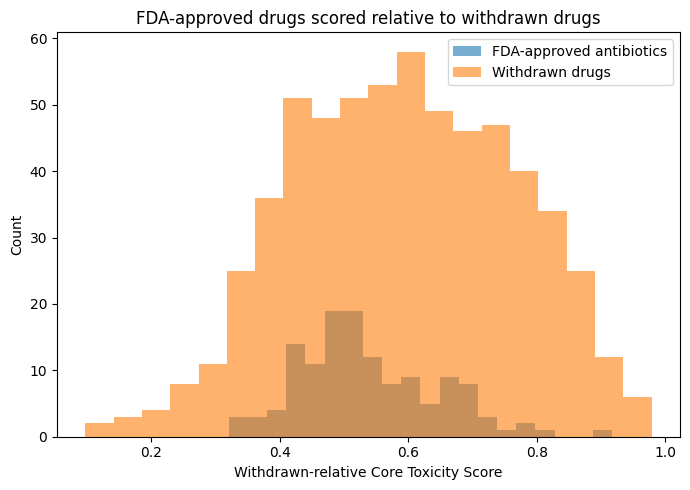

In [152]:
plt.figure(figsize=(7, 5))

plt.hist(
    fdaWithdrawnRelativeScoreDF["WithdrawnRelativeCoreToxicityScore"].dropna(),
    bins=20,
    alpha=0.6,
    label="FDA-approved antibiotics",
)

plt.hist(
    withdrawnSelfRelativeScoreDF["WithdrawnRelativeCoreToxicityScore"].dropna(),
    bins=20,
    alpha=0.6,
    label="Withdrawn drugs",
)

plt.xlabel("Withdrawn-relative Core Toxicity Score")
plt.ylabel("Count")
plt.title("FDA-approved drugs scored relative to withdrawn drugs")
plt.legend()
plt.tight_layout()
plt.show()

### Generated compounds calibrated between FDA and withdrawn drugs

In [153]:
def learnFdaWithdrawnCalibration(fdaDF, withdrawnDF, toxicityCols):
    calibration = {}

    for col in toxicityCols:
        fdaVals = fdaDF[col].dropna()
        withdrawnVals = withdrawnDF[col].dropna()

        if len(fdaVals) < 3 or len(withdrawnVals) < 3:
            continue

        fdaMedian = fdaVals.median()
        withdrawnMedian = withdrawnVals.median()
        combinedVals = pd.concat([fdaVals, withdrawnVals])

        center = 0.5 * (fdaMedian + withdrawnMedian)
        scale = robustScale(combinedVals)

        if col == "LD50_Zhu":
            higherIsMoreToxic = False
        else:
            higherIsMoreToxic = withdrawnMedian >= fdaMedian

        separation = abs(withdrawnMedian - fdaMedian) / scale

        calibration[col] = {
            "fdaMedian": fdaMedian,
            "withdrawnMedian": withdrawnMedian,
            "center": center,
            "scale": scale,
            "higherIsMoreToxic": higherIsMoreToxic,
            "separation": separation,
        }

    return calibration


toxicityCalibration = learnFdaWithdrawnCalibration(
    fdaApprovedDF,
    withdrawnDF,
    toxicityCols,
)

calibrationDF = pd.DataFrame(toxicityCalibration).T
calibrationDF

,fdaMedian,withdrawnMedian,center,scale,higherIsMoreToxic,separation
AMES,0.093198,0.168905,0.131052,0.220772,True,0.342918
hERG,0.038844,0.270876,0.15486,0.399587,True,0.58068
DILI,0.860206,0.388564,0.624385,0.537744,False,0.877074
ClinTox,0.062895,0.077688,0.070292,0.138168,True,0.107064
Carcinogens_Lagunin,0.101898,0.177559,0.139729,0.186844,True,0.404944
Skin_Reaction,0.293377,0.491459,0.392418,0.32343,True,0.612441
LD50_Zhu,2.142251,2.504244,2.323248,0.557106,False,0.649773
SR-ARE,0.079441,0.10347,0.091455,0.177408,True,0.135441
SR-ATAD5,0.004143,0.00445,0.004296,0.015453,True,0.019896
SR-HSE,0.005733,0.012983,0.009358,0.024807,True,0.292249


In [154]:
def computeCalibrationWeights(calibration):
    weightDF = pd.DataFrame(calibration).T.copy()

    rawWeights = (
        weightDF["separation"]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )

    if rawWeights.sum() == 0:
        rawWeights[:] = 1.0

    weights = rawWeights / rawWeights.sum()
    return weights.to_dict()


toxicityWeights = computeCalibrationWeights(toxicityCalibration)

toxicityWeightDF = pd.DataFrame(
    {
        "endpoint": list(toxicityWeights.keys()),
        "weight": list(toxicityWeights.values()),
    }
).sort_values("weight", ascending=False)

toxicityWeightDF

,endpoint,weight
2,DILI,0.148181
6,LD50_Zhu,0.109779
5,Skin_Reaction,0.103472
1,hERG,0.098106
13,NR-AR,0.088356
4,Carcinogens_Lagunin,0.068415
0,AMES,0.057936
15,NR-Aromatase,0.057884
10,SR-MMP,0.053502
9,SR-HSE,0.049375


In [155]:
def addGeneratedCalibratedToxicity(DF, calibration):
    DF = DF.copy()

    for col, params in calibration.items():
        x = DF[col].astype(float)
        center = params["center"]
        scale = params["scale"]

        if params["higherIsMoreToxic"]:
            risk = sigmoid((x - center) / scale)
        else:
            risk = sigmoid((center - x) / scale)

        DF[f"{col}_GeneratedCalibratedRisk"] = risk.clip(1e-6, 1.0 - 1e-6)
        DF[f"{col}_GeneratedCalibratedSafety"] = (
            1.0 - DF[f"{col}_GeneratedCalibratedRisk"]
        )

    safetyCols = [
        f"{col}_GeneratedCalibratedSafety"
        for col in calibration.keys()
    ]

    DF["ToxicitySafety"] = weightedGeoMean(
        DF,
        safetyCols,
        weightsDict=toxicityWeights,
    )

    DF["coreToxicityScore"] = 1.0 - DF["ToxicitySafety"]

    return DF

In [156]:
generatedScoreDF = addGeneratedCalibratedToxicity(
    generatedScoreDF,
    toxicityCalibration,
)

fdaApprovedScoreDF = addGeneratedCalibratedToxicity(
    fdaApprovedDF,
    toxicityCalibration,
)


withdrawnScoreDF = addGeneratedCalibratedToxicity(
    withdrawnDF,
    toxicityCalibration,
)

display(generatedScoreDF.head())

,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,NR-Aromatase_GeneratedCalibratedRisk,NR-Aromatase_GeneratedCalibratedSafety,NR-ER-LBD_GeneratedCalibratedRisk,NR-ER-LBD_GeneratedCalibratedSafety,NR-ER_GeneratedCalibratedRisk,NR-ER_GeneratedCalibratedSafety,NR-PPAR-gamma_GeneratedCalibratedRisk,NR-PPAR-gamma_GeneratedCalibratedSafety,ToxicitySafety,coreToxicityScore
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.331199,1.119903,3.136188,7.526210,0.000005,2.977075e-08,0.000731,507.182,-1.6290,...,0.530006,0.469994,0.876391,0.123609,0.190366,0.809634,0.428800,0.571200,0.416950,0.583050
1,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,4.529551,1.118626,2.337043,6.722059,0.000030,1.896448e-07,0.004602,744.417,-2.8989,...,0.596433,0.403567,0.963007,0.036993,0.059142,0.940858,0.430748,0.569252,0.379571,0.620429
2,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,4.886733,1.119159,2.693181,7.080285,0.000013,8.312178e-08,0.002027,745.425,-2.5694,...,0.774617,0.225383,0.993927,0.006073,0.115765,0.884235,0.441622,0.558378,0.300031,0.699969
3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OS(=O)(=...,4.961268,1.120693,2.764711,7.157826,0.000011,6.953035e-08,0.001719,507.267,-1.9189,...,0.549864,0.450136,0.831659,0.168341,0.161696,0.838304,0.432291,0.567709,0.359347,0.640653
4,C[S+](CC[C@H](N)C(=O)O)C[C@H]1O[C@@H](n2cnc3c(...,3.878036,1.118712,1.685360,6.070712,0.000132,8.497438e-07,0.020637,399.453,-1.9222,...,0.598044,0.401956,0.570029,0.429971,0.472521,0.527479,0.439705,0.560295,0.400654,0.599346


In [157]:
plotDF = generatedScoreDF[
    np.isfinite(generatedScoreDF["pPotency_prediction"]) &
    np.isfinite(generatedScoreDF["coreToxicityScore"])
].copy()

plotDF["potencyDes"] = plotDF["pPotency_prediction"].rank(pct=True)
plotDF["toxicityDes"] = 1 - plotDF["coreToxicityScore"].rank(pct=True)
plotDF["top20PriorityScore"] = np.sqrt(
    plotDF["potencyDes"].clip(1e-6) * plotDF["toxicityDes"].clip(1e-6)
)

top20DF = plotDF.sort_values("top20PriorityScore", ascending=False).head(20).copy()

top20PotencyCutoff = top20DF["pPotency_prediction"].min()
top20ToxicityCutoff = top20DF["coreToxicityScore"].max()

p, ps = top20DF["pPotency_prediction"], top20DF["pPotency_std"]
t = top20DF["coreToxicityScore"]
i_min, i_max = p.idxmin(), p.idxmax()

print(f"Top 20 pPotency cutoff: {top20PotencyCutoff:.3f}")
print(f"Top 20 toxicity cutoff: {top20ToxicityCutoff:.3f}")
print(f"pPotency range: {p.loc[i_min]:.3f} ± {ps.loc[i_min]:.3f}  -  {p.loc[i_max]:.3f} ± {ps.loc[i_max]:.3f}")
print(f"pIC50 range:    {p.loc[i_min]:.3f} ± {ps.loc[i_min]:.3f}  -  {p.loc[i_max]:.3f} ± {ps.loc[i_max]:.3f}")
print(f"Toxicity range: {t.min():.3f} to {t.max():.3f}")

top20Cols = [
    "SMILES", "pPotency_prediction", "pPotency_std", "pPotency_lower_95CI", "pPotency_upper_95CI",
    "coreToxicityScore", "ToxicitySafety", "potencyDes", "toxicityDes", "top20PriorityScore", "QED"
]

top20Path = os.path.join(saveDir, f"{target_organism}_potency_coreToxicity_top20_BasidalinPrecursor.csv")
top20DF[[c for c in top20Cols if c in top20DF.columns]].to_csv(top20Path, index=False)
print(f"Saved: {top20Path}")

Top 20 pPotency cutoff: 4.383
Top 20 toxicity cutoff: 0.505
pPotency range: 4.383 ± 1.119  -  4.759 ± 1.120
pIC50 range:    4.383 ± 1.119  -  4.759 ± 1.120
Toxicity range: 0.468 to 0.505
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB/BacillusAnthracis_potency_coreToxicity_top20_BasidalinPrecursor.csv


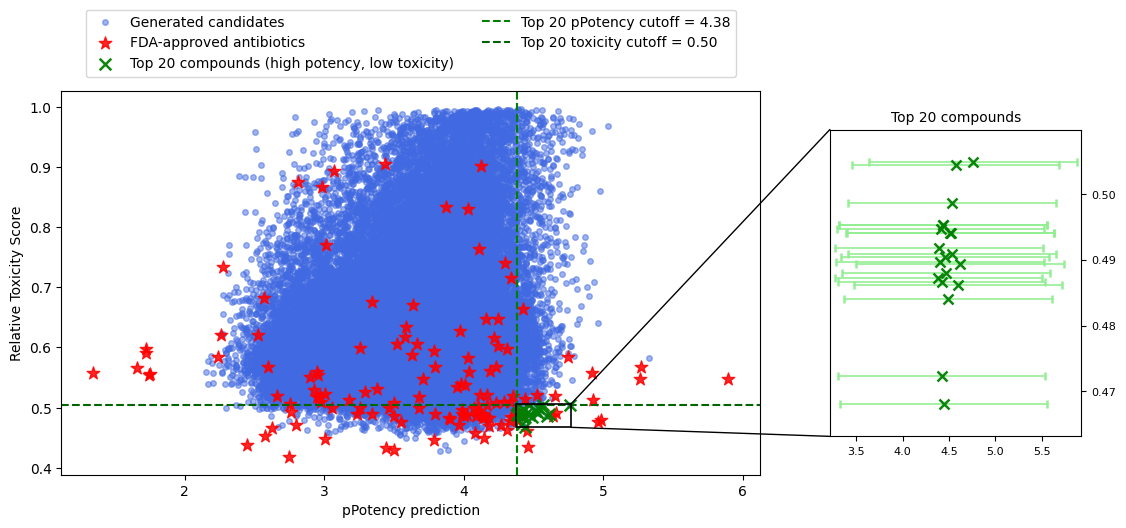

In [158]:
xDisplay = top20PotencyCutoff
yDisplay = top20ToxicityCutoff

fig, ax = plt.subplots(figsize=(10, 6))

# Main plot (no error bars)
ax.scatter(plotDF["pPotency_prediction"], plotDF["coreToxicityScore"],
           s=16, alpha=0.5, color="royalblue", label=f"Generated candidates")
ax.scatter(fdaApprovedScoreDF["pPotency_prediction"], fdaApprovedScoreDF["coreToxicityScore"],
           marker="*", s=90, alpha=0.85, color="red", label="FDA-approved antibiotics")
ax.scatter(top20DF["pPotency_prediction"], top20DF["coreToxicityScore"],
           marker="x", s=70, linewidths=1.8, alpha=0.95, color="green",
           label="Top 20 compounds (high potency, low toxicity)")

ax.axvline(xDisplay, linestyle="--", linewidth=1.5, color="green",
           label=f"Top 20 pPotency cutoff = {xDisplay:.2f}")
ax.axhline(yDisplay, linestyle="--", linewidth=1.5, color="darkgreen",
           label=f"Top 20 toxicity cutoff = {yDisplay:.2f}")

ax.set_xlabel("pPotency prediction")
ax.set_ylabel("Relative Toxicity Score")
#ax.set_title("High-potency, low-toxicity candidate prioritization")

# ---------- small box on main plot ----------
bx1 = top20DF["pPotency_prediction"].min() - 0.01
bx2 = top20DF["pPotency_prediction"].max() + 0.01
by1 = top20DF["coreToxicityScore"].min() - 0.001
by2 = top20DF["coreToxicityScore"].max() + 0.001

small_box = patches.Rectangle((bx1, by1), bx2 - bx1, by2 - by1,
                              fill=False, ec="k", lw=1.2, ls="-", zorder=6)
ax.add_patch(small_box)

# ---------- inset limits (bigger; include full error bars) ----------
x1 = (top20DF["pPotency_prediction"] - top20DF["pPotency_std"]).min() - 0.05
x2 = (top20DF["pPotency_prediction"] + top20DF["pPotency_std"]).max() + 0.05
y1 = top20DF["coreToxicityScore"].min() - 0.005
y2 = top20DF["coreToxicityScore"].max() + 0.005

axins = inset_axes(
    ax, width="36%", height="80%",
    loc="lower left", bbox_to_anchor=(1.1, 0.10, 1, 1),
    bbox_transform=ax.transAxes, borderpad=0
)

axins.errorbar(
    top20DF["pPotency_prediction"], top20DF["coreToxicityScore"],
    xerr=top20DF["pPotency_std"].values,
    fmt="x", color="green", ecolor="lightgreen",
    elinewidth=1.2, capsize=3, capthick=1.2,
    markersize=7, markeredgewidth=1.8, alpha=0.95
)
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.set_title("Top 20 compounds", fontsize=10)
axins.tick_params(labelsize=8)
axins.yaxis.tick_right()
axins.yaxis.set_label_position("right")

# ---------- connect: right corners of small box -> left corners of inset ----------
con_top = ConnectionPatch(
    xyA=(bx2, by2), coordsA=ax.transData,      # main: top-right
    xyB=(x1, y2),  coordsB=axins.transData,    # inset: top-left
    color="k", lw=1.0
)
con_bot = ConnectionPatch(
    xyA=(bx2, by1), coordsA=ax.transData,      # main: bottom-right
    xyB=(x1, y1),  coordsB=axins.transData,    # inset: bottom-left
    color="k", lw=1.0
)

fig.add_artist(con_top)
fig.add_artist(con_bot)

ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0, 0.78, 0.90])

plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_candidates.svg"),format="svg", dpi=600, bbox_inches="tight")
plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_candidates.png"),format="png", dpi=600, bbox_inches="tight")
plt.show()

### Plot: `high pPotency`, `low Toxicity Score`, `high ADME feasibility`

In [159]:
# =========================================================
# Compute ADMEFeasibility
# =========================================================

admeHigherIsBetterCols = [
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
]

admeLowerIsBetterCols = [
    "Pgp_Broccatelli",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Veith",
    "CYP2D6_Veith",
    "CYP3A4_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP3A4_Substrate_CarbonMangels",
]

admeHigherIsBetterCols = [
    col for col in admeHigherIsBetterCols
    if col in generatedScoreDF.columns and col in fdaApprovedDF.columns
]

admeLowerIsBetterCols = [
    col for col in admeLowerIsBetterCols
    if col in generatedScoreDF.columns and col in fdaApprovedDF.columns
]

admeCols = admeHigherIsBetterCols + admeLowerIsBetterCols

for DF in [generatedScoreDF, fdaApprovedScoreDF, fdaApprovedDF]:
    for col in admeCols:
        if col in DF.columns:
            DF[col] = pd.to_numeric(DF[col], errors="coerce")


def endpointDesirability(values, referenceValues, higherIsBetter=True, eps=1e-6):
    referenceValues = pd.Series(referenceValues).dropna().astype(float).sort_values().values
    values = pd.Series(values).astype(float)

    if len(referenceValues) == 0:
        return pd.Series(np.nan, index=values.index)

    percentiles = np.searchsorted(referenceValues, values.values, side="right") / len(referenceValues)

    if higherIsBetter:
        desirability = percentiles
    else:
        desirability = 1.0 - percentiles

    return pd.Series(desirability, index=values.index).clip(eps, 1.0)


def addADMEFeasibility(DF, referenceDF, admeHigherIsBetterCols, admeLowerIsBetterCols):
    DF = DF.copy()
    admeDesCols = []

    for col in admeHigherIsBetterCols:
        desCol = f"{col}_ADMESuitability"
        DF[desCol] = endpointDesirability(
            DF[col],
            referenceDF[col],
            higherIsBetter=True,
        )
        admeDesCols.append(desCol)

    for col in admeLowerIsBetterCols:
        desCol = f"{col}_ADMESuitability"
        DF[desCol] = endpointDesirability(
            DF[col],
            referenceDF[col],
            higherIsBetter=False,
        )
        admeDesCols.append(desCol)

    DF["ADMEFeasibility"] = np.exp(
        np.nanmean(np.log(DF[admeDesCols].clip(1e-6, 1.0)), axis=1)
    )

    return DF


generatedScoreDF = addADMEFeasibility(
    generatedScoreDF,
    fdaApprovedDF,
    admeHigherIsBetterCols,
    admeLowerIsBetterCols,
)

fdaApprovedScoreDF = addADMEFeasibility(
    fdaApprovedScoreDF,
    fdaApprovedDF,
    admeHigherIsBetterCols,
    admeLowerIsBetterCols,
)

print("ADMEFeasibility added.")
print(generatedScoreDF["ADMEFeasibility"].describe())

ADMEFeasibility added.
count    58966.000000
mean         0.436688
std          0.206543
min          0.000852
25%          0.286515
50%          0.445239
75%          0.601995
max          0.906100
Name: ADMEFeasibility, dtype: float64


In [160]:
plot3DDF = generatedScoreDF.copy()
plot3DDF = plot3DDF[
    np.isfinite(plot3DDF["pPotency_prediction"]) &
    np.isfinite(plot3DDF["coreToxicityScore"]) &
    np.isfinite(plot3DDF["ADMEFeasibility"])
].copy()

plot3DDF["potencyDes"]  = plot3DDF["pPotency_prediction"].rank(pct=True)          # higher better
plot3DDF["toxicityDes"] = 1 - plot3DDF["coreToxicityScore"].rank(pct=True)        # lower better
plot3DDF["admeDes"]     = plot3DDF["ADMEFeasibility"].rank(pct=True)               # higher better

plot3DDF["top20PriorityScore3D"] = (
    plot3DDF["potencyDes"].clip(1e-6) *
    plot3DDF["toxicityDes"].clip(1e-6) *
    plot3DDF["admeDes"].clip(1e-6)
) ** (1/3)

top20_ADMET = plot3DDF.sort_values("top20PriorityScore3D", ascending=False).head(20).copy()
top20_ADMET["Top20Rank_3D"] = range(1, len(top20_ADMET) + 1)

top20PotencyCutoff3D  = top20_ADMET["pPotency_prediction"].min()
top20ToxicityCutoff3D = top20_ADMET["coreToxicityScore"].max()
top20AdmeCutoff3D     = top20_ADMET["ADMEFeasibility"].min()

p, ps = top20_ADMET["pPotency_prediction"], top20_ADMET["pPotency_std"]
t, a  = top20_ADMET["coreToxicityScore"], top20_ADMET["ADMEFeasibility"]
i_min, i_max = p.idxmin(), p.idxmax()

print(f"Top 20 pPotency cutoff: {top20PotencyCutoff3D:.3f}")
print(f"Top 20 toxicity cutoff: {top20ToxicityCutoff3D:.3f}")
print(f"Top 20 ADME feasibility cutoff: {top20AdmeCutoff3D:.3f}\n")
print(f"pPotency range: {p.loc[i_min]:.3f} ± {ps.loc[i_min]:.3f}  -  {p.loc[i_max]:.3f} ± {ps.loc[i_max]:.3f}")
print(f"pIC50 range:    {p.loc[i_min]:.3f} ± {ps.loc[i_min]:.3f}  -  {p.loc[i_max]:.3f} ± {ps.loc[i_max]:.3f}")
print(f"Toxicity range: {t.min():.3f} to {t.max():.3f}")
print(f"ADME range:     {a.min():.3f} to {a.max():.3f}")

top20_3D_cols = [
    "Top20Rank_3D", "SMILES", "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI", "coreToxicityScore",
    "ADMEFeasibility", "ToxicitySafety", "top20PriorityScore3D", "QED"
]

admetTop20Path = os.path.join(saveDir, f"{target_organism}_potency_coreToxicity_adme_top20_BasidalinPrecursor.csv")
top20_ADMET[[c for c in top20_3D_cols if c in top20_ADMET.columns]].to_csv(admetTop20Path, index=False)
print(f"\nSaved: {admetTop20Path}")

Top 20 pPotency cutoff: 4.150
Top 20 toxicity cutoff: 0.530
Top 20 ADME feasibility cutoff: 0.714

pPotency range: 4.150 ± 1.118  -  4.365 ± 1.119
pIC50 range:    4.150 ± 1.118  -  4.365 ± 1.119
Toxicity range: 0.490 to 0.530
ADME range:     0.714 to 0.853

Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB/BacillusAnthracis_potency_coreToxicity_adme_top20_BasidalinPrecursor.csv


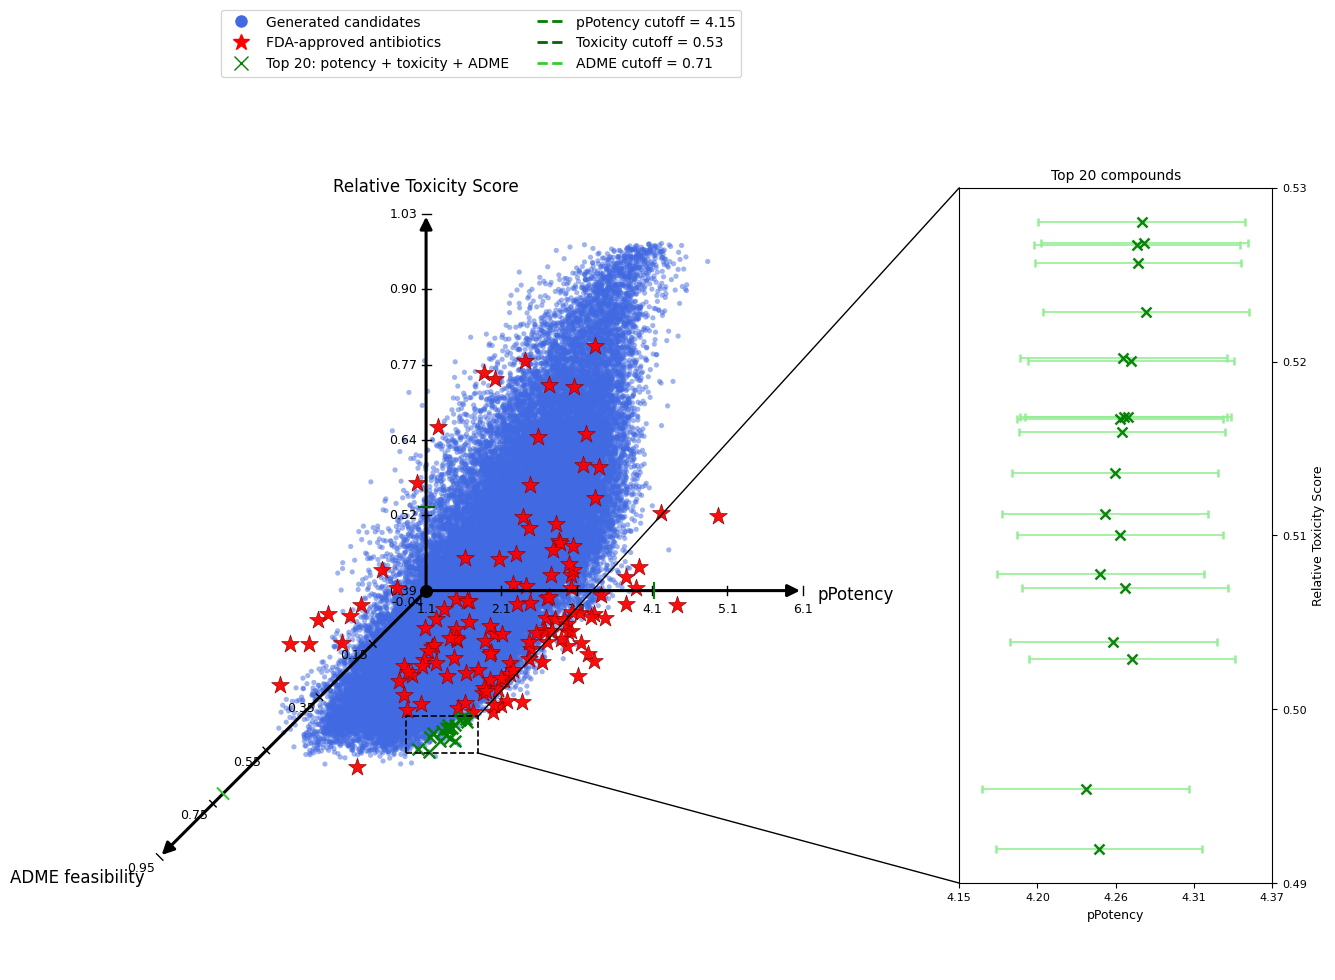

In [161]:
xCol, yCol, zCol = "pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"
cols = [xCol, yCol, zCol]

allPlotDF = plot3DDF[cols][np.isfinite(plot3DDF[cols]).all(axis=1)].copy()
refPlotDF = (
    fdaApprovedScoreDF[cols][np.isfinite(fdaApprovedScoreDF[cols]).all(axis=1)].copy()
    if set(cols).issubset(fdaApprovedScoreDF.columns) else pd.DataFrame(columns=cols)
)
topPlotDF = top20_ADMET[cols][np.isfinite(top20_ADMET[cols]).all(axis=1)].copy()

def paddedRange(arr, frac=0.05):
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    pad = (hi - lo) * frac if (hi - lo) > 0 else 1.0
    return lo - pad, hi + pad

combined = pd.concat([allPlotDF, refPlotDF, topPlotDF], ignore_index=True)
(X_MIN, X_MAX), (Y_MIN, Y_MAX), (Z_MIN, Z_MAX) = [paddedRange(combined[c]) for c in cols]

O  = np.zeros(2)
UX = np.array([1.0, 0.0])
UY = np.array([0.0, 1.0])
UZ = np.array([math.cos(math.radians(225)), math.sin(math.radians(225))])

def project(x, y, z):
    return O + ((x - X_MIN) / (X_MAX - X_MIN)) * UX + ((y - Y_MIN) / (Y_MAX - Y_MIN)) * UY + ((z - Z_MIN) / (Z_MAX - Z_MIN)) * UZ

def projectDF(df):
    if df.empty: return np.array([]), np.array([])
    pts = np.array([project(r[xCol], r[yCol], r[zCol]) for _, r in df.iterrows()])
    return pts[:, 0], pts[:, 1]

allCX, allCY = projectDF(allPlotDF)
refCX, refCY = projectDF(refPlotDF)
topCX, topCY = projectDF(topPlotDF)

TIP_X, TIP_Y, TIP_Z = O + UX, O + UY, O + UZ

fig, ax = plt.subplots(figsize=(12, 11), facecolor="white")
ax.set(facecolor="white", aspect="equal")
ax.axis("off")

for tip in [TIP_X, TIP_Y, TIP_Z]:
    ax.annotate("", xy=tip, xytext=O, zorder=5,
                arrowprops=dict(arrowstyle="-|>", color="black", lw=2.2, mutation_scale=18))
ax.scatter(*O, s=70, c="black", zorder=6)

def drawTicks(unitVec, valMin, valMax, offset, nTicks=5, fmt="{:.2f}"):
    perp = np.array([unitVec[1], -unitVec[0]])
    perp /= np.linalg.norm(perp)
    for i in range(nTicks + 1):
        t, pos = i / nTicks, O + (i / nTicks) * unitVec
        ax.plot(*zip(pos - 0.012 * perp, pos + 0.012 * perp), color="black", lw=1.0, zorder=5)
        ax.text(*(pos + offset), fmt.format(valMin + t * (valMax - valMin)), fontsize=9, ha="center", va="center")

drawTicks(UX, X_MIN, X_MAX, np.array([0.00, -0.05]), fmt="{:.1f}")
drawTicks(UY, Y_MIN, Y_MAX, np.array([-0.06, 0.00]))
drawTicks(UZ, Z_MIN, Z_MAX, np.array([-0.05, -0.03]))

ax.scatter(allCX, allCY, color="royalblue", s=14, alpha=0.5, edgecolors="none", zorder=2)
if len(refCX):
    ax.scatter(refCX, refCY, color="red", s=180, alpha=0.95, marker="*", edgecolors="darkred", linewidths=0.5, zorder=4)
ax.scatter(topCX, topCY, color="green", s=70, alpha=0.95, marker="x", linewidths=1.8, zorder=5)

xCut, yCut, zCut = topPlotDF[xCol].min(), topPlotDF[yCol].max(), topPlotDF[zCol].min()
tickLen = 0.02
UZ_perp = np.array([-UZ[1], UZ[0]])
UZ_perp /= np.linalg.norm(UZ_perp)
zPt = O + ((zCut - Z_MIN) / (Z_MAX - Z_MIN)) * UZ

for pt, color, dx, dy in [
    (O + ((xCut - X_MIN) / (X_MAX - X_MIN)) * UX, "green", 0, tickLen),
    (O + ((yCut - Y_MIN) / (Y_MAX - Y_MIN)) * UY, "darkgreen", tickLen, 0),
]:
    ax.plot([pt[0] - dx, pt[0] + dx], [pt[1] - dy, pt[1] + dy], color=color, lw=1.5, zorder=5)

ax.plot([zPt[0] - tickLen * UZ_perp[0], zPt[0] + tickLen * UZ_perp[0]],
        [zPt[1] - tickLen * UZ_perp[1], zPt[1] + tickLen * UZ_perp[1]],
        color="limegreen", lw=1.5, zorder=5)

ax.text(TIP_X[0] + 0.04, TIP_X[1] - 0.01, "pPotency", fontsize=12, ha="left", va="center")
ax.text(TIP_Y[0], TIP_Y[1] + 0.05, "Relative Toxicity Score", fontsize=12, ha="center", va="bottom")
ax.text(TIP_Z[0] - 0.04, TIP_Z[1] - 0.03, "ADME feasibility", fontsize=12, ha="right", va="top")

allPx = np.concatenate([allCX, refCX, topCX, [TIP_X[0], TIP_Y[0], TIP_Z[0]]])
allPy = np.concatenate([allCY, refCY, topCY, [TIP_X[1], TIP_Y[1], TIP_Z[1]]])
ax.set_xlim(allPx.min() - 0.3, allPx.max() + 0.3)
ax.set_ylim(allPy.min() - 0.3, allPy.max() + 0.3)

# ---- small box on main plot (tight around top20 points) ----
bx1, bx2 = topCX.min() - 0.03, topCX.max() + 0.03
by1, by2 = topCY.min() - 0.003, topCY.max() + 0.003
small_box = patches.Rectangle((bx1, by1), bx2 - bx1, by2 - by1,
                              fill=False, ec="k", lw=1.2, ls="--", zorder=6)
ax.add_patch(small_box)

# ---- inset outside right: bigger limits (include full projected ±1σ) ----
axins = inset_axes(
    ax, width="36%", height="80%",
    loc="lower left",
    bbox_to_anchor=(1.05, 0.10, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0
)

xerr_proj = np.abs(top20_ADMET["pPotency_std"].values / (X_MAX - X_MIN) * UX[0])

x1 = np.min(topCX - xerr_proj) - 0.05
x2 = np.max(topCX + xerr_proj) + 0.05
y1 = topCY.min() - 0.005
y2 = topCY.max() + 0.005

axins.errorbar(
    topCX, topCY, xerr=xerr_proj,
    fmt="x", color="green", ecolor="lightgreen",
    elinewidth=1.2, capsize=3, capthick=1.2,
    markersize=7, markeredgewidth=1.8, alpha=0.95
)
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

# inset ticks shown in original data scale
xt = np.linspace(x1, x2, 5)
xt_labels = np.linspace(top20_ADMET[xCol].min(), top20_ADMET[xCol].max(), 5)
axins.set_xticks(xt)
axins.set_xticklabels([f"{v:.2f}" for v in xt_labels], fontsize=8)
axins.set_xlabel("pPotency", fontsize=9)

yt = np.linspace(y1, y2, 5)
yt_labels = np.linspace(top20_ADMET[yCol].min(), top20_ADMET[yCol].max(), 5)
axins.set_yticks(yt)
axins.set_yticklabels([f"{v:.2f}" for v in yt_labels], fontsize=8)
axins.yaxis.tick_right()
axins.yaxis.set_label_position("right")
axins.set_ylabel("Relative Toxicity Score", fontsize=9)
axins.set_title("Top 20 compounds", fontsize=10)

# ---- connect right corners of small box -> left corners of inset ----
con_top = ConnectionPatch(
    xyA=(bx2, by2), coordsA=ax.transData,
    xyB=(x1, y2),  coordsB=axins.transData,
    color="k", lw=1.0
)
con_bot = ConnectionPatch(
    xyA=(bx2, by1), coordsA=ax.transData,
    xyB=(x1, y1),  coordsB=axins.transData,
    color="k", lw=1.0
)
fig.add_artist(con_top)
fig.add_artist(con_bot)

handles = [
    mlines.Line2D([], [], color="royalblue", marker="o", linestyle="None", markersize=8, label="Generated candidates"),
    mlines.Line2D([], [], color="red", marker="*", linestyle="None", markersize=12, label="FDA-approved antibiotics"),
    mlines.Line2D([], [], color="green", marker="x", linestyle="None", markersize=10, label="Top 20: potency + toxicity + ADME"),
    mlines.Line2D([], [], color="green", linestyle="--", lw=2, label=f"pPotency cutoff = {xCut:.2f}"),
    mlines.Line2D([], [], color="darkgreen", linestyle="--", lw=2, label=f"Toxicity cutoff = {yCut:.2f}"),
    mlines.Line2D([], [], color="limegreen", linestyle="--", lw=2, label=f"ADME cutoff = {zCut:.2f}"),
]
ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)

plt.tight_layout(rect=[0, 0, 0.78, 0.90])
plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_ADME.svg"),format="svg", dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_ADME.png"),format="png", dpi=600, bbox_inches="tight", facecolor="white")
plt.show()

# Pareto optimization

In [163]:
# ---------------------------------------------------------
# Helper functions
# ---------------------------------------------------------
def nondominatedMask(values):
    """
    values: numpy array of shape (nSamples, nObjectives)
    All objectives are assumed to be maximize.
    """
    nRows = values.shape[0]
    isNondominated = np.ones(nRows, dtype=bool)

    for i in range(nRows):
        if not isNondominated[i]:
            continue

        for j in range(nRows):
            if i == j:
                continue

            jDominatesI = np.all(values[j] >= values[i]) and np.any(values[j] > values[i])
            if jDominatesI:
                isNondominated[i] = False
                break

    return isNondominated


def crowdingDistance(DF, objectiveCols):
    """
    NSGA-II style crowding distance.
    Larger value means more isolated / diverse point on the front.
    """
    if len(DF) == 0:
        return pd.Series(dtype=float)

    if len(DF) <= 2:
        return pd.Series(np.inf, index=DF.index)

    X = DF[objectiveCols].to_numpy(dtype=float)

    colMin = np.nanmin(X, axis=0)
    colMax = np.nanmax(X, axis=0)
    denom = np.where((colMax - colMin) > 0, (colMax - colMin), 1.0)
    Xnorm = (X - colMin) / denom

    dist = np.zeros(len(DF), dtype=float)

    for k in range(Xnorm.shape[1]):
        order = np.argsort(Xnorm[:, k])

        dist[order[0]] = np.inf
        dist[order[-1]] = np.inf

        for r in range(1, len(order) - 1):
            if np.isfinite(dist[order[r]]):
                dist[order[r]] += Xnorm[order[r + 1], k] - Xnorm[order[r - 1], k]

    return pd.Series(dist, index=DF.index)


def assignParetoFronts(DF, objectiveCols, maxFronts=None):
    """
    Repeatedly peel off non-dominated fronts.
    Returns a copy with ParetoFront and ParetoCrowdingDistance.
    """
    workingDF = DF.copy()
    frontList = []
    frontNumber = 1

    while len(workingDF) > 0:
        if maxFronts is not None and frontNumber > maxFronts:
            break

        values = workingDF[objectiveCols].to_numpy(dtype=float)
        frontMask = nondominatedMask(values)

        frontDF = workingDF.loc[frontMask].copy()
        frontDF["ParetoFront"] = frontNumber
        frontDF["ParetoCrowdingDistance"] = crowdingDistance(frontDF, objectiveCols)

        frontList.append(frontDF)
        workingDF = workingDF.loc[~frontMask].copy()
        frontNumber += 1

    if len(frontList) == 0:
        return DF.iloc[0:0].copy()

    return pd.concat(frontList, axis=0).copy()


def overlapSummary(weightedDF, paretoDF, smilesCol="SMILES"):
    weightedSet = set(weightedDF[smilesCol].dropna().astype(str))
    paretoSet = set(paretoDF[smilesCol].dropna().astype(str))

    sharedSet = weightedSet & paretoSet
    weightedOnlySet = weightedSet - paretoSet
    paretoOnlySet = paretoSet - weightedSet

    summaryDF = pd.DataFrame({
        "Metric": [
            "WeightedTop20Count",
            "ParetoTop20Count",
            "SharedCount",
            "WeightedOnlyCount",
            "ParetoOnlyCount",
        ],
        "Value": [
            len(weightedSet),
            len(paretoSet),
            len(sharedSet),
            len(weightedOnlySet),
            len(paretoOnlySet),
        ]
    })

    sharedSmilesDF = pd.DataFrame({"SMILES": sorted(sharedSet)})
    weightedOnlySmilesDF = pd.DataFrame({"SMILES": sorted(weightedOnlySet)})
    paretoOnlySmilesDF = pd.DataFrame({"SMILES": sorted(paretoOnlySet)})

    return summaryDF, sharedSmilesDF, weightedOnlySmilesDF, paretoOnlySmilesDF

In [83]:
# =========================================================
# 2D Pareto selection
# Objectives:
#   maximize pPotency_prediction
#   maximize ToxicitySafety
# =========================================================

pareto2DPoolDF = generatedScoreDF.copy()

pareto2DRequiredCols = [
    "SMILES",
    "pPotency_prediction",
    "pPotency_std",
    "pPotency_lower_95CI",
    "pPotency_upper_95CI",
    "coreToxicityScore",
    "ToxicitySafety",
    "QED",
]

pareto2DPoolDF = pareto2DPoolDF[
    pareto2DPoolDF[pareto2DRequiredCols].notna().all(axis=1)
].copy()

# Keep everything as maximize objectives
pareto2DPoolDF["ParetoPotency2D"] = pareto2DPoolDF["pPotency_prediction"]
pareto2DPoolDF["ParetoToxicitySafety2D"] = pareto2DPoolDF["ToxicitySafety"]

pareto2DObjectiveCols = ["ParetoPotency2D", "ParetoToxicitySafety2D"]

pareto2DRankedDF = assignParetoFronts(
    pareto2DPoolDF,
    objectiveCols=pareto2DObjectiveCols,
    maxFronts=None,
)

paretoTop20_2D_DF = pareto2DRankedDF.sort_values(
    by=[
        "ParetoFront",
        "ParetoCrowdingDistance",
        "pPotency_prediction",
        "ToxicitySafety",
    ],
    ascending=[True, False, False, False]
).head(20).copy()

paretoTop20_2D_DF["Top20Rank_Pareto2D"] = np.arange(1, len(paretoTop20_2D_DF) + 1)
paretoTop20_2D_DF

KeyboardInterrupt: 

In [167]:
#paretoTop20_2D_DF = paretoTop20_2D_DF.rename(columns={'smiles': 'SMILES'})
paretoTop20_2D_cols = [
    "Top20Rank_Pareto2D",
    "SMILES",
    "ParetoFront",
    "ParetoCrowdingDistance",
    "pPotency_prediction",
    "pPotency_std",
    "pPotency_lower_95CI",
    "pPotency_upper_95CI",
    "coreToxicityScore",
    "ToxicitySafety",
    "QED",
]

paretoTop20_2D_DF[paretoTop20_2D_cols]
paretoTop20_2D_DF

,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,CYP3A4_Veith_ADMESuitability,CYP2C9_Substrate_CarbonMangels_ADMESuitability,CYP2D6_Substrate_CarbonMangels_ADMESuitability,CYP3A4_Substrate_CarbonMangels_ADMESuitability,ADMEFeasibility,ParetoPotency2D,ParetoToxicitySafety2D,ParetoFront,ParetoCrowdingDistance,Top20Rank_Pareto2D
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.331199,1.119903,3.136188,7.526210,0.000005,2.977075e-08,0.000731,507.182,-1.6290,...,0.848485,0.765152,0.628788,0.931818,0.233377,5.331199,0.416950,1,inf,1
7514,O=C1CCC=C(O)CC1,3.830624,1.118907,1.637566,6.023683,0.000148,9.469289e-07,0.023037,126.155,1.5714,...,0.977273,0.242424,0.000001,0.431818,0.220277,3.830624,0.572838,1,inf,2
36350,Nc1cc(C(=O)O)cc(C(O)=C2C=CC(=O)O2)c1,4.773726,1.118831,2.580818,6.966634,0.000017,1.079856e-07,0.002625,247.206,1.3066,...,0.696970,0.689394,0.977273,1.000000,0.494016,4.773726,0.454576,1,0.882929,3
40247,C=C(O)C[C@H](CCCNC(N)=[NH2+])C(=O)O,4.759276,1.119691,2.564681,6.953871,0.000017,1.112063e-07,0.002725,216.261,-1.4074,...,0.977273,0.924242,0.166667,1.000000,0.467212,4.759276,0.495173,1,0.464937,4
24639,CC1CC=C(O)CCC1=O,4.001836,1.118423,1.809727,6.193945,0.000100,6.398155e-07,0.015498,140.182,1.8174,...,0.916667,0.106061,0.000001,0.371212,0.162859,4.001836,0.555544,1,0.267572,5
47921,C=C1C[C@@H]2C(O)OC(=C[C@@H](CC)C(N)(O)O)[C@H]2O1,4.615132,1.121319,2.417346,6.812918,0.000024,1.538444e-07,0.003825,257.286,-0.2390,...,0.931818,0.871212,0.113636,0.901515,0.561227,4.615132,0.510578,1,0.228301,6
12304,O=C1CC=C(O)CC1,3.889892,1.118682,1.697275,6.082509,0.000129,8.269715e-07,0.020078,112.128,1.1813,...,0.977273,0.340909,0.022727,0.462121,0.499315,3.889892,0.570597,1,0.225035,7
57519,C[C@@H]1C=C(O)CCC(O)=N[C@@H](C)C(=O)NC1,4.087583,1.118516,1.895291,6.279875,0.000082,5.249582e-07,0.012726,226.276,1.3194,...,0.962121,0.666667,0.348485,0.590909,0.668704,4.087583,0.549423,1,0.221088,8
42660,C=C(O)C[C@@H](C(=O)O)C(C)CCNC(N)=[NH2+],4.489174,1.118883,2.296163,6.682185,0.000032,2.078810e-07,0.005056,230.288,-1.1614,...,0.977273,0.848485,0.113636,1.000000,0.469953,4.489174,0.516023,1,0.217953,9
41713,CCCC[C@@H](C(=O)O)[C@@H](O)C(O)CCNC(N)=[NH2+],4.442687,1.118836,2.249767,6.635606,0.000036,2.314164e-07,0.005626,262.330,-2.3473,...,0.962121,0.818182,0.022727,1.000000,0.332771,4.442687,0.531850,1,0.206204,10


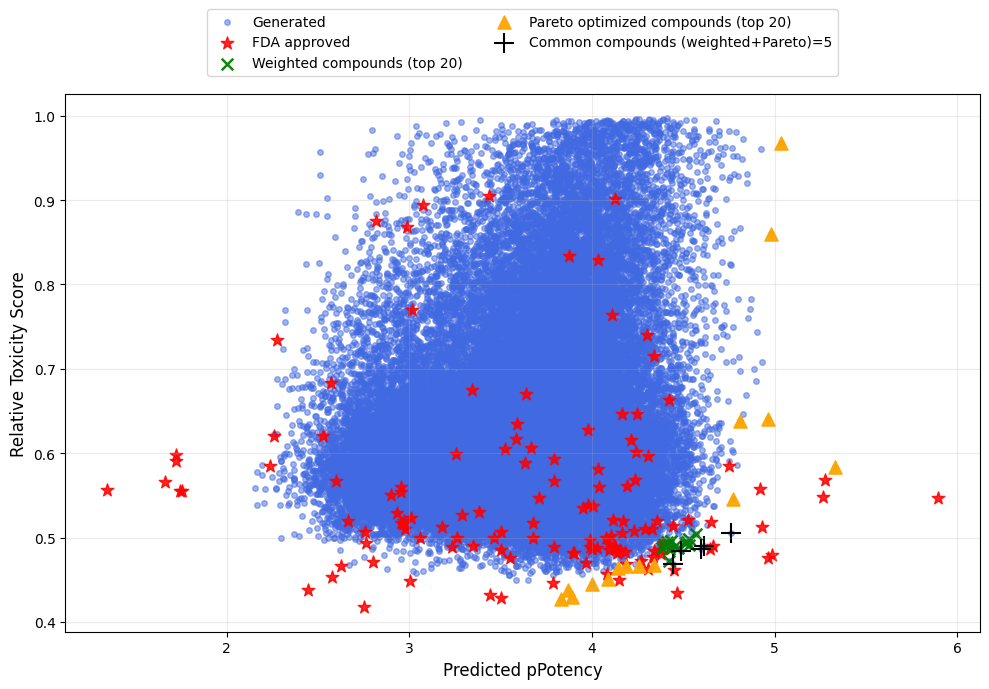

In [177]:
# =========================================================
# 2D comparison plot
# x = pPotency_prediction
# y = coreToxicityScore  (lower is better)
# =========================================================

generatedPlotDF = generatedScoreDF.copy()
fdaPlotDF = fdaApprovedScoreDF.copy()
weighted2DPlotDF = top20DF.copy()
pareto2DPlotDF = paretoTop20_2D_DF.copy()

plotCols = ["SMILES", "pPotency_prediction", "coreToxicityScore"]

generatedPlotDF = generatedPlotDF[generatedPlotDF[plotCols].notna().all(axis=1)].copy()
fdaPlotDF = fdaPlotDF[fdaPlotDF[plotCols].notna().all(axis=1)].copy()
weighted2DPlotDF = weighted2DPlotDF[weighted2DPlotDF[plotCols].notna().all(axis=1)].copy()
pareto2DPlotDF = pareto2DPlotDF[pareto2DPlotDF[plotCols].notna().all(axis=1)].copy()

weighted2DSmiles = set(weighted2DPlotDF["SMILES"].astype(str))
pareto2DSmiles = set(pareto2DPlotDF["SMILES"].astype(str))
shared2DSmiles = weighted2DSmiles & pareto2DSmiles

shared2DPlotDF = generatedPlotDF[
    generatedPlotDF["SMILES"].astype(str).isin(shared2DSmiles)
].copy()

weightedOnly2DPlotDF = weighted2DPlotDF[
    ~weighted2DPlotDF["SMILES"].astype(str).isin(shared2DSmiles)
].copy()

paretoOnly2DPlotDF = pareto2DPlotDF[
    ~pareto2DPlotDF["SMILES"].astype(str).isin(shared2DSmiles)
].copy()

generatedCount = len(generatedPlotDF)
fdaCount = len(fdaPlotDF)
weightedCount = len(weighted2DPlotDF)
paretoCount = len(pareto2DPlotDF)
sharedCount = len(shared2DPlotDF)

plt.figure(figsize=(10, 7))

# Full generated set
plt.scatter(
    generatedPlotDF["pPotency_prediction"],
    generatedPlotDF["coreToxicityScore"],
    s=16, alpha=0.5, color="royalblue",
    label=f"Generated"
)

# FDA approved reference
plt.scatter(
    fdaPlotDF["pPotency_prediction"],
    fdaPlotDF["coreToxicityScore"],
    marker="*", s=90, alpha=0.85, color="red",
    label=f"FDA approved"
)

# Weighted-only top 20
plt.scatter(
    weightedOnly2DPlotDF["pPotency_prediction"],
    weightedOnly2DPlotDF["coreToxicityScore"],
    marker="x", s=70, linewidths=1.8, alpha=0.95, color="green",
    label=f"Weighted compounds (top 20)"
)

# Pareto-only top 20
plt.scatter(
    paretoOnly2DPlotDF["pPotency_prediction"],
    paretoOnly2DPlotDF["coreToxicityScore"],
    alpha=0.95,marker="^",s=90,color="orange",
    label=f"Pareto optimized compounds (top 20)"
)

# Shared compounds
plt.scatter(
    shared2DPlotDF["pPotency_prediction"],
    shared2DPlotDF["coreToxicityScore"],
    alpha=1.00,marker="+",s=200, color="k",
    label=f"Common compounds (weighted+Pareto)={sharedCount}"
)

plt.xlabel("Predicted pPotency", fontsize=12)
plt.ylabel("Relative Toxicity Score", fontsize=12)
'''
plt.title(
    f"{target_organism}: 2D comparison of weighted vs Pareto selection\n"
    f"Weighted top20 = {weightedCount}, Pareto top20 = {paretoCount}, Shared = {sharedCount}",
    fontsize=13)
'''
plt.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [180]:
# =========================================================
# Explicit comparison with current weighted selections
# Keep comparisons separate for 2D and 3D
# =========================================================
# ---------- 2D comparison ----------
comparisonSummary2D_DF, shared2D_DF, weightedOnly2D_DF, paretoOnly2D_DF = overlapSummary(
    weightedDF=top20DF,
    paretoDF=paretoTop20_2D_DF,
    smilesCol="SMILES",
)

print("\nWeighted vs Pareto overlap summary")
display(comparisonSummary2D_DF)

print("\nShared compounds:")
display(shared2D_DF)

print("\nWeighted-only compounds:")
display(weightedOnly2D_DF)

print("\nPareto-only compounds:")
display(paretoOnly2D_DF)


Weighted vs Pareto overlap summary


,Metric,Value
0,WeightedTop20Count,20
1,ParetoTop20Count,20
2,SharedCount,5
3,WeightedOnlyCount,15
4,ParetoOnlyCount,15



Shared compounds:


,SMILES
0,C=C(O)C[C@@H](C(=O)O)C(C)CCNC(N)=[NH2+]
1,C=C(O)C[C@H](CCCNC(N)=[NH2+])C(=O)O
2,C=C1C[C@@H]2C(O)OC(=C[C@@H](CC)C(N)(O)O)[C@H]2O1
3,CCCC[C@@H](C(=O)O)[C@@H](O)C(O)CCNC(N)=[NH2+]
4,NC(=[NH2+])NCCC(O)(O)CCC(=O)O



Weighted-only compounds:


,SMILES
0,C=C(O)C(=O)[C@@H](C(=O)O)C(C)CCNC(N)=[NH2+]
1,C=C(O)C[C@H](CC(=C)CNC(N)=[NH2+])C(=O)O
2,C=C(O)C[C@H](CC(CC)CNC(N)=[NH2+])C(=O)O
3,CCCCC(CC(=O)O)C(O)=CCNC(N)=[NH2+]
4,CCCC[C@@H](C(=O)O)[C@@H](OC)C(O)=CCNC(N)=[NH2+]
5,CCCC[C@@H](CC(O)=C(C)CNC(N)=[NH2+])C(=O)O
6,CCCC[C@@H](CO)[C@@H](O)C(O)=CCNC(N)=[NH2+]
7,CC[C@@H](CC(O)CCNC(N)=[NH2+])C(=O)O
8,CC[C@H](CO)[C@H](O)C(O)=CCNC(N)=[NH2+]
9,COc1cc(N)cc(C(O)C2C=CC(=O)O2)c1



Pareto-only compounds:


,SMILES
0,C=CCC1=CC(=O)OC1=C(C)CNC(N)=[NH2+]
1,CC1=CC(=O)CCCC1=O
2,CC1CC=C(O)CCC1=O
3,CCCC(O)[C@H](C(=O)O)C(O)C(O)=CCNC(N)=[NH2+]
4,CCCCC(C=C(O)CCC(=O)O)NC(N)=[NH2+]
5,CC[C@@H](CC(O)=CC(O)NC(N)=[NH2+])C(=O)O
6,COC12C=C(C=C3C=CC(=O)O3)C=C(N)C1O2
7,C[C@@H]1C=C(O)CCC(O)=N[C@@H](C)C(=O)NC1
8,C[C@H](C=C1C=C(CCCCc2c[nH]c(Cl)c2Cl)C(=O)O1)CN...
9,Nc1cc(C(=O)O)cc(C(O)=C2C=CC(=O)O2)c1


In [181]:
# =========================================================
# 3D Pareto selection
# Objectives:
#   maximize pPotency_prediction
#   maximize ToxicitySafety
#   maximize ADMEFeasibility
# =========================================================

pareto3DPoolDF = generatedScoreDF.copy()

pareto3DRequiredCols = [
    "SMILES",
    "pPotency_prediction",
    "pPotency_std",
    "pPotency_lower_95CI",
    "pPotency_upper_95CI",
    "coreToxicityScore",
    "ToxicitySafety",
    "ADMEFeasibility",
    "QED",
]

pareto3DPoolDF = pareto3DPoolDF[
    pareto3DPoolDF[pareto3DRequiredCols].notna().all(axis=1)
].copy()

pareto3DPoolDF["ParetoPotency3D"] = pareto3DPoolDF["pPotency_prediction"]
pareto3DPoolDF["ParetoToxicitySafety3D"] = pareto3DPoolDF["ToxicitySafety"]
pareto3DPoolDF["ParetoADME3D"] = pareto3DPoolDF["ADMEFeasibility"]

pareto3DObjectiveCols = [
    "ParetoPotency3D",
    "ParetoToxicitySafety3D",
    "ParetoADME3D",
]

pareto3DRankedDF = assignParetoFronts(
    pareto3DPoolDF,
    objectiveCols=pareto3DObjectiveCols,
    maxFronts=None,
)

paretoTop20_3D_DF = pareto3DRankedDF.sort_values(
    by=[
        "ParetoFront",
        "ParetoCrowdingDistance",
        "pPotency_prediction",
        "ToxicitySafety",
        "ADMEFeasibility",
    ],
    ascending=[True, False, False, False, False]
).head(20).copy()

paretoTop20_3D_DF["Top20Rank_Pareto3D"] = np.arange(1, len(paretoTop20_3D_DF) + 1)

paretoTop20_3D_cols = [
    "Top20Rank_Pareto3D",
    "SMILES",
    "ParetoFront",
    "ParetoCrowdingDistance",
    "pPotency_prediction",
    "pPotency_std",
    "pPotency_lower_95CI",
    "pPotency_upper_95CI",
    "coreToxicityScore",
    "ToxicitySafety",
    "ADMEFeasibility",
    "QED",
]

paretoTop20_3D_DF[paretoTop20_3D_cols]

,Top20Rank_Pareto3D,SMILES,ParetoFront,ParetoCrowdingDistance,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,coreToxicityScore,ToxicitySafety,ADMEFeasibility,QED
0,1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,1,inf,5.331199,1.119903,3.136188,7.526210,0.583050,0.416950,0.233377,0.197422
36306,2,COC12C=C(C=C3C=CC(=O)O3)C=C(N)C1O2,1,inf,4.978971,1.119261,2.785220,7.172723,0.860359,0.139641,0.414347,0.555239
24639,3,CC1CC=C(O)CCC1=O,1,inf,4.001836,1.118423,1.809727,6.193945,0.444456,0.555544,0.162859,0.556859
7514,4,O=C1CCC=C(O)CC1,1,inf,3.830624,1.118907,1.637566,6.023683,0.427162,0.572838,0.220277,0.534559
14357,5,CO[C@H]1CC(CCO)(OC)OC1=O,1,inf,3.611420,1.120475,1.415289,5.807551,0.610751,0.389249,0.906100,0.614972
47548,6,CO[C@H]1C(=O)OC(=C(C)[C@@H](C)C(N)=O)[C@@H]1O,1,inf,2.754502,1.119980,0.559341,4.949663,0.515360,0.484640,0.850053,0.624227
36337,7,Nc1ccc(C(=O)O)c(C=C2C=CC(=O)O2)c1,1,0.384897,4.931947,1.119266,2.738186,7.125708,0.708563,0.291437,0.337532,0.593072
45513,8,O=C1C=CC(=Cc2ccc(O)cc2C(=O)O)O1,1,0.246920,4.843934,1.119714,2.649294,7.038573,0.668598,0.331402,0.319700,0.755441
40716,9,CO[C@H]1C(=O)OC(=CC(C)NC(N)=O)[C@@H]1O,1,0.186048,2.891489,1.122021,0.692327,5.090650,0.492003,0.507997,0.832931,0.530565
42057,10,C=CC=CC[C@H]1C(=O)OC(=CCNC(N)=[NH2+])C1=O,1,0.135711,4.897261,1.119903,2.702251,7.092270,0.685841,0.314159,0.565179,0.136097


In [ ]:
# =========================================================
# 3D comparison plot
# x = pPotency_prediction
# y = coreToxicityScore  (lower is better)
# z = ADMEFeasibility    (higher is better)
# =========================================================

requiredVars = [
    "generatedScoreDF",
    "fdaApprovedScoreDF",
    "top20_ADMET",            # current weighted 3D top-20
    "paretoTop20_3D_DF",      # Pareto 3D top-20
]

for varName in requiredVars:
    if varName not in globals():
        raise NameError(f"Required variable '{varName}' is not defined in the notebook.")

generatedPlotDF = generatedScoreDF.copy()
fdaPlotDF = fdaApprovedScoreDF.copy()
weighted3DPlotDF = top20_ADMET.copy()
pareto3DPlotDF = paretoTop20_3D_DF.copy()

plotCols = ["SMILES", "pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"]

generatedPlotDF = generatedPlotDF[generatedPlotDF[plotCols].notna().all(axis=1)].copy()
fdaPlotDF = fdaPlotDF[fdaPlotDF[plotCols].notna().all(axis=1)].copy()
weighted3DPlotDF = weighted3DPlotDF[weighted3DPlotDF[plotCols].notna().all(axis=1)].copy()
pareto3DPlotDF = pareto3DPlotDF[pareto3DPlotDF[plotCols].notna().all(axis=1)].copy()

weighted3DSmiles = set(weighted3DPlotDF["SMILES"].astype(str))
pareto3DSmiles = set(pareto3DPlotDF["SMILES"].astype(str))
shared3DSmiles = weighted3DSmiles & pareto3DSmiles

shared3DPlotDF = generatedPlotDF[
    generatedPlotDF["SMILES"].astype(str).isin(shared3DSmiles)
].copy()

weightedOnly3DPlotDF = weighted3DPlotDF[
    ~weighted3DPlotDF["SMILES"].astype(str).isin(shared3DSmiles)
].copy()

paretoOnly3DPlotDF = pareto3DPlotDF[
    ~pareto3DPlotDF["SMILES"].astype(str).isin(shared3DSmiles)
].copy()

generatedCount = len(generatedPlotDF)
fdaCount = len(fdaPlotDF)
weightedCount = len(weighted3DPlotDF)
paretoCount = len(pareto3DPlotDF)
sharedCount = len(shared3DPlotDF)

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

# Full generated set
ax.scatter(
    generatedPlotDF["pPotency_prediction"],
    generatedPlotDF["coreToxicityScore"],
    generatedPlotDF["ADMEFeasibility"],
    alpha=0.20,
    marker=".",
    s=18,
    label=f"Generated (n={generatedCount})"
)

# FDA approved reference
ax.scatter(
    fdaPlotDF["pPotency_prediction"],
    fdaPlotDF["coreToxicityScore"],
    fdaPlotDF["ADMEFeasibility"],
    alpha=0.85,
    marker="*",
    s=120,
    label=f"FDA approved (n={fdaCount})"
)

# Weighted-only top 20
ax.scatter(
    weightedOnly3DPlotDF["pPotency_prediction"],
    weightedOnly3DPlotDF["coreToxicityScore"],
    weightedOnly3DPlotDF["ADMEFeasibility"],
    alpha=0.95,
    marker="s",
    s=80,
    label=f"Weighted 3D only (n={len(weightedOnly3DPlotDF)})"
)

# Pareto-only top 20
ax.scatter(
    paretoOnly3DPlotDF["pPotency_prediction"],
    paretoOnly3DPlotDF["coreToxicityScore"],
    paretoOnly3DPlotDF["ADMEFeasibility"],
    alpha=0.95,
    marker="^",
    s=90,
    label=f"Pareto 3D only (n={len(paretoOnly3DPlotDF)})"
)

# Shared compounds
ax.scatter(
    shared3DPlotDF["pPotency_prediction"],
    shared3DPlotDF["coreToxicityScore"],
    shared3DPlotDF["ADMEFeasibility"],
    alpha=1.00,
    marker="X",
    s=120,
    label=f"Shared weighted/Pareto 3D (n={sharedCount})"
)

ax.set_xlabel("Predicted pPotency", fontsize=11, labelpad=10)
ax.set_ylabel("Core Toxicity Score", fontsize=11, labelpad=10)
ax.set_zlabel("ADME Feasibility", fontsize=11, labelpad=10)

ax.set_title(
    f"{target_organism}: 3D comparison of weighted vs Pareto selection\n"
    f"Weighted top20 = {weightedCount}, Pareto top20 = {paretoCount}, Shared = {sharedCount}",
    fontsize=13,
    pad=18
)

ax.view_init(elev=24, azim=132)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ---------- 3D comparison ----------
comparisonSummary3D_DF, shared3D_DF, weightedOnly3D_DF, paretoOnly3D_DF = overlapSummary(
    weightedDF=top20_ADMET,
    paretoDF=paretoTop20_3D_DF,
    smilesCol="SMILES",
)

print("\n===== 3D Weighted vs Pareto overlap summary =====")
display(comparisonSummary3D_DF)

print("\nShared 3D compounds:")
display(shared3D_DF)

print("\nWeighted-only 3D compounds:")
display(weightedOnly3D_DF)

print("\nPareto-only 3D compounds:")
display(paretoOnly3D_DF)

In [ ]:
# =========================================================
# Optional save-out block
# =========================================================

pareto2DPath = os.path.join(
    saveDir,
    f"{target_organism}_potency_coreToxicity_top20_Pareto_BasidalinPrecursor.csv"
)

pareto3DPath = os.path.join(
    saveDir,
    f"{target_organism}_potency_coreToxicity_adme_top20_Pareto_BasidalinPrecursor.csv"
)

compare2DPath = os.path.join(
    saveDir,
    f"{target_organism}_weighted_vs_pareto_overlap_2D_BasidalinPrecursor.csv"
)

compare3DPath = os.path.join(
    saveDir,
    f"{target_organism}_weighted_vs_pareto_overlap_3D_BasidalinPrecursor.csv"
)

paretoTop20_2D_DF[paretoTop20_2D_cols].to_csv(pareto2DPath, index=False)
paretoTop20_3D_DF[paretoTop20_3D_cols].to_csv(pareto3DPath, index=False)
comparisonSummary2D_DF.to_csv(compare2DPath, index=False)
comparisonSummary3D_DF.to_csv(compare3DPath, index=False)

print("\nSaved Pareto outputs:")
print(f"- {pareto2DPath}")
print(f"- {pareto3DPath}")
print(f"- {compare2DPath}")
print(f"- {compare3DPath}")